In [2]:
%matplotlib inline
import glob
import numpy as np
import pylab as P
import matplotlib
import xarray
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import pandas as pd
np.set_printoptions(threshold=np.inf)
from metpy.plots import ctables
import matplotlib.colors as colors
import cmocean
import seaborn as sns
import matplotlib.patheffects as PathEffects
deep = sns.color_palette('deep')
YlOrBr = sns.color_palette("YlOrBr", as_cmap=True)
import matplotlib.ticker as tkr
import matplotlib.colors as mcolors
from scipy import signal
import scipy.ndimage as ndimage
import itertools
from scipy.interpolate import interp2d
import seaborn as sns

In [3]:
# Shades of gray
GREY10 = "#1a1a1a"
GREY30 = "#4d4d4d"
GREY40 = "#666666"
GREY50 = "#7f7f7f"
GREY60 = "#999999"
GREY75 = "#bfbfbf"
GREY91 = "#e8e8e8"
GREY98 = "#fafafa"

# Colors used to shade countries
COLOR_SCALE = [
    "#7F3C8D", # ARG
    "#11A579", # BRA
    "#3969AC", # CHE
    "#F2B701", # DNK
    "#E73F74", # EUZ
    "#80BA5A", # GBR
    "#E68310", # SWE
    GREY50     # USA
]

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

ref_norm, ref_cmap = ctables.registry.get_with_range('NWSStormClearReflectivity', 0, 75)
ref_new_cmap = truncate_colormap(ref_cmap, 0.25,1.02)
radar_levels = [x/10 for x in range(40,751)]

font = {'family': 'serif',
        'color':  'black',
        'weight': 'bold',
        'size': 24,
        }



In [4]:
class cb_colors(object):

   #Defines RGB values for select colors from colorbrewer 2.0 (http://colorbrewer2.org/)

   #Input:

   #None

   #Returns:

   #None

#######################

#These colors are single color colortable RGB values from colorbrewer 2.0 (http://colorbrewer2.org/)

   orange1 = (255 / 255., 245 / 255., 235 / 255.)
   orange2 = (254 / 255., 230 / 255., 206 / 255.)
   orange3 = (253 / 255., 208 / 255., 162 / 255.)
   orange4 = (253 / 255., 174 / 255., 107 / 255.)
   orange5 = (253 / 255., 141 / 255., 60 / 255.)
   orange6 = (241 / 255., 105 / 255., 19 / 255.)
   orange7 = (217 / 255., 72 / 255., 1 / 255.)
   orange8 = (166 / 255., 54 / 255., 3 / 255.)
   orange9 = (127 / 255., 39 / 255., 4 / 255.)

   blue1 = (247/255., 251/255., 255/255.)
   blue2 = (222/255., 235/255., 247/255.)
   blue3 = (198/255., 219/255., 239/255.)
   blue4 = (158/255., 202/255., 225/255.)
   blue5 = (107/255., 174/255., 214/255.)
   blue6 = (66/255., 146/255., 198/255.)
   blue7 = (33/255., 113/255., 181/255.)
   blue8 = (8/255., 81/255., 156/255.)
   blue9 = (8/255., 48/255., 107/255.)

   purple1 = (252/255., 251/255., 253/255.)
   purple2 = (239/255., 237/255., 245/255.)
   purple3 = (218/255., 218/255., 235/255.)
   purple4 = (188/255., 189/255., 220/255.)
   purple5 = (158/255., 154/255., 200/255.)
   purple6 = (128/255., 125/255., 186/255.)
   purple7 = (106/255., 81/255., 163/255.)
   purple8 = (84/255., 39/255., 143/255.)
   purple9 = (63/255., 0/255., 125/255.)

   green1 = (247/255., 252/255., 245/255.)
   green2 = (229/255., 245/255., 224/255.)
   green3 = (199/255., 233/255., 192/255.)
   green4 = (161/255., 217/255., 155/255.)
   green5 = (116/255., 196/255., 118/255.)
   green6 = (65/255., 171/255., 93/255.)
   green7 = (35/255., 139/255., 69/255.)
   green8 = (0/255., 109/255., 44/255.)
   green9 = (0/255., 68/255., 27/255.)

   gray1 = (255/255., 255/255., 255/255.)
   gray2 = (240/255., 240/255., 240/255.)
   gray3 = (217/255., 217/255., 217/255.)
   gray4 = (189/255., 189/255., 189/255.)
   gray5 = (150/255., 150/255., 150/255.)
   gray6 = (115/255., 115/255., 115/255.)
   gray7 = (82/255., 82/255., 82/255.)
   gray8 = (37/255., 37/255., 37/255.)
   gray9 = (0/255., 0/255., 0/255.)

   red1 = (255/255., 245/255., 240/255.)
   red2 = (254/255., 224/255., 210/255.)
   red3 = (252/255., 187/255., 161/255.)
   red4 = (252/255., 146/255., 114/255.)
   red5 = (251/255., 106/255., 74/255.)
   red6 = (239/255., 59/255., 44/255.)
   red7 = (203/255., 24/255., 29/255.)
   red8 = (165/255., 15/255., 21/255.)
   red9 = (103/255., 0/255., 13/255.)

### Qualitative colors (pastels):

   q1 = (141/255., 255/255., 199/255.)  #aqua
   q2 = (255/255., 255/255., 179/255.)  #pale yellow
   q3 = (190/255., 186/255., 218/255.)  #lavender
   q4 = (251/255., 128/255., 114/255.)  #pink/orange
   q5 = (128/255., 177/255., 211/255.)  #light blue
   q6 = (253/255., 180/255., 98/255.)   #light orange
   q7 = (179/255., 222/255., 105/255.)  #lime
   q8 = (252/255., 205/255., 229/255.)  #pink
   q9 = (217/255., 217/255., 217/255.)  #light gray
   q10 = (188/255., 128/255., 189/255.) #purple
   q11 = (204/255., 235/255., 197/255.) #pale green
   q12 = (255/255., 237/255., 111/255.) #yellow

### Qualitative colors (bright):

   b1 = (228/255., 26/255., 28/255.)   #red
   b2 = (55/255., 126/255., 184/255.)  #blue
   b3 = (77/255., 175/255., 74/255.)   #green
   b4 = (152/255., 78/255., 163/255.)  #purple
   b5 = (255/255., 127/255., 0/255.)   #orange
   b6 = (255/255., 255/255., 51/255.)  #yellow
   b7 = (166/255., 86/255., 40/255.)   #brown
   b8 = (247/255., 129/255., 191/255.) #pink

### NWS Reflectivity Colors (courtesy MetPy library):

   c5 =  (0.0,                 0.9254901960784314, 0.9254901960784314)
   c10 = (0.00392156862745098, 0.6274509803921569, 0.9647058823529412)
   c15 = (0.0,                 0.0,                0.9647058823529412)
   c20 = (0.0,                 1.0,                0.0)
   c25 = (0.0,                 0.7843137254901961, 0.0)
   c30 = (0.0,                 0.5647058823529412, 0.0)
   c35 = (1.0,                 1.0,                0.0)
   c40 = (0.9058823529411765,  0.7529411764705882, 0.0)
   c45 = (1.0,                 0.5647058823529412, 0.0)
   c50 = (1.0,                 0.0,                0.0)
   c55 = (0.8392156862745098,  0.0,                0.0)
   c60 = (0.7529411764705882,  0.0,                0.0)
   c65 = (1.0,                 0.0,                1.0)
   c70 = (0.6,                 0.3333333333333333, 0.788235294117647)
   c75 = (0.0,                 0.0,                0.0)


### Custom Colormaps:

   cin_cmap = matplotlib.colors.ListedColormap([purple7, purple6, purple5, \
              purple4, blue4, blue3, blue2, blue1])

   wz_cmap = matplotlib.colors.ListedColormap(['#ffffff',blue2, blue3, blue4, red2, red3, \
             red4, red5, red6, red7])

   dz_cmap_2 = matplotlib.colors.ListedColormap([blue5, blue3, green3, green5, \
               green7, orange3, orange5, orange7, red7, red8, purple8, purple6])

   dz_cmap = matplotlib.colors.ListedColormap([green5, green4, green3, orange2, \
             orange4, orange6, red6, red4, purple3, purple5])

   nws_dz_cmap = matplotlib.colors.ListedColormap(['ffffff',c20, c25, c30, c35, c40, c45, \
                 c50, c55, c60, c65, c70])

   nws_dz_cmap_clear_air = matplotlib.colors.ListedColormap([c5, c10, c15, c20, \
                           c25, c30, c35, c40, c45, c50, c55, c60, c65, c70])

   wind_trop_cmap = matplotlib.colors.ListedColormap([gray2, gray3, blue1, \
                    blue2, blue3, blue4, blue5, orange3, orange4, orange5, \
                    orange6, orange7, red3, red4, red5, red6, red7, red8, red9, \
                    purple8, purple7])

   wind_cmap = matplotlib.colors.ListedColormap([gray1, gray2, gray3, orange2, \
               orange3, orange4, orange5, orange6, red7, red8])

   wz_cmap_extend = matplotlib.colors.ListedColormap(['#ffffff',blue2, blue3, blue4, red2, \
                    red3, red4, red5, red6, red7, purple7, purple6])

   cape_cmap = matplotlib.colors.ListedColormap([blue2, blue3, blue4, orange2, \
               orange3, orange4, orange5, red4, red5, red6, red7, purple7, \
               purple6, purple5])

   td_cmap_ncar = matplotlib.colors.ListedColormap(['#ad598a', '#c589ac', \
                  '#dcb8cd', '#e7cfd1', '#d0a0a4', '#ad5960', '#8b131d', \
                  '#8b4513', '#ad7c59', '#c5a289', '#dcc7b8', '#eeeeee', \
                  '#dddddd', '#bbbbbb', '#e1e1d3', '#e1d5b1', '#ccb77a', \
                  '#ffffe5', '#f7fcb9', '#addd8e', '#41ab5d', '#006837', \
                  '#004529', '#195257', '#4c787c'])

   temp_cmap_ugly = matplotlib.colors.ListedColormap([blue6, blue4, blue2, \
                    green6, green4, green2, orange2, orange4, red5, red7, purple7])

   temp_cmap = matplotlib.colors.ListedColormap([purple4, purple5, purple6, \
               purple7, blue8, blue7, blue6, blue5, blue4, blue3, green7, \
               green6, green5, green4, green3, green2, orange2, orange3, \
               orange4, orange5, red5, red6, red7, red8, purple6, purple5, \
               purple4, purple3])

   blues_cmap = matplotlib.colors.ListedColormap([blue3, blue4, blue5, blue6, \
                blue7])

   oranges_cmap = matplotlib.colors.ListedColormap([orange3, orange4, orange5, \
                  orange6, orange7])

   td_cmap_ugly = matplotlib.colors.ListedColormap([orange3, gray4, gray3, \
                  gray1, green3, green5, green7, blue3, blue5, blue7, purple3])

   td_cmap = matplotlib.colors.ListedColormap([gray6, gray5, gray4, gray3, \
             gray2, gray1, green1, green2, green3, green4, green5, green6, \
             blue3, blue4, blue5, purple3])

   uv_cmap = matplotlib.colors.ListedColormap([purple5, purple4, purple3, \
             purple2, purple1, orange1, orange2, orange3, orange4, orange5])

   diff_cmap = matplotlib.colors.ListedColormap([blue7, blue6, blue5, blue4, \
               blue3, blue2, blue1, red1, red2, red3, red4, red5, red6, red7])

   mslp_cmap = matplotlib.colors.ListedColormap([purple7, purple6, purple5, \
               red7, red6, red5,orange7, orange6, orange5, green8, green7, \
               green6, blue6, blue5, blue4, gray3, gray2, gray1])

   paintball_colors = matplotlib.colors.ListedColormap([q1, b8, q3, q4, q5, q6, \
                      q7, q8, b6, q10, q11, b3, b2, purple5, red5, green5, \
                      blue5, orange5])

   paintball_colors_list = [q1, b8, q3, q4, q5, q6, q7, q8, b6, q10, q11, b3, \
                           b2, purple5, red5, green5, blue5, orange5]

   mslp_paint_colors = matplotlib.colors.ListedColormap([purple8,purple6, \
                       purple4, red8, red6, red4, orange8, orange6, orange4, \
                       green8, green6, green4, blue8, blue6, blue4, gray3, \
                       gray2, gray1])

   all_blues_cmap =  matplotlib.colors.ListedColormap([blue1, blue2, blue3, \
                     blue4, blue5, blue6, blue7, blue8, blue9])

   all_greens_cmap =  matplotlib.colors.ListedColormap([green1, green2, green3, \
                      green4, green5, green6, green7, green8, green9])

   all_reds_cmap =  matplotlib.colors.ListedColormap(['#ffffff',red1, red2, red3, red4, \
                    red5, red6, red7, red8, red9])

   mfc_cmap = matplotlib.colors.ListedColormap([gray1, orange2, orange3, \
              orange4, red5, red6, red7])

   corf_cmap = matplotlib.colors.ListedColormap([purple7, purple5, purple3, \
               purple1, gray1, gray1, orange1, orange3, orange5, orange7])

   ul_dvg_cmap = matplotlib.colors.ListedColormap([green8, green6, green4, \
                 green2, gray1, gray1, purple2, purple4, purple6, purple8])

   rain_cmap = matplotlib.colors.ListedColormap(['#ffffff', green3, green5, \
               blue4, blue5, blue6, purple6, purple5, purple4, red4, red5, red6])

   cp_cmap   = matplotlib.colors.ListedColormap([gray8, gray6, purple6, \
               purple5, purple4, blue7, blue6, blue5, blue4, green6, green5, \
               green4, green3, orange6, orange5, orange4, red5, red6, red8])

   cwp_cmap = matplotlib.colors.ListedColormap([gray2, gray3, gray4, gray5, \
              gray6, blue6, blue5, blue4, blue3, green6, green5, green4, \
              green3, green2, orange2, orange3, orange4, orange5, red5, red6, \
              red7, red8, purple6, purple7, purple8])

   mslp_cmap = matplotlib.colors.ListedColormap([purple8, purple6, purple4, \
               red8, red6, red4, orange8, orange6, orange4, green8, green6, \
               green4, blue8, blue6, blue4, gray3, gray2, gray1])

   pw_cmap = matplotlib.colors.ListedColormap([orange5, orange4, orange3, \
             orange2, green1, green2, green3, green4, green5, green6, green7, \
             green8, green9, blue4, blue5, blue6, blue7, blue8, purple4, \
             purple5, purple6, purple7, red4, red5, red6, red7, red8])

   omega_cmap = matplotlib.colors.ListedColormap([purple7, purple5, purple3, \
                purple2, gray1, green2, green3, green5, green7])

   sw_cmap = matplotlib.colors.ListedColormap([blue9, blue8, blue7, blue6, blue5, \
             blue4, green8, green7, green6, green5, orange4, orange5, orange6, \
             orange7, red5, red6, red7, red8, purple7])

   fed_cmap = matplotlib.colors.ListedColormap([blue2, blue4, blue6, orange2, \
               orange4, orange6, red2, red4, red6, purple3, \
               purple5, purple7])


vort_prob_cmap = cb_colors.wz_cmap
#######################################################################################


# Ensemble Statistics

In [9]:
nt_1km_data = sorted(glob.glob('D:V2_ensembles/1km_nt_ensemble_jan24/*[!_stats].nc'))

In [11]:
nt_1km_data

[]

In [29]:
resolution = 3000

stat_torfiles = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/'+str(resolution)+'m_tor_ensemble_data/*_stats.nc'))
stat_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/'+str(resolution)+'m_nt_ensemble_data/*_stats.nc'))
stat_tor_df = []
stat_nt_df = []
stat_wmax1000_df = []
stat_wmax1000_nt_df = []
stat_zwmax_df = []
stat_zwmax_nt_df = []
stat_zwmin_df = []
stat_zwmin_nt_df = []
stat_wmin_df = []
stat_wmin_nt_df = []
stat_wmax500_df = []
stat_wmax500_nt_df = []
stat_wmax2500_df = []
stat_wmax2500_nt_df = []
stat_wmin2500_df = []
stat_wmin2500_nt_df = []
stat_sthpmax_df = []
stat_sthpmax_nt_df = []
stat_sthpmin_df = []
stat_sthpmin_nt_df = []
stat_pratemax_df = []
stat_pratemax_nt_df = []
stat_swspmax_df = []
stat_swspmax_nt_df = []
stat_vortsfc_df = []
stat_vortsfc_nt_df = []
stat_wmax5000_df = []
stat_wmax5000_nt_df = []
stat_wmin5000_df = []
stat_wmin5000_nt_df = []
stat_wmax10k_df = []
stat_wmax10k_nt_df = []
stat_wmin10k_df = []
stat_wmin10k_nt_df = []
stat_psfcmax_df = []
stat_psfcmax_nt_df = []
stat_psfcmin_df = []
stat_psfcmin_nt_df = []
stat_vort1km_df = []
stat_vort1km_nt_df = []
stat_vort2km_df = []
stat_vort2km_nt_df = []
stat_vort3km_df = []
stat_vort3km_nt_df = []
stat_vort4km_df = []
stat_vort4km_nt_df = []
stat_vort5km_df = []
stat_vort5km_nt_df = []

mtime = []
for n in range(0,181):
    mtime.append(n*60)
    


In [37]:
fig, wmax1000stats = plt.subplots(figsize=(14, 8.5))
fig2, vortsfcstats = plt.subplots(figsize=(14, 8.5))
fig6, wmax500stats = plt.subplots(figsize=(14, 8.5))
fig7, wmax2500stats = plt.subplots(figsize=(14, 8.5))
fig8, wmin2500stats = plt.subplots(figsize=(14, 8.5))
fig9, sthpmaxstats = plt.subplots(figsize=(14, 8.5))
fig10, sthpminstats = plt.subplots(figsize=(14, 8.5))
fig11, pratemaxstats = plt.subplots(figsize=(14, 8.5))
fig12, swspmaxstats = plt.subplots(figsize=(14, 8.5))
fig13, wmax5000stats = plt.subplots(figsize=(14, 8.5))
fig14, wmin5000stats = plt.subplots(figsize=(14, 8.5))
fig18, psfcminstats = plt.subplots(figsize=(14, 8.5))
fig19, vort1kmstats = plt.subplots(figsize=(14, 8.5))
fig20, vort2kmstats = plt.subplots(figsize=(14, 8.5))
fig21, vort3kmstats = plt.subplots(figsize=(14, 8.5))
fig22, vort4kmstats = plt.subplots(figsize=(14, 8.5))
fig23, vort5kmstats = plt.subplots(figsize=(14, 8.5))

# fig3, wmax_fill = plt.subplots(figsize=(14, 8.5))
# fig4, vortmax_fill = plt.subplots(figsize=(14, 8.5))
# fig5, vortmax_errorbars = plt.subplots(figsize=(14, 8.5))
# fig6, wmax_errorbars = plt.subplots(figsize=(14, 8.5))

font = {'family': 'serif',
        'color':  'black',
        'weight': 'bold',
        'size': 24,
        }


for i in stat_torfiles:
    statfile = xarray.open_dataset(i)
    #print(i)
    stat_tor_dataframe = statfile.to_dataframe()
    time_minutes = (stat_tor_dataframe['mtime']/60)
    stat_tor_dataframe = stat_tor_dataframe.set_index('mtime')
    stat_tor_df.append(stat_tor_dataframe)
    stat_wmax1000_df.append(stat_tor_dataframe['wmax1000'])
    stat_vortsfc_df.append(stat_tor_dataframe['vortsfc'])
    stat_wmax500_df.append(stat_tor_dataframe['wmax500'])
    stat_wmax2500_df.append(stat_tor_dataframe['wmax2500'])
    stat_wmin2500_df.append(stat_tor_dataframe['wmin2500'])
    stat_sthpmax_df.append(stat_tor_dataframe['sthpmax'])
    stat_sthpmin_df.append(stat_tor_dataframe['sthpmin'])
    stat_pratemax_df.append(stat_tor_dataframe['pratemax']*3600)
    stat_swspmax_df.append(stat_tor_dataframe['swspmax'])
    stat_wmax5000_df.append(stat_tor_dataframe['wmax5000'])
    stat_wmin5000_df.append(stat_tor_dataframe['wmin5000'])
    stat_psfcmin_df.append(stat_tor_dataframe['psfcmin'])
    stat_vort1km_df.append(stat_tor_dataframe['vort1km'])
    stat_vort2km_df.append(stat_tor_dataframe['vort2km'])
    stat_vort3km_df.append(stat_tor_dataframe['vort3km'])
    stat_vort4km_df.append(stat_tor_dataframe['vort4km'])
    stat_vort5km_df.append(stat_tor_dataframe['vort5km'])
    wmax1000stats.plot(time_minutes, stat_tor_dataframe['wmax1000'], color=deep[3], alpha=0.2)
    vortsfcstats.plot(time_minutes, stat_tor_dataframe['vortsfc'], color=deep[3], alpha=0.2)
    wmax500stats.plot(time_minutes, stat_tor_dataframe['wmax500'], color=deep[3], alpha=0.2)
    wmax2500stats.plot(time_minutes, stat_tor_dataframe['wmax2500'], color=deep[3], alpha=0.2)
    wmin2500stats.plot(time_minutes, stat_tor_dataframe['wmin2500'], color=deep[3], alpha=0.2)
    sthpmaxstats.plot(time_minutes, stat_tor_dataframe['sthpmax'], color=deep[3], alpha=0.2)
    sthpminstats.plot(time_minutes, stat_tor_dataframe['sthpmin'], color=deep[3], alpha=0.2)
    pratemaxstats.plot(time_minutes, stat_tor_dataframe['pratemax']*(3600), color=deep[3], alpha=0.2)
    swspmaxstats.plot(time_minutes, stat_tor_dataframe['swspmax'], color=deep[3], alpha=0.2)
    wmax5000stats.plot(time_minutes, stat_tor_dataframe['wmax5000'], color=deep[3], alpha=0.2)
    wmin5000stats.plot(time_minutes, stat_tor_dataframe['wmin5000'], color=deep[3], alpha=0.2)
    psfcminstats.plot(time_minutes, stat_tor_dataframe['psfcmin'], color=deep[3], alpha=0.2)
    vort1kmstats.plot(time_minutes, stat_tor_dataframe['vort1km'], color=deep[3], alpha=0.2)
    vort2kmstats.plot(time_minutes, stat_tor_dataframe['vort2km'], color=deep[3], alpha=0.2)
    vort3kmstats.plot(time_minutes, stat_tor_dataframe['vort3km'], color=deep[3], alpha=0.2)
    vort4kmstats.plot(time_minutes, stat_tor_dataframe['vort4km'], color=deep[3], alpha=0.2)
    vort5kmstats.plot(time_minutes, stat_tor_dataframe['vort5km'], color=deep[3], alpha=0.2)

    statfile.close()

for i in stat_nt_files:
    statfile = xarray.open_dataset(i)
    #print(i)
    stat_nt_dataframe = statfile.to_dataframe()
    stat_nt_dataframe = stat_nt_dataframe.set_index('mtime')
    stat_nt_df.append(stat_nt_dataframe)
    stat_wmax1000_nt_df.append(stat_nt_dataframe['wmax1000'])
    stat_vortsfc_nt_df.append(stat_nt_dataframe['vortsfc'])
    stat_wmax500_nt_df.append(stat_nt_dataframe['wmax500'])
    stat_wmax2500_nt_df.append(stat_nt_dataframe['wmax2500'])
    stat_wmin2500_nt_df.append(stat_nt_dataframe['wmin2500'])
    stat_sthpmax_nt_df.append(stat_nt_dataframe['sthpmax'])
    stat_sthpmin_nt_df.append(stat_nt_dataframe['sthpmin'])
    stat_pratemax_nt_df.append(stat_nt_dataframe['pratemax']*3600)
    stat_swspmax_nt_df.append(stat_nt_dataframe['swspmax'])
    stat_wmax5000_nt_df.append(stat_nt_dataframe['wmax5000'])
    stat_wmin5000_nt_df.append(stat_nt_dataframe['wmin5000'])
    stat_psfcmin_nt_df.append(stat_nt_dataframe['psfcmin'])
    stat_vort1km_nt_df.append(stat_nt_dataframe['vort1km'])
    stat_vort2km_nt_df.append(stat_nt_dataframe['vort2km'])
    stat_vort3km_nt_df.append(stat_nt_dataframe['vort3km'])
    stat_vort4km_nt_df.append(stat_nt_dataframe['vort4km'])
    stat_vort5km_nt_df.append(stat_nt_dataframe['vort5km'])
    wmax1000stats.plot(time_minutes, stat_nt_dataframe['wmax1000'], 'b', alpha=0.2)
    vortsfcstats.plot(time_minutes, stat_nt_dataframe['vortsfc'], 'b', alpha=0.2)
    wmax500stats.plot(time_minutes, stat_nt_dataframe['wmax500'], 'b', alpha=0.2)
    wmax2500stats.plot(time_minutes, stat_nt_dataframe['wmax2500'], 'b', alpha=0.2)
    wmin2500stats.plot(time_minutes, stat_nt_dataframe['wmin2500'], 'b', alpha=0.2)
    sthpmaxstats.plot(time_minutes, stat_nt_dataframe['sthpmax'], 'b', alpha=0.2)
    sthpminstats.plot(time_minutes, stat_nt_dataframe['sthpmin'], 'b', alpha=0.2)
    pratemaxstats.plot(time_minutes, stat_nt_dataframe['pratemax']*(3600), 'b', alpha=0.2)
    swspmaxstats.plot(time_minutes, stat_nt_dataframe['swspmax'], 'b', alpha=0.2)
    wmax5000stats.plot(time_minutes, stat_nt_dataframe['wmax5000'], 'b', alpha=0.2)
    wmin5000stats.plot(time_minutes, stat_nt_dataframe['wmin5000'], 'b', alpha=0.2)
    psfcminstats.plot(time_minutes, stat_nt_dataframe['psfcmin'], 'b', alpha=0.2)
    vort1kmstats.plot(time_minutes, stat_nt_dataframe['vort1km'], 'b', alpha=0.2)
    vort2kmstats.plot(time_minutes, stat_nt_dataframe['vort2km'], 'b', alpha=0.2)
    vort3kmstats.plot(time_minutes, stat_nt_dataframe['vort3km'], 'b', alpha=0.2)
    vort4kmstats.plot(time_minutes, stat_nt_dataframe['vort4km'], 'b', alpha=0.2)
    vort5kmstats.plot(time_minutes, stat_nt_dataframe['vort5km'], 'b', alpha=0.2)

    statfile.close()

wmax1000_tor = np.vstack(stat_wmax1000_df)
wmax1000_tor_means = wmax1000_tor.mean(axis=0)
wmax1000_tor_stds = wmax1000_tor.std(axis=0, ddof=0)
wmax1000_tor_max = wmax1000_tor.max(axis=0)
wmax1000_tor_min = wmax1000_tor.min(axis=0)
wmax1000_concat = pd.concat(stat_wmax1000_df)
wmax1000_grouped = wmax1000_concat.groupby(wmax1000_concat.index)
wmax1000_avg = wmax1000_grouped.mean()

wmax1000_nt = np.vstack(stat_wmax1000_nt_df)
wmax1000_nt_means = wmax1000_nt.mean(axis=0)
wmax1000_nt_stds = wmax1000_nt.std(axis=0, ddof=0)
wmax1000_nt_max = wmax1000_nt.max(axis=0)
wmax1000_nt_min = wmax1000_nt.min(axis=0)
wmax1000_nt_concat = pd.concat(stat_wmax1000_nt_df)
wmax1000_nt_grouped = wmax1000_nt_concat.groupby(wmax1000_nt_concat.index)
wmax1000_nt_avg = wmax1000_nt_grouped.mean()
    
vortsfc_tor = np.vstack(stat_vortsfc_df)
vortsfc_tor_means = vortsfc_tor.mean(axis=0)
vortsfc_tor_stds = vortsfc_tor.std(axis=0, ddof=0)
vortsfc_tor_max = vortsfc_tor.max(axis=0)
vortsfc_tor_min = vortsfc_tor.min(axis=0)
vortsfc_concat = pd.concat(stat_vortsfc_df)
vortsfc_grouped = vortsfc_concat.groupby(vortsfc_concat.index)
vortsfc_avg = vortsfc_grouped.mean() 

vortsfc_nt = np.vstack(stat_vortsfc_nt_df)
vortsfc_nt_means = vortsfc_nt.mean(axis=0)
vortsfc_nt_stds = vortsfc_nt.std(axis=0, ddof=0)
vortsfc_nt_max = vortsfc_nt.max(axis=0)
vortsfc_nt_min = vortsfc_nt.min(axis=0)
vortsfc_nt_concat = pd.concat(stat_vortsfc_nt_df)
vortsfc_nt_grouped = vortsfc_nt_concat.groupby(vortsfc_nt_concat.index)
vortsfc_nt_avg = vortsfc_nt_grouped.mean()

wmax500_tor = np.vstack(stat_wmax500_df)
wmax500_tor_means = wmax500_tor.mean(axis=0)
wmax500_tor_stds = wmax500_tor.std(axis=0, ddof=0)
wmax500_tor_max = wmax500_tor.max(axis=0)
wmax500_tor_min = wmax500_tor.min(axis=0)
wmax500_concat = pd.concat(stat_wmax500_df)
wmax500_grouped = wmax500_concat.groupby(wmax500_concat.index)
wmax500_avg = wmax500_grouped.mean()

wmax500_nt = np.vstack(stat_wmax500_nt_df)
wmax500_nt_means = wmax500_nt.mean(axis=0)
wmax500_nt_stds = wmax500_nt.std(axis=0, ddof=0)
wmax500_nt_max = wmax500_nt.max(axis=0)
wmax500_nt_min = wmax500_nt.min(axis=0)
wmax500_nt_concat = pd.concat(stat_wmax500_nt_df)
wmax500_nt_grouped = wmax500_nt_concat.groupby(wmax500_nt_concat.index)
wmax500_nt_avg = wmax500_nt_grouped.mean()

wmax2500_tor = np.vstack(stat_wmax2500_df)
wmax2500_tor_means = wmax2500_tor.mean(axis=0)
wmax2500_tor_stds = wmax2500_tor.std(axis=0, ddof=0)
wmax2500_tor_max = wmax2500_tor.max(axis=0)
wmax2500_tor_min = wmax2500_tor.min(axis=0)
wmax2500_concat = pd.concat(stat_wmax2500_df)
wmax2500_grouped = wmax2500_concat.groupby(wmax2500_concat.index)
wmax2500_avg = wmax2500_grouped.mean()

wmax2500_nt = np.vstack(stat_wmax2500_nt_df)
wmax2500_nt_means = wmax2500_nt.mean(axis=0)
wmax2500_nt_stds = wmax2500_nt.std(axis=0, ddof=0)
wmax2500_nt_max = wmax2500_nt.max(axis=0)
wmax2500_nt_min = wmax2500_nt.min(axis=0)
wmax2500_nt_concat = pd.concat(stat_wmax2500_nt_df)
wmax2500_nt_grouped = wmax2500_nt_concat.groupby(wmax2500_nt_concat.index)
wmax2500_nt_avg = wmax2500_nt_grouped.mean()

wmin2500_tor = np.vstack(stat_wmin2500_df)
wmin2500_tor_means = wmin2500_tor.mean(axis=0)
wmin2500_tor_stds = wmin2500_tor.std(axis=0, ddof=0)
wmin2500_tor_max = wmin2500_tor.max(axis=0)
wmin2500_tor_min = wmin2500_tor.min(axis=0)
wmin2500_concat = pd.concat(stat_wmin2500_df)
wmin2500_grouped = wmin2500_concat.groupby(wmin2500_concat.index)
wmin2500_avg = wmin2500_grouped.mean()

wmin2500_nt = np.vstack(stat_wmin2500_nt_df)
wmin2500_nt_means = wmin2500_nt.mean(axis=0)
wmin2500_nt_stds = wmin2500_nt.std(axis=0, ddof=0)
wmin2500_nt_max = wmin2500_nt.max(axis=0)
wmin2500_nt_min = wmin2500_nt.min(axis=0)
wmin2500_nt_concat = pd.concat(stat_wmin2500_nt_df)
wmin2500_nt_grouped = wmin2500_nt_concat.groupby(wmin2500_nt_concat.index)
wmin2500_nt_avg = wmin2500_nt_grouped.mean()

sthpmax_tor = np.vstack(stat_sthpmax_df)
sthpmax_tor_means = sthpmax_tor.mean(axis=0)
sthpmax_tor_stds = sthpmax_tor.std(axis=0, ddof=0)
sthpmax_tor_max = sthpmax_tor.max(axis=0)
sthpmax_tor_min = sthpmax_tor.min(axis=0)
sthpmax_concat = pd.concat(stat_sthpmax_df)
sthpmax_grouped = sthpmax_concat.groupby(sthpmax_concat.index)
sthpmax_avg = sthpmax_grouped.mean()

sthpmax_nt = np.vstack(stat_sthpmax_nt_df)
sthpmax_nt_means = sthpmax_nt.mean(axis=0)
sthpmax_nt_stds = sthpmax_nt.std(axis=0, ddof=0)
sthpmax_nt_max = sthpmax_nt.max(axis=0)
sthpmax_nt_min = sthpmax_nt.min(axis=0)
sthpmax_nt_concat = pd.concat(stat_sthpmax_nt_df)
sthpmax_nt_grouped = sthpmax_nt_concat.groupby(sthpmax_nt_concat.index)
sthpmax_nt_avg = sthpmax_nt_grouped.mean()

sthpmin_tor = np.vstack(stat_sthpmin_df)
sthpmin_tor_means = sthpmin_tor.mean(axis=0)
sthpmin_tor_stds = sthpmin_tor.std(axis=0, ddof=0)
sthpmin_tor_max = sthpmin_tor.max(axis=0)
sthpmin_tor_min = sthpmin_tor.min(axis=0)
sthpmin_concat = pd.concat(stat_sthpmin_df)
sthpmin_grouped = sthpmin_concat.groupby(sthpmin_concat.index)
sthpmin_avg = sthpmin_grouped.mean()

sthpmin_nt = np.vstack(stat_sthpmin_nt_df)
sthpmin_nt_means = sthpmin_nt.mean(axis=0)
sthpmin_nt_stds = sthpmin_nt.std(axis=0, ddof=0)
sthpmin_nt_max = sthpmin_nt.max(axis=0)
sthpmin_nt_min = sthpmin_nt.min(axis=0)
sthpmin_nt_concat = pd.concat(stat_sthpmin_nt_df)
sthpmin_nt_grouped = sthpmin_nt_concat.groupby(sthpmin_nt_concat.index)
sthpmin_nt_avg = sthpmin_nt_grouped.mean()

pratemax_tor = np.vstack(stat_pratemax_df)
pratemax_tor_means = pratemax_tor.mean(axis=0)
pratemax_tor_stds = pratemax_tor.std(axis=0, ddof=0)
pratemax_tor_max = pratemax_tor.max(axis=0)
pratemax_tor_min = pratemax_tor.min(axis=0)
pratemax_concat = pd.concat(stat_pratemax_df)
pratemax_grouped = pratemax_concat.groupby(pratemax_concat.index)
pratemax_avg = pratemax_grouped.mean()

pratemax_nt = np.vstack(stat_pratemax_nt_df)
pratemax_nt_means = pratemax_nt.mean(axis=0)
pratemax_nt_stds = pratemax_nt.std(axis=0, ddof=0)
pratemax_nt_max = pratemax_nt.max(axis=0)
pratemax_nt_min = pratemax_nt.min(axis=0)
pratemax_nt_concat = pd.concat(stat_pratemax_nt_df)
pratemax_nt_grouped = pratemax_nt_concat.groupby(pratemax_nt_concat.index)
pratemax_nt_avg = pratemax_nt_grouped.mean()

swspmax_tor = np.vstack(stat_swspmax_df)
swspmax_tor_means = swspmax_tor.mean(axis=0)
swspmax_tor_stds = swspmax_tor.std(axis=0, ddof=0)
swspmax_tor_max = swspmax_tor.max(axis=0)
swspmax_tor_min = swspmax_tor.min(axis=0)
swspmax_concat = pd.concat(stat_swspmax_df)
swspmax_grouped = swspmax_concat.groupby(swspmax_concat.index)
swspmax_avg = swspmax_grouped.mean()

swspmax_nt = np.vstack(stat_swspmax_nt_df)
swspmax_nt_means = swspmax_nt.mean(axis=0)
swspmax_nt_stds = swspmax_nt.std(axis=0, ddof=0)
swspmax_nt_max = swspmax_nt.max(axis=0)
swspmax_nt_min = swspmax_nt.min(axis=0)
swspmax_nt_concat = pd.concat(stat_swspmax_nt_df)
swspmax_nt_grouped = swspmax_nt_concat.groupby(swspmax_nt_concat.index)
swspmax_nt_avg = swspmax_nt_grouped.mean()

wmax5000_tor = np.vstack(stat_wmax5000_df)
wmax5000_tor_means = wmax5000_tor.mean(axis=0)
wmax5000_tor_stds = wmax5000_tor.std(axis=0, ddof=0)
wmax5000_tor_max = wmax5000_tor.max(axis=0)
wmax5000_tor_min = wmax5000_tor.min(axis=0)
wmax5000_concat = pd.concat(stat_wmax5000_df)
wmax5000_grouped = wmax5000_concat.groupby(wmax5000_concat.index)
wmax5000_avg = wmax5000_grouped.mean()

wmax5000_nt = np.vstack(stat_wmax5000_nt_df)
wmax5000_nt_means = wmax5000_nt.mean(axis=0)
wmax5000_nt_stds = wmax5000_nt.std(axis=0, ddof=0)
wmax5000_nt_max = wmax5000_nt.max(axis=0)
wmax5000_nt_min = wmax5000_nt.min(axis=0)
wmax5000_nt_concat = pd.concat(stat_wmax5000_nt_df)
wmax5000_nt_grouped = wmax5000_nt_concat.groupby(wmax5000_nt_concat.index)
wmax5000_nt_avg = wmax5000_nt_grouped.mean()

wmin5000_tor = np.vstack(stat_wmin5000_df)
wmin5000_tor_means = wmin5000_tor.mean(axis=0)
wmin5000_tor_stds = wmin5000_tor.std(axis=0, ddof=0)
wmin5000_tor_max = wmin5000_tor.max(axis=0)
wmin5000_tor_min = wmin5000_tor.min(axis=0)
wmin5000_concat = pd.concat(stat_wmin5000_df)
wmin5000_grouped = wmin5000_concat.groupby(wmin5000_concat.index)
wmin5000_avg = wmin5000_grouped.mean()

wmin5000_nt = np.vstack(stat_wmin5000_nt_df)
wmin5000_nt_means = wmin5000_nt.mean(axis=0)
wmin5000_nt_stds = wmin5000_nt.std(axis=0, ddof=0)
wmin5000_nt_max = wmin5000_nt.max(axis=0)
wmin5000_nt_min = wmin5000_nt.min(axis=0)
wmin5000_nt_concat = pd.concat(stat_wmin5000_nt_df)
wmin5000_nt_grouped = wmin5000_nt_concat.groupby(wmin5000_nt_concat.index)
wmin5000_nt_avg = wmin5000_nt_grouped.mean()

psfcmin_tor = np.vstack(stat_psfcmin_df)
psfcmin_tor_means = psfcmin_tor.mean(axis=0)
psfcmin_tor_stds = psfcmin_tor.std(axis=0, ddof=0)
psfcmin_tor_max = psfcmin_tor.max(axis=0)
psfcmin_tor_min = psfcmin_tor.min(axis=0)
psfcmin_concat = pd.concat(stat_psfcmin_df)
psfcmin_grouped = psfcmin_concat.groupby(psfcmin_concat.index)
psfcmin_avg = psfcmin_grouped.mean()

psfcmin_nt = np.vstack(stat_psfcmin_nt_df)
psfcmin_nt_means = psfcmin_nt.mean(axis=0)
psfcmin_nt_stds = psfcmin_nt.std(axis=0, ddof=0)
psfcmin_nt_max = psfcmin_nt.max(axis=0)
psfcmin_nt_min = psfcmin_nt.min(axis=0)
psfcmin_nt_concat = pd.concat(stat_psfcmin_nt_df)
psfcmin_nt_grouped = psfcmin_nt_concat.groupby(psfcmin_nt_concat.index)
psfcmin_nt_avg = psfcmin_nt_grouped.mean()

vort1km_tor = np.vstack(stat_vort1km_df)
vort1km_tor_means = vort1km_tor.mean(axis=0)
vort1km_tor_stds = vort1km_tor.std(axis=0, ddof=0)
vort1km_tor_max = vort1km_tor.max(axis=0)
vort1km_tor_min = vort1km_tor.min(axis=0)
vort1km_concat = pd.concat(stat_vort1km_df)
vort1km_grouped = vort1km_concat.groupby(vort1km_concat.index)
vort1km_avg = vort1km_grouped.mean()

vort1km_nt = np.vstack(stat_vort1km_nt_df)
vort1km_nt_means = vort1km_nt.mean(axis=0)
vort1km_nt_stds = vort1km_nt.std(axis=0, ddof=0)
vort1km_nt_max = vort1km_nt.max(axis=0)
vort1km_nt_min = vort1km_nt.min(axis=0)
vort1km_nt_concat = pd.concat(stat_vort1km_nt_df)
vort1km_nt_grouped = vort1km_nt_concat.groupby(vort1km_nt_concat.index)
vort1km_nt_avg = vort1km_nt_grouped.mean()

vort2km_tor = np.vstack(stat_vort2km_df)
vort2km_tor_means = vort2km_tor.mean(axis=0)
vort2km_tor_stds = vort2km_tor.std(axis=0, ddof=0)
vort2km_tor_max = vort2km_tor.max(axis=0)
vort2km_tor_min = vort2km_tor.min(axis=0)
vort2km_concat = pd.concat(stat_vort2km_df)
vort2km_grouped = vort2km_concat.groupby(vort2km_concat.index)
vort2km_avg = vort2km_grouped.mean()

vort2km_nt = np.vstack(stat_vort2km_nt_df)
vort2km_nt_means = vort2km_nt.mean(axis=0)
vort2km_nt_stds = vort2km_nt.std(axis=0, ddof=0)
vort2km_nt_max = vort2km_nt.max(axis=0)
vort2km_nt_min = vort2km_nt.min(axis=0)
vort2km_nt_concat = pd.concat(stat_vort2km_nt_df)
vort2km_nt_grouped = vort2km_nt_concat.groupby(vort2km_nt_concat.index)
vort2km_nt_avg = vort2km_nt_grouped.mean()

vort3km_tor = np.vstack(stat_vort3km_df)
vort3km_tor_means = vort3km_tor.mean(axis=0)
vort3km_tor_stds = vort3km_tor.std(axis=0, ddof=0)
vort3km_tor_max = vort3km_tor.max(axis=0)
vort3km_tor_min = vort3km_tor.min(axis=0)
vort3km_concat = pd.concat(stat_vort3km_df)
vort3km_grouped = vort3km_concat.groupby(vort3km_concat.index)
vort3km_avg = vort3km_grouped.mean()

vort3km_nt = np.vstack(stat_vort3km_nt_df)
vort3km_nt_means = vort3km_nt.mean(axis=0)
vort3km_nt_stds = vort3km_nt.std(axis=0, ddof=0)
vort3km_nt_max = vort3km_nt.max(axis=0)
vort3km_nt_min = vort3km_nt.min(axis=0)
vort3km_nt_concat = pd.concat(stat_vort3km_nt_df)
vort3km_nt_grouped = vort3km_nt_concat.groupby(vort3km_nt_concat.index)
vort3km_nt_avg = vort3km_nt_grouped.mean()

vort4km_tor = np.vstack(stat_vort4km_df)
vort4km_tor_means = vort4km_tor.mean(axis=0)
vort4km_tor_stds = vort4km_tor.std(axis=0, ddof=0)
vort4km_tor_max = vort4km_tor.max(axis=0)
vort4km_tor_min = vort4km_tor.min(axis=0)
vort4km_concat = pd.concat(stat_vort4km_df)
vort4km_grouped = vort4km_concat.groupby(vort4km_concat.index)
vort4km_avg = vort4km_grouped.mean()

vort4km_nt = np.vstack(stat_vort4km_nt_df)
vort4km_nt_means = vort4km_nt.mean(axis=0)
vort4km_nt_stds = vort4km_nt.std(axis=0, ddof=0)
vort4km_nt_max = vort4km_nt.max(axis=0)
vort4km_nt_min = vort4km_nt.min(axis=0)
vort4km_nt_concat = pd.concat(stat_vort4km_nt_df)
vort4km_nt_grouped = vort4km_nt_concat.groupby(vort4km_nt_concat.index)
vort4km_nt_avg = vort4km_nt_grouped.mean()

vort5km_tor = np.vstack(stat_vort5km_df)
vort5km_tor_means = vort5km_tor.mean(axis=0)
vort5km_tor_stds = vort5km_tor.std(axis=0, ddof=0)
vort5km_tor_max = vort5km_tor.max(axis=0)
vort5km_tor_min = vort5km_tor.min(axis=0)
vort5km_concat = pd.concat(stat_vort5km_df)
vort5km_grouped = vort5km_concat.groupby(vort5km_concat.index)
vort5km_avg = vort5km_grouped.mean()

vort5km_nt = np.vstack(stat_vort5km_nt_df)
vort5km_nt_means = vort5km_nt.mean(axis=0)
vort5km_nt_stds = vort5km_nt.std(axis=0, ddof=0)
vort5km_nt_max = vort5km_nt.max(axis=0)
vort5km_nt_min = vort5km_nt.min(axis=0)
vort5km_nt_concat = pd.concat(stat_vort5km_nt_df)
vort5km_nt_grouped = vort5km_nt_concat.groupby(vort5km_nt_concat.index)
vort5km_nt_avg = vort5km_nt_grouped.mean()
    
wmax1000stats.plot(time_minutes, wmax1000_avg, color='tab:red', linewidth=3)
wmax1000stats.plot(time_minutes,wmax1000_nt_avg, color='b', linewidth=3)
wmax1000stats.fill_between(time_minutes, wmax1000_avg-wmax1000_tor_stds, wmax1000_avg+wmax1000_tor_stds, alpha=0.3, color='red')
wmax1000stats.fill_between(time_minutes, wmax1000_nt_avg-wmax1000_nt_stds, wmax1000_nt_avg+wmax1000_nt_stds, alpha=0.7, color='cornflowerblue')
wmax1000stats.xaxis.set_ticks(np.arange(45, 180, 15))
wmax1000stats.set_xlim(50, 180)
wmax1000stats.set_ylim(0, 55)
wmax1000stats.tick_params(axis='x', labelsize=16)
wmax1000stats.tick_params(axis='y', labelsize=16)
wmax1000stats.set_title('1km AGL Max Vertical Velocity For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
wmax1000stats.set_xlabel('Model Time (min)', fontdict=font)
wmax1000stats.set_ylabel('Velocity (m/s)', fontdict=font)
wmax1000stats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=wmax1000stats.transAxes, fontsize=35, fontweight='bold')
fig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_maxw1000stats.png'.format(resolution), dpi=300)

vortsfcstats.plot(time_minutes, vortsfc_avg, color='tab:red', linewidth=3)
vortsfcstats.plot(time_minutes, vortsfc_nt_avg, 'b', linewidth=3)
vortsfcstats.fill_between(time_minutes, vortsfc_avg-vortsfc_tor_stds, vortsfc_avg+vortsfc_tor_stds, alpha=0.3, color='red')
vortsfcstats.fill_between(time_minutes, vortsfc_nt_avg-vortsfc_nt_stds, vortsfc_nt_avg+vortsfc_nt_stds, alpha=0.7, color='cornflowerblue')
vortsfcstats.xaxis.set_ticks(np.arange(45,180, 15))
vortsfcstats.set_xlim(50, 180)
vortsfcstats.set_ylim(0, 0.5)
vortsfcstats.tick_params(axis='x', labelsize=16)
vortsfcstats.tick_params(axis='y', labelsize=16)
vortsfcstats.set_title('Max Vertical Vorticity at LML For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
vortsfcstats.set_xlabel('Model Time (s)', fontdict=font)
vortsfcstats.set_ylabel('Vorticity ($\mathregular{s^{-1}}$)', fontdict=font)
vortsfcstats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=vortsfcstats.transAxes, fontsize=35, fontweight='bold')
fig2.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_vortsfcstats.png'.format(resolution), dpi=300)

wmax500stats.plot(time_minutes, wmax500_avg, color='tab:red', linewidth=3)
wmax500stats.plot(time_minutes, wmax500_nt_avg, 'b', linewidth=3)
wmax500stats.fill_between(time_minutes, wmax500_avg-wmax500_tor_stds, wmax500_avg+wmax500_tor_stds, alpha=0.3, color='red')
wmax500stats.fill_between(time_minutes, wmax500_nt_avg-wmax500_nt_stds, wmax500_nt_avg+wmax500_nt_stds, alpha=0.7, color='cornflowerblue')
wmax500stats.xaxis.set_ticks(np.arange(45,180, 15))
wmax500stats.set_xlim(50, 180)
wmax500stats.set_ylim(0, 45)
wmax500stats.tick_params(axis='x', labelsize=16)
wmax500stats.tick_params(axis='y', labelsize=16)
wmax500stats.set_title('500m AGL Max Vertical Velocity For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
wmax500stats.set_xlabel('Model Time (s)', fontdict=font)
wmax500stats.set_ylabel('Velocity (m/s)', fontdict=font)
wmax500stats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=wmax500stats.transAxes, fontsize=35, fontweight='bold')
fig6.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_maxw500stats.png'.format(resolution), dpi=300)

wmax2500stats.plot(time_minutes, wmax2500_avg, color='tab:red', linewidth=3)
wmax2500stats.plot(time_minutes, wmax2500_nt_avg, 'b', linewidth=3)
wmax2500stats.fill_between(time_minutes, wmax2500_avg-wmax2500_tor_stds, wmax2500_avg+wmax2500_tor_stds, alpha=0.3, color='red')
wmax2500stats.fill_between(time_minutes, wmax2500_nt_avg-wmax2500_nt_stds, wmax2500_nt_avg+wmax2500_nt_stds, alpha=0.7, color='cornflowerblue')
wmax2500stats.xaxis.set_ticks(np.arange(45,180, 15))
wmax2500stats.set_xlim(50, 180)
wmax2500stats.set_ylim(0, 60)
wmax2500stats.tick_params(axis='x', labelsize=16)
wmax2500stats.tick_params(axis='y', labelsize=16)
wmax2500stats.set_title('2.5 km AGL Max Vertical Velocity For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
wmax2500stats.set_xlabel('Model Time (s)', fontdict=font)
wmax2500stats.set_ylabel('Velocity (m/s)', fontdict=font)
wmax2500stats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=wmax2500stats.transAxes, fontsize=35, fontweight='bold')
fig7.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_maxw2500stats.png'.format(resolution), dpi=300)

wmin2500stats.plot(time_minutes, wmin2500_avg, color='tab:red', linewidth=3)
wmin2500stats.plot(time_minutes, wmin2500_nt_avg, 'b', linewidth=3)
wmin2500stats.fill_between(time_minutes, wmin2500_avg-wmin2500_tor_stds, wmin2500_avg+wmin2500_tor_stds, alpha=0.3, color='red')
wmin2500stats.fill_between(time_minutes, wmin2500_nt_avg-wmin2500_nt_stds, wmin2500_nt_avg+wmin2500_nt_stds, alpha=0.7, color='cornflowerblue')
wmin2500stats.xaxis.set_ticks(np.arange(45,180, 15))
wmin2500stats.set_xlim(50, 180)
wmin2500stats.set_ylim(-35, 0)
wmin2500stats.tick_params(axis='x', labelsize=16)
wmin2500stats.tick_params(axis='y', labelsize=16)
wmin2500stats.set_title('2.5 km AGL Min Vertical Velocity For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
wmin2500stats.set_xlabel('Model Time (s)', fontdict=font)
wmin2500stats.set_ylabel('Velocity (m/s)', fontdict=font)
wmin2500stats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=wmin2500stats.transAxes, fontsize=35, fontweight='bold')
fig8.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_wmin2500stats.png'.format(resolution), dpi=300)

sthpmaxstats.plot(time_minutes, sthpmax_avg, color='tab:red', linewidth=3)
sthpmaxstats.plot(time_minutes, sthpmax_nt_avg, 'b', linewidth=3)
sthpmaxstats.fill_between(time_minutes, sthpmax_avg-sthpmax_tor_stds, sthpmax_avg+sthpmax_tor_stds, alpha=0.3, color='red')
sthpmaxstats.fill_between(time_minutes, sthpmax_nt_avg-sthpmax_nt_stds, sthpmax_nt_avg+sthpmax_nt_stds, alpha=0.7, color='cornflowerblue')
sthpmaxstats.xaxis.set_ticks(np.arange(45,180, 15))
sthpmaxstats.set_xlim(50, 180)
sthpmaxstats.set_ylim(0, 8)
sthpmaxstats.tick_params(axis='x', labelsize=16)
sthpmaxstats.tick_params(axis='y', labelsize=16)
sthpmaxstats.set_title('Max Surface Potential Temp. Pert. For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
sthpmaxstats.set_xlabel('Model Time (s)', fontdict=font)
sthpmaxstats.set_ylabel('Potential Temp. Perturbation (°C)', fontdict=font)
sthpmaxstats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=sthpmaxstats.transAxes, fontsize=35, fontweight='bold')
fig9.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_sthpmaxstats.png'.format(resolution), dpi=300)

sthpminstats.plot(time_minutes, sthpmin_avg, color='tab:red', linewidth=3)
sthpminstats.plot(time_minutes, sthpmin_nt_avg, 'b', linewidth=3)
sthpminstats.fill_between(time_minutes, sthpmin_avg-sthpmin_tor_stds, sthpmin_avg+sthpmin_tor_stds, alpha=0.3, color='red')
sthpminstats.fill_between(time_minutes, sthpmin_nt_avg-sthpmin_nt_stds, sthpmin_nt_avg+sthpmin_nt_stds, alpha=0.7, color='cornflowerblue')
sthpminstats.xaxis.set_ticks(np.arange(45,180, 15))
sthpminstats.set_xlim(50, 180)
sthpminstats.set_ylim(-9, 0)
sthpminstats.tick_params(axis='x', labelsize=16)
sthpminstats.tick_params(axis='y', labelsize=16)
sthpminstats.set_title('Min. Surface Potential Temp. Pert. For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
sthpminstats.set_xlabel('Model Time (s)', fontdict=font)
sthpminstats.set_ylabel('Potential Temp. Perturbation (°C)', fontdict=font)
sthpminstats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=sthpminstats.transAxes, fontsize=35, fontweight='bold')
fig10.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_sthpminstats.png'.format(resolution), dpi=300)

pratemaxstats.plot(time_minutes, pratemax_avg, color='tab:red', linewidth=3)
pratemaxstats.plot(time_minutes, pratemax_nt_avg, 'b', linewidth=3)
pratemaxstats.fill_between(time_minutes, pratemax_avg-pratemax_tor_stds, pratemax_avg+pratemax_tor_stds, alpha=0.3, color='red')
pratemaxstats.fill_between(time_minutes, pratemax_nt_avg-pratemax_nt_stds, pratemax_nt_avg+pratemax_nt_stds, alpha=0.7, color='cornflowerblue')
pratemaxstats.xaxis.set_ticks(np.arange(45,180, 15))
pratemaxstats.set_xlim(50, 180)
#pratemaxstats.set_ylim()
pratemaxstats.tick_params(axis='x', labelsize=16)
pratemaxstats.tick_params(axis='y', labelsize=16)
pratemaxstats.set_title('Max Precipitation Rate For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
pratemaxstats.set_xlabel('Model Time (s)', fontdict=font)
pratemaxstats.set_ylabel('Precipitation Rate (mm/hr)', fontdict=font)
pratemaxstats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=pratemaxstats.transAxes, fontsize=35, fontweight='bold')
fig11.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_pratemaxstats.png'.format(resolution), dpi=300)

swspmaxstats.plot(time_minutes, swspmax_avg, color='tab:red', linewidth=3)
swspmaxstats.plot(time_minutes, swspmax_nt_avg, 'b', linewidth=3)
swspmaxstats.fill_between(time_minutes, swspmax_avg-swspmax_tor_stds, swspmax_avg+swspmax_tor_stds, alpha=0.3, color='red')
swspmaxstats.fill_between(time_minutes, swspmax_nt_avg-swspmax_nt_stds, swspmax_nt_avg+swspmax_nt_stds, alpha=0.7, color='cornflowerblue')
swspmaxstats.xaxis.set_ticks(np.arange(45,180, 15))
swspmaxstats.set_xlim(50, 180)
swspmaxstats.set_ylim(0, 85)
swspmaxstats.tick_params(axis='x', labelsize=16)
swspmaxstats.tick_params(axis='y', labelsize=16)
swspmaxstats.set_title('Max Grid-Relative Horizontal Wind Speed For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
swspmaxstats.set_xlabel('Model Time (s)', fontdict=font)
swspmaxstats.set_ylabel('Wind Speed (m/s)', fontdict=font)
swspmaxstats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=swspmaxstats.transAxes, fontsize=35, fontweight='bold')
fig12.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_swspmaxstats.png'.format(resolution), dpi=300)

wmax5000stats.plot(time_minutes, wmax5000_avg, color='tab:red', linewidth=3)
wmax5000stats.plot(time_minutes, wmax5000_nt_avg, 'b', linewidth=3)
wmax5000stats.fill_between(time_minutes, wmax5000_avg-wmax5000_tor_stds, wmax5000_avg+wmax5000_tor_stds, alpha=0.3, color='red')
wmax5000stats.fill_between(time_minutes, wmax5000_nt_avg-wmax5000_nt_stds, wmax5000_nt_avg+wmax5000_nt_stds, alpha=0.7, color='cornflowerblue')
wmax5000stats.xaxis.set_ticks(np.arange(45,180, 15))
wmax5000stats.set_xlim(50, 180)
wmax5000stats.set_ylim(0, 60)
wmax5000stats.tick_params(axis='x', labelsize=16)
wmax5000stats.tick_params(axis='y', labelsize=16)
wmax5000stats.set_title('5km AGL Max Vertical Velocity For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
wmax5000stats.set_xlabel('Model Time (s)', fontdict=font)
wmax5000stats.set_ylabel('Velocity (m/s)', fontdict=font)
wmax5000stats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=wmax5000stats.transAxes, fontsize=35, fontweight='bold')
fig13.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_wmax5000stats.png'.format(resolution), dpi=300)

wmin5000stats.plot(time_minutes, wmin5000_avg, color='tab:red', linewidth=3)
wmin5000stats.plot(time_minutes, wmin5000_nt_avg, 'b', linewidth=3)
wmin5000stats.fill_between(time_minutes, wmin5000_avg-wmin5000_tor_stds, wmin5000_avg+wmin5000_tor_stds, alpha=0.3, color='red')
wmin5000stats.fill_between(time_minutes, wmin5000_nt_avg-wmin5000_nt_stds, wmin5000_nt_avg+wmin5000_nt_stds, alpha=0.7, color='cornflowerblue')
wmin5000stats.xaxis.set_ticks(np.arange(45,180, 15))
wmin5000stats.set_xlim(50, 180)
wmin5000stats.set_ylim(-30, 0)
wmin5000stats.tick_params(axis='x', labelsize=16)
wmin5000stats.tick_params(axis='y', labelsize=16)
wmin5000stats.set_title('5km AGL Min. Vertical Velocity For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
wmin5000stats.set_xlabel('Model Time (s)', fontdict=font)
wmin5000stats.set_ylabel('Velocity (m/s)', fontdict=font)
wmin5000stats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=wmin5000stats.transAxes, fontsize=35, fontweight='bold')
fig14.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_wmin5000stats.png'.format(resolution), dpi=300)

psfcminstats.plot(time_minutes, psfcmin_avg, color='tab:red', linewidth=3)
psfcminstats.plot(time_minutes, psfcmin_nt_avg, 'b', linewidth=3)
psfcminstats.fill_between(time_minutes, psfcmin_avg-psfcmin_tor_stds, psfcmin_avg+psfcmin_tor_stds, alpha=0.3, color='red')
psfcminstats.fill_between(time_minutes, psfcmin_nt_avg-psfcmin_nt_stds, psfcmin_nt_avg+psfcmin_nt_stds, alpha=0.7, color='cornflowerblue')
psfcminstats.xaxis.set_ticks(np.arange(45,180, 15))
psfcminstats.set_xlim(50, 180)
#psfcminstats.set_ylim()
psfcminstats.tick_params(axis='x', labelsize=16)
psfcminstats.tick_params(axis='y', labelsize=16)
psfcminstats.set_title('Surface Min Pressure For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
psfcminstats.set_xlabel('Model Time (s)', fontdict=font)
psfcminstats.set_ylabel('Pressure (Pa)', fontdict=font)
psfcminstats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=psfcminstats.transAxes, fontsize=35, fontweight='bold')
fig18.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_psfcminstats.png'.format(resolution), dpi=300)

vort1kmstats.plot(time_minutes, vort1km_avg, color='tab:red', linewidth=3)
vort1kmstats.plot(time_minutes, vort1km_nt_avg, 'b', linewidth=3)
vort1kmstats.fill_between(time_minutes, vort1km_avg-vort1km_tor_stds, vort1km_avg+vort1km_tor_stds, alpha=0.3, color='red')
vort1kmstats.fill_between(time_minutes, vort1km_nt_avg-vort1km_nt_stds, vort1km_nt_avg+vort1km_nt_stds, alpha=0.7, color='cornflowerblue')
vort1kmstats.xaxis.set_ticks(np.arange(45,180, 15))
vort1kmstats.set_xlim(50, 180)
vort1kmstats.set_ylim(0, 0.35)
vort1kmstats.tick_params(axis='x', labelsize=16)
vort1kmstats.tick_params(axis='y', labelsize=16)
vort1kmstats.set_title('1km AGL Max Vertical Vorticity For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
vort1kmstats.set_xlabel('Model Time (s)', fontdict=font)
vort1kmstats.set_ylabel('Vorticity ($\mathregular{s^{-1}}$)', fontdict=font)
vort1kmstats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=vort1kmstats.transAxes, fontsize=35, fontweight='bold')
fig19.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_vort1kmstats.png'.format(resolution), dpi=300)

vort2kmstats.plot(time_minutes, vort2km_avg, color='tab:red', linewidth=3)
vort2kmstats.plot(time_minutes, vort2km_nt_avg, 'b', linewidth=3)
vort2kmstats.fill_between(time_minutes, vort2km_avg-vort2km_tor_stds, vort2km_avg+vort2km_tor_stds, alpha=0.3, color='red')
vort2kmstats.fill_between(time_minutes, vort2km_nt_avg-vort2km_nt_stds, vort2km_nt_avg+vort2km_nt_stds, alpha=0.7, color='cornflowerblue')
vort2kmstats.xaxis.set_ticks(np.arange(45,180, 15))
vort2kmstats.set_xlim(50, 180)
vort2kmstats.set_ylim(0,0.30)
vort2kmstats.tick_params(axis='x', labelsize=16)
vort2kmstats.tick_params(axis='y', labelsize=16)
vort2kmstats.set_title('2km AGL Max Vertical Vorticity For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
vort2kmstats.set_xlabel('Model Time (s)', fontdict=font)
vort2kmstats.set_ylabel('Vorticity ($\mathregular{s^{-1}}$)', fontdict=font)
vort2kmstats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=vort2kmstats.transAxes, fontsize=35, fontweight='bold')
fig20.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_vort2kmstats.png'.format(resolution), dpi=300)

vort3kmstats.plot(time_minutes, vort3km_avg, color='tab:red', linewidth=3)
vort3kmstats.plot(time_minutes, vort3km_nt_avg, 'b', linewidth=3)
vort3kmstats.fill_between(time_minutes, vort3km_avg-vort3km_tor_stds, vort3km_avg+vort3km_tor_stds, alpha=0.3, color='red')
vort3kmstats.fill_between(time_minutes, vort3km_nt_avg-vort3km_nt_stds, vort3km_nt_avg+vort3km_nt_stds, alpha=0.7, color='cornflowerblue')
vort3kmstats.xaxis.set_ticks(np.arange(45,180, 15))
vort3kmstats.set_xlim(50, 180)
vort3kmstats.set_ylim(0, 0.30)
vort3kmstats.tick_params(axis='x', labelsize=16)
vort3kmstats.tick_params(axis='y', labelsize=16)
vort3kmstats.set_title('3km AGL Max Vertical Vorticity For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
vort3kmstats.set_xlabel('Model Time (s)', fontdict=font)
vort3kmstats.set_ylabel('Vorticity ($\mathregular{s^{-1}}$)', fontdict=font)
vort3kmstats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=vort3kmstats.transAxes, fontsize=35, fontweight='bold')
fig21.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_vort3kmstats.png'.format(resolution), dpi=300)

vort4kmstats.plot(time_minutes, vort4km_avg, color='tab:red', linewidth=3)
vort4kmstats.plot(time_minutes, vort4km_nt_avg, 'b', linewidth=3)
vort4kmstats.fill_between(time_minutes, vort4km_avg-vort4km_tor_stds, vort4km_avg+vort4km_tor_stds, alpha=0.3, color='red')
vort4kmstats.fill_between(time_minutes, vort4km_nt_avg-vort4km_nt_stds, vort4km_nt_avg+vort4km_nt_stds, alpha=0.7, color='cornflowerblue')
vort4kmstats.xaxis.set_ticks(np.arange(45,180, 15))
vort4kmstats.set_xlim(50, 180)
vort4kmstats.set_ylim(0, 0.35)
vort4kmstats.tick_params(axis='x', labelsize=16)
vort4kmstats.tick_params(axis='y', labelsize=16)
vort4kmstats.set_title('4km AGL Max Vertical Vorticity For T(Red) vs. NT(Blue)', fontdict=font, pad=20)
vort4kmstats.set_xlabel('Model Time (s)', fontdict=font)
vort4kmstats.set_ylabel('Vorticity ($\mathregular{s^{-1}}$)', fontdict=font)
vort4kmstats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=vort4kmstats.transAxes, fontsize=35, fontweight='bold')
fig22.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_vort4kmstats.png'.format(resolution), dpi=300)

vort5kmstats.plot(time_minutes, vort5km_avg, color='tab:red', linewidth=3)
vort5kmstats.plot(time_minutes, vort5km_nt_avg, 'b', linewidth=3)
vort5kmstats.fill_between(time_minutes, vort5km_avg-vort5km_tor_stds, vort5km_avg+vort5km_tor_stds, alpha=0.3, color='red')
vort5kmstats.fill_between(time_minutes, vort5km_nt_avg-vort5km_nt_stds, vort5km_nt_avg+vort5km_nt_stds, alpha=0.7, color='cornflowerblue')
vort5kmstats.xaxis.set_ticks(np.arange(45,180, 15))
vort5kmstats.set_xlim(50, 180)
vort5kmstats.set_ylim(0, 0.30)
vort5kmstats.tick_params(axis='x', labelsize=16)
vort5kmstats.tick_params(axis='y', labelsize=16)
vort5kmstats.set_title('3km Ensemble Statistics', fontdict=font, pad=20)
vort5kmstats.set_xlabel('Model Time (s)', fontdict=font)
vort5kmstats.set_ylabel('Vorticity ($\mathregular{s^{-1}}$)', fontdict=font)
vort5kmstats.text(0.3, 0.91,'['+str(resolution)+'m Ensembles]', ha='center', va='center', transform=vort5kmstats.transAxes, fontsize=35, fontweight='bold')
fig23.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_stats/[{0}m_ens]_vort5kmstats.png'.format(resolution), dpi=300)



<>:450: SyntaxWarning: invalid escape sequence '\m'
<>:615: SyntaxWarning: invalid escape sequence '\m'
<>:630: SyntaxWarning: invalid escape sequence '\m'
<>:645: SyntaxWarning: invalid escape sequence '\m'
<>:660: SyntaxWarning: invalid escape sequence '\m'
<>:675: SyntaxWarning: invalid escape sequence '\m'
<>:450: SyntaxWarning: invalid escape sequence '\m'
<>:615: SyntaxWarning: invalid escape sequence '\m'
<>:630: SyntaxWarning: invalid escape sequence '\m'
<>:645: SyntaxWarning: invalid escape sequence '\m'
<>:660: SyntaxWarning: invalid escape sequence '\m'
<>:675: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_94603/3015284070.py:450: SyntaxWarning: invalid escape sequence '\m'
  vortsfcstats.set_ylabel('Vorticity ($\mathregular{s^{-1}}$)', fontdict=font)
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_94603/3015284070.py:615: SyntaxWarning: invalid escape sequence '\m'
  vort1kmstats.set_ylabel('Vorticity ($\m

# 3D Ensemble Products

In [8]:
import colormaps as cmaps

In [10]:
def get_local_maxima2d(array2d, radius):

   #Run a max value filter of radius 'radius' over a 2d

   #Dependencies:

   #numpy, ndimage

   #Input:

   #array2d - 2d array of data to filter
   #radius - int of filter gridpoint radius

   #Returns:
   #array2d after application of gridpoint max value filter

#######################

    return ndimage.filters.maximum_filter(array2d, size=(radius,radius))

def gauss_kern(size, sizey=None):

   #Create a normalized, 2d, Gaussian convolution filter

   #Dependencies:

   #numpy

   #Input:

   #size - gridpoint radius of filter
   #sizey - if filter is elliptical, y-axis gridpoint radius

   #Returns:
   #2d Gaussian convolution filter

#######################

   size = int(size)
   if not sizey:
      sizey = size
   else:
      sizey = int(sizey)

   xx, yy = np.mgrid[-size:size+1, -sizey:sizey+1]
   g = np.exp(-(xx**2/float(size)+yy**2/float(sizey)))
   return g / g.sum()

def calc_prob(var, thresh):

   #Calculate a 2d array of the probability a 3d variable exceeds a given threshold

   #Dependencies:

   #numpy

   #Input:

   #var - 3d array of data (e.g. var[member, y, x])
   #thresh - float of value to calculate probability of exceedance

   #Returns:
   #prob_var - nd array of probability of exceedance

#######################

######### Mask values < thresh, count occurences of exceedance at each gridpoint, convert to probability: ############

   masked_var = np.ma.masked_array(var, var < thresh)
   count_var = np.double(np.ma.count(masked_var, axis=0))
   prob_var = count_var / var.shape[0]

   return prob_var
    
def calc_nmep(var, rad1, kernel, thresh):

   #Calculates suite of neighborhood ensemble maximum probability (NMEP; Schwartz and Sobash 2017) ensemble products given a single numpy array of dimensions
   #[ne, ny, nx] for 3 neighborhoods defined by rad1 and 1 Guassian smoothing kernel

   #Dependencies:
   #get_local_maxima2d
   #calc_prob

   #Input:

   #var -  3d numpy array [ne,ny,nx]
   #rad1 - 1st max value radius
   #kernel - Guassian smoothing kernel (resulting from gauss_kern)
   #thresh - threshold for calculating probability of exceedance

   #Returns:

   #prob_1 - Neighborhood probability (rad1)

#######################

   var_max = var * 0.
   if (rad1 == 1): 
      var_max = var
   else:
      for n in range(0, var.shape[0]):
         if (rad1 == 1): #if no neighborhood
            var_max[n,:,:] = var[n,:,:]
         else:
            var_max[n,:,:] = get_local_maxima2d(var[n,:,:], rad1)

   var_prob = calc_prob(var_max, thresh)

   if (rad1 == 1): 
      var_prob_smooth = var_prob
   else:
      var_prob_smooth = signal.convolve2d(var_prob, kernel, 'same')

   return var_prob_smooth



radius_max_250m = 40
radius_max_500m = 20
radius_max_1km = 10
radius_max_2km = 5
radius_max_3km = 3

radius_gauss_250m = 20
radius_gauss_500m = 10
radius_gauss_1km = 5
radius_gauss_2km = 2
radius_gauss_3km = 1

kernel_250m = gauss_kern(radius_gauss_250m)
kernel_500m = gauss_kern(radius_gauss_500m)
kernel_1km = gauss_kern(radius_gauss_1km)
kernel_2km = gauss_kern(radius_gauss_2km)
kernel_3km = gauss_kern(radius_gauss_3km)



In [ ]:
print(kernel_250m)
print(kernel_500m)
print(kernel_1km)
print(kernel_2km)
print(kernel_3km)

In [28]:
# zvort_array = np.asarray(zvort_3d)
# vort90 = calc_nmep(zvort_array, radius_max_250m, kernel_250m, 0.05)

# norm = mcolors.TwoSlopeNorm(vcenter=0)
# spacefig, ax = plt.subplots(figsize=(14,8.5))
# #vort_levels = np.linspace(-0.015, 0.015, 1000, endpoint=True)
# cmap=vort_prob_cmap
# #cmap=cb_colors.wz_cmap
# cmap.set_under(color='w')
# vort_plot=ax.contourf(x, y, vort90, levels=np.arange(0.1, 1.0, 0.1), cmap=cmap, extend='both')
# refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
# ax.set_xlim(3,53) ##tornadic
# ax.set_ylim(-10, 35) ##tornadic
# #ax.set_xlim(-3, 47)  ## nontor
# #ax.set_ylim(-10, 35)  ## nontor
# # ax.set_xlim(-10, 40) ## nontor 1km
# # ax.set_ylim(-10, 35) ## nontor 1km
# ax.tick_params(axis='x', labelsize=16)
# ax.tick_params(axis='y', labelsize=16)
# ax.set_title('NMEP of Vorticity Exceeding 0.05 $\mathregular{s{^{-1}}}$ at LML', fontdict=font, pad=20)
# ax.set_xlabel('X (km)', fontdict=font)
# ax.set_ylabel('Y (km)', fontdict=font)
# ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
# ax.text(0.90, 0.94,'TOR', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
# ax.text(0.78, 0.03,'Model Time Elapsed = '+str(j*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=15, fontweight='bold')
# cbar = plt.colorbar(vort_plot, ticks=np.arange(0.1, 1.0, 0.1), format='%.2f')
# #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
# #cbar.set_label(label='Vertical Vorticity $\mathregular{s{^{-1}}}$', size=15, weight='bold')
# spacefig.savefig('/Users/A W Dixon/Desktop/PhD Research/V2_ensemble_analyses/{0}m_NMEP/40_20_neighborhood/nontornadic/vertical_vorticity/thresh_0.0075/[{0}m_NT_ens]_vort3km_t{1}_NMEP.png'.format(resolution, j*15), dpi=300, bbox_inches='tight')


In [12]:
uh = []
ref = []
vortsfc_3d = []
prspert_3d = []
zvort_3d = []
thpert = []
u = []
v = []
w_3d = []


resolution = 250
time = 5
height = 0  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km

data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))

for i in data_tor_files:
    datafile = xarray.open_dataset(i)
    #print(i)
    uh.append(datafile.variables['uh'][time,:,:])
    ref.append(datafile.variables['dbz'][time,height,:,:])
    vortsfc_3d.append(datafile.variables['svs'][time,:,:])
    prspert_3d.append(datafile.variables['prspert'][time,:,:])
    zvort_3d.append(datafile.variables['zvort'][time,height,:,:])
    thpert.append(datafile.variables['thpert'][time,height,:,:])
    w_3d.append(datafile.variables['winterp'][time,height,:,:])
    u.append(datafile.variables['uinterp'][time,height,:,:])
    v.append(datafile.variables['vinterp'][time,height,:,:])
    x = datafile.variables['xh']
    y = datafile.variables['yh']
    z = datafile.variables['zh']
    
    

    datafile.close()
uh_avg = np.mean(uh, axis=0)
ref_avg = np.mean(ref, axis=0)
vortsfc_avg = np.mean(vortsfc_3d, axis=0)
zvort_avg = np.mean(zvort_3d, axis=0)
u_avg = np.mean(u, axis=0)
v_avg = np.mean(v, axis=0)
w3d_avg = np.mean(w_3d, axis=0)
ppert_avg = np.mean(prspert_3d, axis=0)
thpert_avg = np.mean(thpert, axis=0)
# uh = np.asarray(uh)
# ref = np.asarray(ref)
# vortsfc_3d = np.asarray(vortsfc_3d)
# prspert_3d = np.asarray(prspert_3d)
# zvort_3d = np.asarray(zvort_3d)
# w_3d = np.asarray(w_3d)

In [74]:
uh_means

[2139.2454,
 631.31165,
 1073.1896,
 178.51572,
 521.9998,
 88.436264,
 212.6549,
 75.103645]

In [378]:
import warnings
warnings.filterwarnings('ignore')

# NMEP Plots

### Tornadic UH (CM1 Calculation)

In [72]:
resolution = 1000
thresh = 1500
times = [5,6,7,8,9,10]
height = 20  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}




data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    ref = []
    uh = []
    w_3d = []
    for i in data_tor_files:

        
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,height,:,:])
        uh.append(datafile.variables['uh'][time,:,:])
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']
    
        datafile.close()
    ref_avg = np.mean(ref, axis=0)
    
    uh_array = np.asarray(uh)
    uh90 = calc_nmep(uh_array, radius_max_1km, kernel_1km, thresh)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(-0.015, 0.015, 1000, endpoint=True)
    cmap=vort_prob_cmap
    #cmap=cb_colors.wz_cmap
    cmap.set_under(color='w')
    vort_plot=ax.contourf(x, y, uh90, levels=np.arange(0.1, 1.0, 0.1), cmap=cmap, extend='both')
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_title('NMEP of Updraft Helicity Exceeding '+str(thresh)+' $\mathregular{m{^{2}}s{^{-2}}}$', fontdict=font, pad=20)
    ax.set_xlabel('X (km)', fontdict=font)
    ax.set_ylabel('Y (km)', fontdict=font)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'TOR', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.78, 0.03,'Model Time Elapsed = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=15, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0.1, 1.0, 0.1), format='%.2f')
    #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
    #cbar.set_label(label='Vertical Vorticity $\mathregular{s{^{-1}}}$', size=15, weight='bold')
    spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_NMEP/40_20_neighborhood/tornadic/UH/thresh_'+str(thresh)+'/['+str(resolution)+'m_TOR_ens]_UH_t'+str(time*15)+'_NMEP.png', dpi=300, bbox_inches='tight')
    plt.close()



## np.argmax for finding coordinates of max UH for box and whisker plots

<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_23732/536177331.py:48: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('NMEP of Updraft Helicity Exceeding '+str(thresh)+' $\mathregular{m{^{2}}s{^{-2}}}$', fontdict=font, pad=20)
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_23732/2126495258.py:19: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  return ndimage.filters.maximum_filter(array2d, size=(radius,radius))


### Nontornadic UH (CM1 Calculation)

In [74]:
resolution = 1000
thresh = 1500
times = [5,6,7,8,9,10]
heights = 20  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
#heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}




data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    uh = []
    ref = []
    vortsfc_3d = []
    prspert_3d = []
    zvort_3d = []
    thpert = []
    u = []
    v = []
    w_3d = []
    for i in data_nt_files:

        
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,height,:,:])
        uh.append(datafile.variables['uh'][time,:,:])
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']
    
        datafile.close()
    ref_avg = np.mean(ref, axis=0)
    
    uh_array = np.asarray(uh)
    uh90 = calc_nmep(uh_array, radius_max_1km, kernel_1km, thresh)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(-0.015, 0.015, 1000, endpoint=True)
    cmap=vort_prob_cmap
    #cmap=cb_colors.wz_cmap
    cmap.set_under(color='w')
    vort_plot=ax.contourf(x, y, uh90, levels=np.arange(0.1, 1.0, 0.1), cmap=cmap, extend='both')
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_title('NMEP of Updraft Helicity Exceeding '+str(thresh)+' $\mathregular{m{^{2}}s{^{-2}}}$', fontdict=font, pad=20)
    ax.set_xlabel('X (km)', fontdict=font)
    ax.set_ylabel('Y (km)', fontdict=font)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'NT', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.78, 0.03,'Model Time Elapsed = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=15, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0.1, 1.0, 0.1), format='%.2f')
    #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
    #cbar.set_label(label='Vertical Vorticity $\mathregular{s{^{-1}}}$', size=15, weight='bold')
    spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_NMEP/40_20_neighborhood/nontornadic/UH/thresh_'+str(thresh)+'/['+str(resolution)+'m_NT_ens]_UH_t'+str(time*15)+'_NMEP.png', dpi=300, bbox_inches='tight')
    plt.close()

<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_23732/1693504838.py:54: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('NMEP of Updraft Helicity Exceeding '+str(thresh)+' $\mathregular{m{^{2}}s{^{-2}}}$', fontdict=font, pad=20)
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_23732/2126495258.py:19: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  return ndimage.filters.maximum_filter(array2d, size=(radius,radius))


## Tornadic 0-2km UH (In Post)

In [68]:
resolution = 3000
#thresh = 1200 #250m threshold
#thresh = 600 #500m threshold
#thresh = 300 #1km threshold
#thresh = 150 #2km threshold
thresh = 78 #3km threshold
times = [5,6,7,8,9,10]
height = 20  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}




data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    ref = []
    uh = []
    w_3d = []
    for i in data_tor_files:
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,0,:,:])
        w = datafile.variables['winterp'][time,:,:,:]
        zvort = datafile.variables['zvort'][time,:,:,:]
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']*1000
        dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
        z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
        dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
        uh_tor = calc_uh(w, zvort, z_3d, dz_3d, 0, 2000)
        uh.append(uh_tor)
        datafile.close()
    ref_avg = np.mean(ref, axis=0)
    
    uh_array = np.asarray(uh)
    uh90 = calc_nmep(uh_array, radius_max_3km, kernel_3km, thresh)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(-0.015, 0.015, 1000, endpoint=True)
    cmap=vort_prob_cmap
    #cmap=cb_colors.wz_cmap
    cmap.set_under(color='w')
    vort_plot=ax.contourf(x, y, uh90, levels=np.arange(0.1, 1.0, 0.1), cmap=cmap, extend='both')
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(left=False, bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('NMEP of 0-2 km UH Exceeding '+str(thresh)+' $\mathregular{m{^{2}}s{^{-2}}}$', fontdict=font, pad=10)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'TOR', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0.1, 1.0, 0.1), format='%.2f', pad=0.01)
    #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
    #cbar.set_label(label='Vertical Vorticity $\mathregular{s{^{-1}}}$', size=15, weight='bold')
    cbar.set_label(label='Probability', size=30, weight='bold')
    spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_NMEP/40_20_neighborhood/tornadic/UH/0_2km/in_post/thresh_'+str(thresh)+'/['+str(resolution)+'m_TOR_ens]_UH0_2km_t'+str(time*15)+'_NMEP.png', dpi=300, bbox_inches='tight')
    plt.close()



## Nontornadic 0-2km UH (In Post)

In [70]:
resolution = 3000
#thresh = 1200 #250m threshold
#thresh = 600 #500m threshold
#thresh = 300 #1km threshold
#thresh = 150 #2km threshold
thresh = 78 #3km threshold
times = [5,6,7,8,9,10]
height = 20  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}




data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    ref = []
    uh = []
    w_3d = []
    for i in data_nt_files:
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,0,:,:])
        w = datafile.variables['winterp'][time,:,:,:]
        zvort = datafile.variables['zvort'][time,:,:,:]
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']*1000
        dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
        z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
        dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
        uh_nt = calc_uh(w, zvort, z_3d, dz_3d, 0, 2000)
        uh.append(uh_nt)
        datafile.close()
    ref_avg = np.mean(ref, axis=0)
    
    uh_array = np.asarray(uh)
    uh90 = calc_nmep(uh_array, radius_max_3km, kernel_3km, thresh)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(-0.015, 0.015, 1000, endpoint=True)
    cmap=vort_prob_cmap
    #cmap=cb_colors.wz_cmap
    cmap.set_under(color='w')
    vort_plot=ax.contourf(x, y, uh90, levels=np.arange(0.1, 1.0, 0.1), cmap=cmap, extend='both')
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(left=False, bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('NMEP of 0-2 km UH Exceeding '+str(thresh)+' $\mathregular{m{^{2}}s{^{-2}}}$', fontdict=font, pad=10)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'NT', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0.1, 1.0, 0.1), format='%.2f', pad=0.01)
    cbar.set_label(label='Probability', size=30, weight='bold')
    spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_NMEP/40_20_neighborhood/nontornadic/UH/0_2km/in_post/thresh_'+str(thresh)+'/['+str(resolution)+'m_NT_ens]_UH0_2km_t'+str(time*15)+'_NMEP.png', dpi=300, bbox_inches='tight')
    plt.close()

## Tornadic 2-5km UH (In Post)

In [101]:
resolution = 3000
#thresh = 3600 #250m threshold
#thresh = 2000 #500m threshold
#thresh = 1300 #1km threshold
#thresh = 700 #2km threshold
#thresh = ? #3km threshold
times = [5,6,7,8,9,10]
height = 20  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}




data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    ref = []
    uh = []
    w_3d = []
    for i in data_tor_files:
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,0,:,:])
        w = datafile.variables['winterp'][time,:,:,:]
        zvort = datafile.variables['zvort'][time,:,:,:]
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']*1000
        dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
        z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
        dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
        uh_tor = calc_uh(w, zvort, z_3d, dz_3d, 2000, 5000)
        uh.append(uh_tor)
        datafile.close()
    ref_avg = np.mean(ref, axis=0)
    
    uh_array = np.asarray(uh)
    uh90 = calc_nmep(uh_array, radius_max_2km, kernel_2km, thresh)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(-0.015, 0.015, 1000, endpoint=True)
    cmap=vort_prob_cmap
    #cmap=cb_colors.wz_cmap
    cmap.set_under(color='w')
    vort_plot=ax.contourf(x, y, uh90, levels=np.arange(0.1, 1.0, 0.1), cmap=cmap, extend='both')
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(left=False, bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('NMEP of 2-5 km UH Exceeding '+str(thresh)+' $\mathregular{m{^{2}}s{^{-2}}}$', fontdict=font, pad=10)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'TOR', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0.1, 1.0, 0.1), format='%.2f', pad=0.01)
    cbar.set_label(label='Probability', size=30, weight='bold')
    cbar.ax.tick_params(labelsize=20)
    spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_NMEP/40_20_neighborhood/tornadic/UH/2_5km/in_post/thresh_'+str(thresh)+'/['+str(resolution)+'m_TOR_ens]_UH0_2km_t'+str(time*15)+'_NMEP.png', dpi=300, bbox_inches='tight')
    plt.close()

<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_1997/2980552795.py:55: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('NMEP of 2-5 km UH Exceeding '+str(thresh)+' $\mathregular{m{^{2}}s{^{-2}}}$', fontdict=font, pad=10)
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_1997/1677772575.py:19: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  return ndimage.filters.maximum_filter(array2d, size=(radius,radius))


## Nontornadic 2-5km UH (In Post)

In [105]:
resolution = 2000
#thresh = 3600 #250m threshold
#thresh = 2000 #500m threshold
#thresh = 1300 #1km threshold
#thresh = 700 #2km threshold
#thresh = ? #3km threshold
times = [5,6,7,8,9,10]
height = 20  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}




data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    ref = []
    uh = []
    w_3d = []
    for i in data_nt_files:
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,0,:,:])
        w = datafile.variables['winterp'][time,:,:,:]
        zvort = datafile.variables['zvort'][time,:,:,:]
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']*1000
        dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
        z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
        dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
        uh_nt = calc_uh(w, zvort, z_3d, dz_3d, 2000, 5000)
        uh.append(uh_nt)
        datafile.close()
    ref_avg = np.mean(ref, axis=0)
    
    uh_array = np.asarray(uh)
    uh90 = calc_nmep(uh_array, radius_max_2km, kernel_2km, thresh)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(-0.015, 0.015, 1000, endpoint=True)
    cmap=vort_prob_cmap
    #cmap=cb_colors.wz_cmap
    cmap.set_under(color='w')
    vort_plot=ax.contourf(x, y, uh90, levels=np.arange(0.1, 1.0, 0.1), cmap=cmap, extend='both')
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(left=False, bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('NMEP of 2-5 km UH Exceeding '+str(thresh)+' $\mathregular{m{^{2}}s{^{-2}}}$', fontdict=font, pad=10)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'NT', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0.1, 1.0, 0.1), format='%.2f', pad=0.01)
    cbar.set_label(label='Probability', size=30, weight='bold')
    spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_NMEP/40_20_neighborhood/nontornadic/UH/2_5km/in_post/thresh_'+str(thresh)+'/['+str(resolution)+'m_NT_ens]_UH0_2km_t'+str(time*15)+'_NMEP.png', dpi=300, bbox_inches='tight')
    plt.close()

<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_1997/735510607.py:55: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('NMEP of 2-5 km UH Exceeding '+str(thresh)+' $\mathregular{m{^{2}}s{^{-2}}}$', fontdict=font, pad=10)
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_1997/1677772575.py:19: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  return ndimage.filters.maximum_filter(array2d, size=(radius,radius))


# Ensemble Max Plots

In [14]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

def add_scalebar(ax, length, label=None, location='lower right', linewidth=1, color='black', size_vertical=0.25):
    """
    Adds a scalebar to the specified axis.

    Parameters:
    - ax: The matplotlib axis to add the scalebar to.
    - length: The length of the scalebar in data units.
    - label: Text label for the scalebar. Defaults to the length.
    - location: Where to place the scalebar (e.g. 'lower right', 'upper left').
    - linewidth: Thickness of the scalebar line.
    - color: Color of the scalebar and text.
    - size_vertical: Vertical thickness of the scalebar in data units.
    """
    if label is None:
        label = f'{length:g} units'

    fontprops = fm.FontProperties(size=25)
    scalebar = AnchoredSizeBar(ax.transData,
                               length, label, location,
                               pad=0.25,
                               color=color,
                               frameon=False,
                               size_vertical=size_vertical,
                               fontproperties=fontprops
                               )
    ax.add_artist(scalebar)

# # Example usage:
# if __name__ == "__main__":
#     fig, ax = plt.subplots()
#     ax.imshow([[0, 1], [2, 3]], cmap='gray', extent=[0, 10, 0, 10])
#     add_scalebar(ax, length=2, label='2 units', location='lower right')
#     plt.show()


### Tornadic Ensemble Max Vorticity

In [132]:
### CHECK RESOLUTION!!

resolution = 3000
#thresh = 0.05
times = [5,6,7,8,9,10]
heights = [0,12,20,31]  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}

cmap = cb_colors.wz_cmap_extend


data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
for height in heights:
    for time in times:
        uh = []
        ref = []
        vortsfc_3d = []
        prspert_3d = []
        zvort_3d = []
        thpert = []
        u = []
        v = []
        w_3d = []
        for i in data_tor_files:
    
            
            datafile = xarray.open_dataset(i)
            #print(i)
            ref.append(datafile.variables['dbz'][time,height,:,:])
            zvort_3d.append(datafile.variables['zvort'][time,height,:,:])
            x = datafile.variables['xh']
            y = datafile.variables['yh']
            z = datafile.variables['zh']
        
            datafile.close()
        ref_avg = np.mean(ref, axis=0)
        #ref_P90 = np.percentile(ref, 90, axis=0)
        zvort_array = np.asarray(zvort_3d)
        vortmax = np.max(zvort_array, axis=0)
        
        norm = mcolors.TwoSlopeNorm(vcenter=0)
        spacefig, ax = plt.subplots(figsize=(14,8.5))
        #vort_levels = np.linspace(0, 0.015, 100, endpoint=True)
        #cmap=cb_colors.wz_cmap
        cmap.set_bad(color='w')
        vort_plot=ax.contourf(x, y, vortmax, levels=np.arange(0.00, 0.13, 0.01), cmap=cmap, extend='max')
        #vort_plot=ax.pcolormesh(x,y,vort90perc, cmap=cmap)
        refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
        ax.set_xlim(-10,40) ##tornadic
        ax.set_ylim(-5, 40) ##tornadic
        #ax.set_xlim(-3, 47)  ## nontor
        #ax.set_ylim(-10, 35)  ## nontor
        # ax.set_xlim(-10, 40) ## nontor 1km
        # ax.set_ylim(-10, 35) ## nontor 1km
        ax.tick_params(left=False, bottom=False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title('Ensemble Max Vertical Vorticity at '+str(heightlabels[height]), fontdict=font, pad=20)
        ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
        ax.text(0.90, 0.94,'TOR', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
        ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
        cbar = plt.colorbar(vort_plot, ticks=np.arange(0.00, 0.13, 0.01), format='%.2f', pad=0.01)
        cbar.ax.tick_params(labelsize=20) 
        vort_plot.set_clim(0, 0.12)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
        #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
        cbar.set_label(label='Vertical Vorticity ($\mathregular{s{^{-1}}}$)', size=30, weight='bold')
        add_scalebar(ax, length=10, label='10 km', location='lower left')
        spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_max/tornadic/vertical_vorticity/'+heightlabels[height]+'/['+str(resolution)+'m_TOR_ens]_vortmax'+str(heightlabels[height])+'_t'+str(time*15)+'.png', dpi=300, bbox_inches='tight')
        plt.close()

<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_14078/3770737056.py:64: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label(label='Vertical Vorticity ($\mathregular{s{^{-1}}}$)', size=30, weight='bold')


### Nontornadic Ensemble Max Vorticity

In [146]:
### CHECK RESOLUTION!!

resolution = 2000
#thresh = 0.05
times = [5,6,7,8,9,10]
heights = [0,12,20,31]  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}

cmap = cb_colors.wz_cmap_extend


data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
for height in heights:
    for time in times:
        uh = []
        ref = []
        vortsfc_3d = []
        prspert_3d = []
        zvort_3d = []
        thpert = []
        u = []
        v = []
        w_3d = []
        for i in data_nt_files:
    
            
            datafile = xarray.open_dataset(i)
            #print(i)
            ref.append(datafile.variables['dbz'][time,height,:,:])
            zvort_3d.append(datafile.variables['zvort'][time,height,:,:])
            x = datafile.variables['xh']
            y = datafile.variables['yh']
            z = datafile.variables['zh']
        
            datafile.close()
        ref_avg = np.mean(ref, axis=0)
        #ref_P90 = np.percentile(ref, 90, axis=0)
        zvort_array = np.asarray(zvort_3d)
        vortmax = np.max(zvort_array, axis=0)
        
        norm = mcolors.TwoSlopeNorm(vcenter=0)
        spacefig, ax = plt.subplots(figsize=(14,8.5))
        #vort_levels = np.linspace(0, 0.015, 100, endpoint=True)
        #cmap=cb_colors.wz_cmap
        cmap.set_bad(color='w')
        vort_plot=ax.contourf(x, y, vortmax, levels=np.arange(0.00, 0.13, 0.01), cmap=cmap, extend='max')
        #vort_plot=ax.pcolormesh(x,y,vort90perc, cmap=cmap)
        refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
        ax.set_xlim(-10,40) ##tornadic
        ax.set_ylim(-5, 40) ##tornadic
        #ax.set_xlim(-3, 47)  ## nontor
        #ax.set_ylim(-10, 35)  ## nontor
        # ax.set_xlim(-10, 40) ## nontor 1km
        # ax.set_ylim(-10, 35) ## nontor 1km
        ax.tick_params(left=False, bottom=False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title('Ensemble Max Vertical Vorticity at '+str(heightlabels[height]), fontdict=font, pad=20)
        ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
        ax.text(0.90, 0.94,'NT', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
        ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
        cbar = plt.colorbar(vort_plot, ticks=np.arange(0.00, 0.13, 0.01), format='%.2f', pad=0.01)
        cbar.ax.tick_params(labelsize=20) 
        vort_plot.set_clim(0, 0.12)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
        #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
        cbar.set_label(label='Vertical Vorticity $\mathregular{s{^{-1}}}$', size=30, weight='bold')
        add_scalebar(ax, length=10, label='10 km', location='lower left')
        spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_max/nontornadic/vertical_vorticity/'+heightlabels[height]+'/['+str(resolution)+'m_NT_ens]_vortmax'+str(heightlabels[height])+'_t'+str(time*15)+'.png', dpi=300, bbox_inches='tight')
        plt.close()

<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_14078/1802245088.py:66: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label(label='Vertical Vorticity $\mathregular{s{^{-1}}}$', size=30, weight='bold')


### Tornadic Ensemble Max Vertical Velocity

In [210]:
### CHECK RESOLUTION!!

resolution = 2000
#thresh = 0.05
times = [5,6,7,8,9,10]
heights = [0,12,20,31]  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}

cmap = cb_colors.all_reds_cmap


data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
for height in heights:
    for time in times:
        uh = []
        ref = []
        vortsfc_3d = []
        prspert_3d = []
        zvort_3d = []
        thpert = []
        u = []
        v = []
        w_3d = []
        for i in data_tor_files:
    
            
            datafile = xarray.open_dataset(i)
            #print(i)
            ref.append(datafile.variables['dbz'][time,height,:,:])
            w_3d.append(datafile.variables['winterp'][time,height,:,:])
            x = datafile.variables['xh']
            y = datafile.variables['yh']
            z = datafile.variables['zh']
        
            datafile.close()
        ref_avg = np.mean(ref, axis=0)
        #ref_P90 = np.percentile(ref, 90, axis=0)
        w_array = np.asarray(w_3d)
        wmax = np.max(w_array, axis=0)
        
        norm = mcolors.TwoSlopeNorm(vcenter=0)
        spacefig, ax = plt.subplots(figsize=(14,8.5))
        #vort_levels = np.linspace(0, 0.015, 100, endpoint=True)
        #cmap=cb_colors.wz_cmap
        cmap.set_bad(color='w')
        vort_plot=ax.contourf(x, y, wmax, levels=np.arange(0, 40, 4), cmap=cmap, extend='max')
        #vort_plot=ax.pcolormesh(x,y,vort90perc, cmap=cmap)
        refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
        ax.set_xlim(-10,40) ##tornadic
        ax.set_ylim(-5, 40) ##tornadic
        #ax.set_xlim(-3, 47)  ## nontor
        #ax.set_ylim(-10, 35)  ## nontor
        # ax.set_xlim(-10, 40) ## nontor 1km
        # ax.set_ylim(-10, 35) ## nontor 1km
        ax.tick_params(left=False, bottom=False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title('Ensemble Max Vertical Velocity at '+str(heightlabels[height]), fontdict=font, pad=20)
        ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
        ax.text(0.90, 0.94,'TOR', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
        ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
        cbar = plt.colorbar(vort_plot, ticks=np.arange(0, 40, 4), format='%.0f', pad=0.01)
        cbar.ax.tick_params(labelsize=20)
        vort_plot.set_clim(0, 36)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
        #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
        cbar.set_label(label='Vertical Velocity (m/s)', size=30, weight='bold')
        add_scalebar(ax, length=10, label='10 km', location='lower left')
        spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_max/tornadic/vertical_velocity/'+heightlabels[height]+'/['+str(resolution)+'m_TOR_ens]_wmax'+str(heightlabels[height])+'_t'+str(time*15)+'.png', dpi=300, bbox_inches='tight')
        plt.close()

### Nontornadic Ensemble Max Velocity

In [218]:
### CHECK RESOLUTION!!

resolution = 2000
#thresh = 0.05
times = [5,6,7,8,9,10]
heights = [0,12,20,31]  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}

cmap = cb_colors.all_reds_cmap


data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
for height in heights:
    for time in times:
        uh = []
        ref = []
        vortsfc_3d = []
        prspert_3d = []
        zvort_3d = []
        thpert = []
        u = []
        v = []
        w_3d = []
        for i in data_nt_files:
    
            
            datafile = xarray.open_dataset(i)
            #print(i)
            ref.append(datafile.variables['dbz'][time,height,:,:])
            w_3d.append(datafile.variables['winterp'][time,height,:,:])
            x = datafile.variables['xh']
            y = datafile.variables['yh']
            z = datafile.variables['zh']
        
            datafile.close()
        ref_avg = np.mean(ref, axis=0)
        #ref_P90 = np.percentile(ref, 90, axis=0)
        w_array = np.asarray(w_3d)
        wmax = np.max(w_array, axis=0)
        
        norm = mcolors.TwoSlopeNorm(vcenter=0)
        spacefig, ax = plt.subplots(figsize=(14,8.5))
        #vort_levels = np.linspace(0, 0.015, 100, endpoint=True)
        #cmap=cb_colors.wz_cmap
        cmap.set_bad(color='w')
        vort_plot=ax.contourf(x, y, wmax, levels=np.arange(0, 40, 4), cmap=cmap, extend='max')
        #vort_plot=ax.pcolormesh(x,y,vort90perc, cmap=cmap)
        refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
        ax.set_xlim(-10,40) ##tornadic
        ax.set_ylim(-5, 40) ##tornadic
        # ax.set_xlim(-3, 47)  ## nontor
        # ax.set_ylim(-10, 35)  ## nontor
        # ax.set_xlim(-10, 40) ## nontor 1km
        # ax.set_ylim(-10, 35) ## nontor 1km
        ax.tick_params(left=False, bottom=False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title('Ensemble Max Vertical Velocity at '+str(heightlabels[height]), fontdict=font, pad=20)
        ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
        ax.text(0.90, 0.94,'NT', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
        ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
        cbar = plt.colorbar(vort_plot, ticks=np.arange(0, 40, 4), format='%.0f', pad=0.01)
        cbar.ax.tick_params(labelsize=20)
        vort_plot.set_clim(0, 36)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
        #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
        cbar.set_label(label='Vertical Velocity (m/s)', size=30, weight='bold')
        add_scalebar(ax, length=10, label='10 km', location='lower left')
        spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_max/nontornadic/vertical_velocity/'+heightlabels[height]+'/['+str(resolution)+'m_NT_ens]_wmax'+str(heightlabels[height])+'_t'+str(time*15)+'.png', dpi=300, bbox_inches='tight')
        plt.close()

### Max Vorticity Arrays

In [35]:
## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km

resolution = 1000
data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
times = [5,6,7,8,9,10]
vortmax_tor_1000 = []
vortmax_nt_1000 = []

for time in times:
        for i in data_tor_files:
            datafile = xarray.open_dataset(i)
            zvort = datafile.variables['zvort'][time,31,:,:]
            x = datafile.variables['xh']
            y = datafile.variables['yh']
            z = datafile.variables['zh']*1000
            vortmax_tor_1000.append(np.max(zvort))
            datafile.close()
for time in times:
        for i in data_nt_files:
            datafile = xarray.open_dataset(i)
            zvort = datafile.variables['zvort'][time,31,:,:]
            z = datafile.variables['zh']*1000
            vortmax_nt_1000.append(np.max(zvort))
            datafile.close()

In [36]:
vortmax_tor_1000_avg = np.mean(vortmax_tor_1000)
vortmax_nt_1000_avg = np.mean(vortmax_nt_1000)
print(vortmax_tor_1000_avg)
print(vortmax_nt_1000_avg)

0.025028658813486496
0.013585320601446762


In [100]:
0.11/0.07

1.5714285714285714

In [ ]:
1km values

250m TOR 0.12
250m NT 0.06
500m TOR 0.06
500m NT 0.02
1km TOR 0.03
1km NT 0.01
2km TOR 0.015
2km NT 0.006

In [38]:
3km values

250m TOR 0.11
250m NT 0.07
500m TOR 0.05
500m NT 0.03
1km TOR 0.03
1km NT 0.01
2km TOR 0.015
2km NT 0.009

0.009

### Max Vertical Velocity Arrays

In [51]:
resolution = 1000
data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
times = [5]#,6,7,8,9,10]
wmax_tor_3000 = []
wmax_nt_3000 = []

for time in times:
        for i in data_tor_files:
            datafile = xarray.open_dataset(i)
            w = datafile.variables['winterp'][time,31,:,:]
            wmax_tor_3000.append(np.max(w))
            datafile.close()
for time in times:
        for i in data_nt_files:
            datafile = xarray.open_dataset(i)
            w = datafile.variables['winterp'][time,31,:,:]
            wmax_nt_3000.append(np.max(w))
            datafile.close()

In [52]:
wmax_tor_3000_avg = np.mean(wmax_tor_3000)
wmax_nt_3000_avg = np.mean(wmax_nt_3000)
print(wmax_tor_3000_avg)
print(wmax_nt_3000_avg)

33.26440238952637
27.475249608357746


In [ ]:
1km values

250m TOR 22.0
250m NT 14.1
500m TOR 19.1
500m NT 11.5
1km TOR 18.7
1km NT 10.6
2km TOR 12.1
2km NT 9.6

In [ ]:
3km values

250m TOR 35.6
250m NT 26.6
500m TOR 34.8
500m NT 27.8
1km TOR 33.3
1km NT 27.5
2km TOR 24.5
2km NT 24.1

### Tornadic Max Updraft Helicity (CM1 Calculation)

In [250]:
resolution = 250
#thresh = 10
times = [5,6,7,8,9,10]
heights = [0,12,20,31]  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}
height = 0

cmap = cb_colors.wz_cmap_extend


data_tor_files = sorted(glob.glob('D:V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    uh = []
    ref = []
    for i in data_tor_files:

        
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,height,:,:])
        uh.append(datafile.variables['uh'][time,:,:])
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']
    
        datafile.close()
    ref_avg = np.mean(ref, axis=0)
    #ref_P90 = np.percentile(ref, 90, axis=0)
    uh_array = np.asarray(uh)
    uhmax = np.max(uh_array, axis=0)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(0, 0.015, 100, endpoint=True)
    #cmap=cb_colors.wz_cmap
    cmap.set_bad(color='w')
    vort_plot=ax.contourf(x, y, uhmax, levels=np.arange(0, 4200, 350), cmap=cmap, extend='max')
    #vort_plot=ax.pcolormesh(x,y,vort90perc, cmap=cmap)
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_title('Ensemble Max Updraft Helicity', fontdict=font, pad=20)
    ax.set_xlabel('X (km)', fontdict=font)
    ax.set_ylabel('Y (km)', fontdict=font)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'TOR', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.78, 0.03,'Model Time Elapsed = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=15, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0, 4200, 350), format='%.2f')
    vort_plot.set_clim(0, 3900)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
    #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
    #cbar.set_label(label='Vertical Vorticity $\mathregular{s{^{-1}}}$', size=15, weight='bold')
    spacefig.savefig('/Users/A W Dixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_max/tornadic/UH/['+str(resolution)+'m_TOR_ens]_uhmax_t'+str(time*15)+'_NMEP.png', dpi=300, bbox_inches='tight')
    plt.close()




### Nontornadic Max Updraft Helicity (CM1 Calculation)

In [251]:
resolution = 250
#thresh = 10
times = [5,6,7,8,9,10]
heights = [0,12,20,31]  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}
height = 0

cmap = cb_colors.wz_cmap_extend


data_nt_files = sorted(glob.glob('D:V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    uh = []
    ref = []
    for i in data_nt_files:

        
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,height,:,:])
        uh.append(datafile.variables['uh'][time,:,:])
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']
    
        datafile.close()
    ref_avg = np.mean(ref, axis=0)
    #ref_P90 = np.percentile(ref, 90, axis=0)
    uh_array = np.asarray(uh)
    uhmax = np.max(uh_array, axis=0)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(0, 0.015, 100, endpoint=True)
    #cmap=cb_colors.wz_cmap
    cmap.set_bad(color='w')
    vort_plot=ax.contourf(x, y, uhmax, levels=np.arange(0, 4200, 350), cmap=cmap, extend='max')
    #vort_plot=ax.pcolormesh(x,y,vort90perc, cmap=cmap)
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_title('Ensemble Max Updraft Helicity', fontdict=font, pad=20)
    ax.set_xlabel('X (km)', fontdict=font)
    ax.set_ylabel('Y (km)', fontdict=font)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'NT', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.78, 0.03,'Model Time Elapsed = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=15, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0, 4200, 350), format='%.2f')
    vort_plot.set_clim(0, 3900)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
    #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
    #cbar.set_label(label='Vertical Vorticity $\mathregular{s{^{-1}}}$', size=15, weight='bold')
    spacefig.savefig('/Users/A W Dixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_max/nontornadic/UH/['+str(resolution)+'m_NT_ens]_uhmax_t'+str(time*15)+'_NMEP.png', dpi=300, bbox_inches='tight')
    plt.close()

## Ensemble Max UH (In Post)

In [12]:
def calc_uh(w, wz, z, dz, lower, upper):

   #Calculates vertical grid spacing-weighted vertical vorticity between lower and upper

   #Input:

   #w - 3d numpy array of vertical velocity (centered grid) (s^-1)
   #wz - 3d numpy array of relative vertical vorticity (s^-1)
   #z - 3d numpy array of height AGL (m)
   #dz - 3d numpy array of vertical grid spacing depth (m)
   #lower - float of lower height of layer (m)
   #lower - float of upper height of layer (m)

   #Returns:

   #uh - 2d numpy array of layer-integrated (via trapezoidal rule) updraft helicity

#######################

   hel = w * wz #calculate helicity

   hel = np.where(z > upper, 0., hel) #set helicity to 0. outside upper/lower bounds
   hel = np.where(z < lower, 0., hel)

   uh = np.trapz(hel, dx = dz[:-1,:,:], axis=0) #calc updraft helicity for layer

   return uh

## Tornadic 0-2km UH In Post

In [205]:
resolution = 2000
#thresh = 10
times = [5,6,7,8,9,10]

cmap = cb_colors.wz_cmap_extend


data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    uh_tor = []
    ref = []
    for i in data_tor_files:        
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,0,:,:])
        w = datafile.variables['winterp'][time,:,:,:]
        zvort = datafile.variables['zvort'][time,:,:,:]
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']*1000
        dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
        z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
        dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
        uh_ens_max_tor = calc_uh(w, zvort, z_3d, dz_3d, 0, 2000)
        uh_tor.append(uh_ens_max_tor)
        datafile.close()
        
    ref_avg = np.mean(ref, axis=0)
    #ref_P90 = np.percentile(ref, 90, axis=0)
    #uh_array = np.asarray(uh)
    uhmax = np.max(uh_tor, axis=0)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(0, 0.015, 100, endpoint=True)
    #cmap=cb_colors.wz_cmap
    cmap.set_bad(color='w')
    vort_plot=ax.contourf(x, y, uhmax, levels=np.arange(0, 1800, 150), cmap=cmap, extend='max')
    #vort_plot=ax.pcolormesh(x,y,vort90perc, cmap=cmap)
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(left=False, bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Ensemble Max 0-2km UH', fontdict=font, pad=20)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'TOR', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0, 1800, 150), format='%.0f', pad=0.01)
    cbar.ax.tick_params(labelsize=20)
    vort_plot.set_clim(0, 1650)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
    #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
    cbar.set_label(label='Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', size=30, weight='bold')
    add_scalebar(ax, length=10, label='10 km', location='lower left')
    spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_max/tornadic/UH/uh_in_post/['+str(resolution)+'m_TOR_ens]_uhmax_post_t'+str(time*15)+'.png', dpi=300, bbox_inches='tight')
    plt.close()
    #plt.show()

<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_947/3251684857.py:58: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label(label='Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', size=30, weight='bold')


## Nontornadic 0-2km UH In Post

In [207]:
resolution = 2000
#thresh = 10
times = [5,6,7,8,9,10]

cmap = cb_colors.wz_cmap_extend


data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    uh_nt = []
    ref = []
    for i in data_nt_files:        
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,0,:,:])
        w = datafile.variables['winterp'][time,:,:,:]
        zvort = datafile.variables['zvort'][time,:,:,:]
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']*1000
        dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
        z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
        dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
        uh_ens_max_nt = calc_uh(w, zvort, z_3d, dz_3d, 0, 2000)
        uh_nt.append(uh_ens_max_nt)
        datafile.close()
        
    ref_avg = np.mean(ref, axis=0)
    #ref_P90 = np.percentile(ref, 90, axis=0)
    #uh_array = np.asarray(uh)
    uhmax = np.max(uh_nt, axis=0)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(0, 0.015, 100, endpoint=True)
    #cmap=cb_colors.wz_cmap
    cmap.set_bad(color='w')
    vort_plot=ax.contourf(x, y, uhmax, levels=np.arange(0, 1800, 150), cmap=cmap, extend='max')
    #vort_plot=ax.pcolormesh(x,y,vort90perc, cmap=cmap)
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(left=False, bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Ensemble Max 0-2km UH', fontdict=font, pad=20)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'NT', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0, 1800, 150), format='%.0f', pad=0.01)
    cbar.ax.tick_params(labelsize=20)
    vort_plot.set_clim(0, 1650)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
    #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
    cbar.set_label(label='Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', size=30, weight='bold')
    add_scalebar(ax, length=10, label='10 km', location='lower left')
    spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_max/nontornadic/UH/uh_in_post/['+str(resolution)+'m_NT_ens]_uhmax_post_t'+str(time*15)+'.png', dpi=300, bbox_inches='tight')
    plt.close()

<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_947/1379256020.py:58: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label(label='Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', size=30, weight='bold')


## Tornadic 2-5km UH In Post

In [280]:
resolution = 2000
#thresh = 10
times = [5,6,7,8,9,10]

cmap = cb_colors.wz_cmap_extend


data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    uh = []
    ref = []
    for i in data_tor_files:        
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,0,:,:])
        w = datafile.variables['winterp'][time,:,:,:]
        zvort = datafile.variables['zvort'][time,:,:,:]
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']*1000
        dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
        z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
        dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
        uh_ens_max = calc_uh(w, zvort, z_3d, dz_3d, 2000, 5000)
        uh.append(uh_ens_max)
        datafile.close()
        
    ref_avg = np.mean(ref, axis=0)
    #ref_P90 = np.percentile(ref, 90, axis=0)
    #uh_array = np.asarray(uh)
    uhmax = np.max(uh, axis=0)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(0, 0.015, 100, endpoint=True)
    #cmap=cb_colors.wz_cmap
    cmap.set_bad(color='w')
    vort_plot=ax.contourf(x, y, uhmax, levels=np.arange(0, 4200, 350), cmap=cmap, extend='max')
    #vort_plot=ax.pcolormesh(x,y,vort90perc, cmap=cmap)
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(left=False, bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Ensemble Max 2-5km UH', fontdict=font, pad=20)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'TOR', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0, 4200, 350), format='%.0f', pad=0.01)
    cbar.ax.tick_params(labelsize=20)
    vort_plot.set_clim(0, 3900)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
    cbar.set_label(label='Updraft Helicity ($\mathregular{m{^{2}}s{^{2}}}$)', size=30, weight='bold')
    add_scalebar(ax, length=10, label='10 km', location='lower left')
    spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_max/tornadic/UH/uh_in_post_2_5km/['+str(resolution)+'m_TOR_ens]_uhmax_post_t'+str(time*15)+'.png', dpi=300, bbox_inches='tight')
    plt.close()

<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_14078/520552405.py:57: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label(label='Updraft Helicity ($\mathregular{m{^{2}}s{^{2}}}$)', size=30, weight='bold')


## Nontornadic 2-5km UH In Post

In [292]:
resolution = 2000
#thresh = 10
times = [5,6,7,8,9,10]

cmap = cb_colors.wz_cmap_extend


data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
for time in times:
    uh = []
    ref = []
    for i in data_nt_files:        
        datafile = xarray.open_dataset(i)
        #print(i)
        ref.append(datafile.variables['dbz'][time,0,:,:])
        w = datafile.variables['winterp'][time,:,:,:]
        zvort = datafile.variables['zvort'][time,:,:,:]
        x = datafile.variables['xh']
        y = datafile.variables['yh']
        z = datafile.variables['zh']*1000
        dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
        z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
        dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
        uh_ens_max = calc_uh(w, zvort, z_3d, dz_3d, 2000, 5000)
        uh.append(uh_ens_max)
        datafile.close()
        
    ref_avg = np.mean(ref, axis=0)
    #ref_P90 = np.percentile(ref, 90, axis=0)
    #uh_array = np.asarray(uh)
    uhmax = np.max(uh, axis=0)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    #vort_levels = np.linspace(0, 0.015, 100, endpoint=True)
    #cmap=cb_colors.wz_cmap
    cmap.set_bad(color='w')
    vort_plot=ax.contourf(x, y, uhmax, levels=np.arange(0, 4200, 350), cmap=cmap, extend='max')
    #vort_plot=ax.pcolormesh(x,y,vort90perc, cmap=cmap)
    refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
    ax.set_xlim(-10,40) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    #ax.set_xlim(-3, 47)  ## nontor
    #ax.set_ylim(-10, 35)  ## nontor
    # ax.set_xlim(-10, 40) ## nontor 1km
    # ax.set_ylim(-10, 35) ## nontor 1km
    ax.tick_params(left=False, bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Ensemble Max 2-5km UH', fontdict=font, pad=20)
    ax.text(0.3, 0.95,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
    ax.text(0.90, 0.94,'NT', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold')
    ax.text(0.85, 0.03,'t = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=30, fontweight='bold')
    cbar = plt.colorbar(vort_plot, ticks=np.arange(0, 4200, 350), format='%.0f', pad=0.01)
    cbar.ax.tick_params(labelsize=20)
    vort_plot.set_clim(0, 3900)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
    cbar.set_label(label='Updraft Helicity ($\mathregular{m{^{2}}s{^{2}}}$)', size=30, weight='bold')
    add_scalebar(ax, length=10, label='10 km', location='lower left')
    spacefig.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_max/nontornadic/UH/uh_in_post_2_5km/['+str(resolution)+'m_NT_ens]_uhmax_post_t'+str(time*15)+'.png', dpi=300, bbox_inches='tight')
    plt.close()

<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_14078/2553455412.py:57: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label(label='Updraft Helicity ($\mathregular{m{^{2}}s{^{2}}}$)', size=30, weight='bold')


## UH Boxplots

### UH Max Arrays (0-2km)

In [20]:
# you want this trust me

import warnings
warnings.filterwarnings('ignore')

In [ ]:
## plucks the domain-wide maximum updraft helicity from each member at each time. the resulting arrays should have a length
## ntimes * nmembers.


times = [5,6,7,8,9,10]
uh_low_tor_max = {}
uh_low_nt_max = {}

for resolution in [250, 500, 1000, 2000]:
    data_tor_files = []
    data_nt_files = []
    data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
    data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
    uh_low_tor_max[resolution] = []
    uh_low_nt_max[resolution] = []
    for time in times:
            for i in data_tor_files:
                datafile = xarray.open_dataset(i)
                w = datafile.variables['winterp'][time,:,:,:]
                zvort = datafile.variables['zvort'][time,:,:,:]
                x = datafile.variables['xh']
                y = datafile.variables['yh']
                z = datafile.variables['zh']*1000
                dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
                z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
                dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
                uh_low_tor = calc_uh(w, zvort, z_3d, dz_3d, 0, 2000)
                uh_low_tor_max[resolution].append(np.max(uh_low_tor))
                datafile.close()
    for time in times:
            for i in data_nt_files:
                datafile = xarray.open_dataset(i)
                w = datafile.variables['winterp'][time,:,:,:]
                zvort = datafile.variables['zvort'][time,:,:,:]
                z = datafile.variables['zh']*1000
                dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
                z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
                dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
                uh_low_nt = calc_uh(w, zvort, z_3d, dz_3d, 0, 2000)
                uh_low_nt_max[resolution].append(np.max(uh_low_nt))
                datafile.close()

## DO NOT RUN THIS BLOCK MORE THAN ONCE WITHOUT RECALCULATING UH IN THE CELLS ABOVE !
## Calculates domain-wide maximum UH for each time of each member of each ensemble
for resolution in [250, 500, 1000, 2000]:
    uh_low_tor_max[resolution] = np.asarray(uh_low_tor_max[resolution])
    uh_low_nt_max[resolution] = np.asarray(uh_low_nt_max[resolution])

    uh_low_tor_max[resolution] = uh_low_tor_max[resolution][uh_low_tor_max[resolution] != np.max(uh_low_tor_max[resolution])]
    uh_low_nt_max[resolution] = uh_low_nt_max[resolution][uh_low_nt_max[resolution] != np.max(uh_low_nt_max[resolution])]

low_uh_tor_mean_250 = np.mean(uh_low_tor_max[250])
low_uh_tor_mean_500 = np.mean(uh_low_tor_max[500])
low_uh_tor_mean_1000 = np.mean(uh_low_tor_max[1000])
low_uh_tor_mean_2000 = np.mean(uh_low_tor_max[2000])
print(low_uh_tor_mean_250)
print(low_uh_tor_mean_500)
print(low_uh_tor_mean_1000)
print(low_uh_tor_mean_2000)

In [290]:
low_uh_nt_mean_250 = np.mean(uh_low_nt_max[250])
low_uh_nt_mean_500 = np.mean(uh_low_nt_max[500])
low_uh_nt_mean_1000 = np.mean(uh_low_nt_max[1000])
low_uh_nt_mean_2000 = np.mean(uh_low_nt_max[2000])
print(low_uh_nt_mean_250)
print(low_uh_nt_mean_500)
print(low_uh_nt_mean_1000)
print(low_uh_nt_mean_2000)

567.3136
180.52881
84.0994
82.55538


In [300]:
## plucks the domain-wide maximum updraft helicity from each member at each time. the resulting arrays should have a length
## ntimes * nmembers. only does one resolution at a time right now so you will need to change values and names accordingly.


times = [5]#,6,7,8,9,10]
uh_mid_tor_max = {}
uh_mid_nt_max = {}

for resolution in [250, 500, 1000, 2000]:
    data_tor_files = []
    data_nt_files = []
    data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
    data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
    uh_mid_tor_max[resolution] = []
    uh_mid_nt_max[resolution] = []
    for time in times:
            for i in data_tor_files:
                datafile = xarray.open_dataset(i)
                w = datafile.variables['winterp'][time,:,:,:]
                zvort = datafile.variables['zvort'][time,:,:,:]
                x = datafile.variables['xh']
                y = datafile.variables['yh']
                z = datafile.variables['zh']*1000
                dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
                z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
                dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
                uh_mid_tor = calc_uh(w, zvort, z_3d, dz_3d, 2000, 5000)
                uh_mid_tor_max[resolution].append(np.max(uh_mid_tor))
                datafile.close()
    for time in times:
            for i in data_nt_files:
                datafile = xarray.open_dataset(i)
                w = datafile.variables['winterp'][time,:,:,:]
                zvort = datafile.variables['zvort'][time,:,:,:]
                z = datafile.variables['zh']*1000
                dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
                z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
                dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
                uh_mid_nt = calc_uh(w, zvort, z_3d, dz_3d, 2000, 5000)
                uh_mid_nt_max[resolution].append(np.max(uh_mid_nt))
                datafile.close()

In [301]:
## DO NOT RUN THIS BLOCK MORE THAN ONCE WITHOUT RECALCULATING UH IN THE CELLS ABOVE !
## Calculates domain-wide maximum UH for each time of each member of each ensemble
for resolution in [250, 500, 1000, 2000]:
    uh_mid_tor_max[resolution] = np.asarray(uh_mid_tor_max[resolution])
    uh_mid_nt_max[resolution] = np.asarray(uh_mid_nt_max[resolution])

    uh_mid_tor_max[resolution] = uh_mid_tor_max[resolution][uh_mid_tor_max[resolution] != np.max(uh_mid_tor_max[resolution])]
    uh_mid_nt_max[resolution] = uh_mid_nt_max[resolution][uh_mid_nt_max[resolution] != np.max(uh_mid_nt_max[resolution])]

In [302]:
mid_uh_tor_mean_250 = np.mean(uh_mid_tor_max[250])
mid_uh_tor_mean_500 = np.mean(uh_mid_tor_max[500])
mid_uh_tor_mean_1000 = np.mean(uh_mid_tor_max[1000])
mid_uh_tor_mean_2000 = np.mean(uh_mid_tor_max[2000])
print(mid_uh_tor_mean_250)
print(mid_uh_tor_mean_500)
print(mid_uh_tor_mean_1000)
print(mid_uh_tor_mean_2000)

3544.9148
2287.76
2084.7864
1156.6462


In [303]:
mid_uh_nt_mean_250 = np.mean(uh_mid_nt_max[250])
mid_uh_nt_mean_500 = np.mean(uh_mid_nt_max[500])
mid_uh_nt_mean_1000 = np.mean(uh_mid_nt_max[1000])
mid_uh_nt_mean_2000 = np.mean(uh_mid_nt_max[2000])
print(mid_uh_nt_mean_250)
print(mid_uh_nt_mean_500)
print(mid_uh_nt_mean_1000)
print(mid_uh_nt_mean_2000)

2986.2834
1674.7822
1373.9062
702.2148


In [32]:
datafile.variables['winterp']

<xarray.Variable (time: 13, zh: 64, yh: 64, xh: 64)>
[3407872 values with dtype=float32]
Attributes:
    long_name:  w interpolated to scalar points
    units:      m/s

In [76]:
def make_df(data, resolution, label):
    return pd.DataFrame({'Updraft Helicity': data, 'Resolution': resolution, 'Classification': label})

In [84]:
df_list = [make_df(uh_low_tor_max_250, '250m', 'Tornadic'), 
           make_df(uh_low_nt_max_250, '250m', 'Nontornadic'),
           make_df(uh_low_tor_max_500, '500m', 'Tornadic'),
           make_df(uh_low_nt_max_500, '500m', 'Nontornadic'),
           make_df(uh_low_tor_max_1km, '1km', 'Tornadic'),
           make_df(uh_low_nt_max_1km, '1km', 'Nontornadic'),
           make_df(uh_low_tor_max_2km, '2km', 'Tornadic'),
           make_df(uh_low_nt_max_2km, '2km', 'Nontornadic')]#,
           #make_df(uh_low_tor_max_3km, '3km', 'Tornadic'),
           #make_df(uh_low_nt_max_3km, '3km', 'Nontornadic')]

df = pd.concat(df_list, ignore_index=True)

print(df.tail())

NameError: name 'uh_low_tor_max_250' is not defined

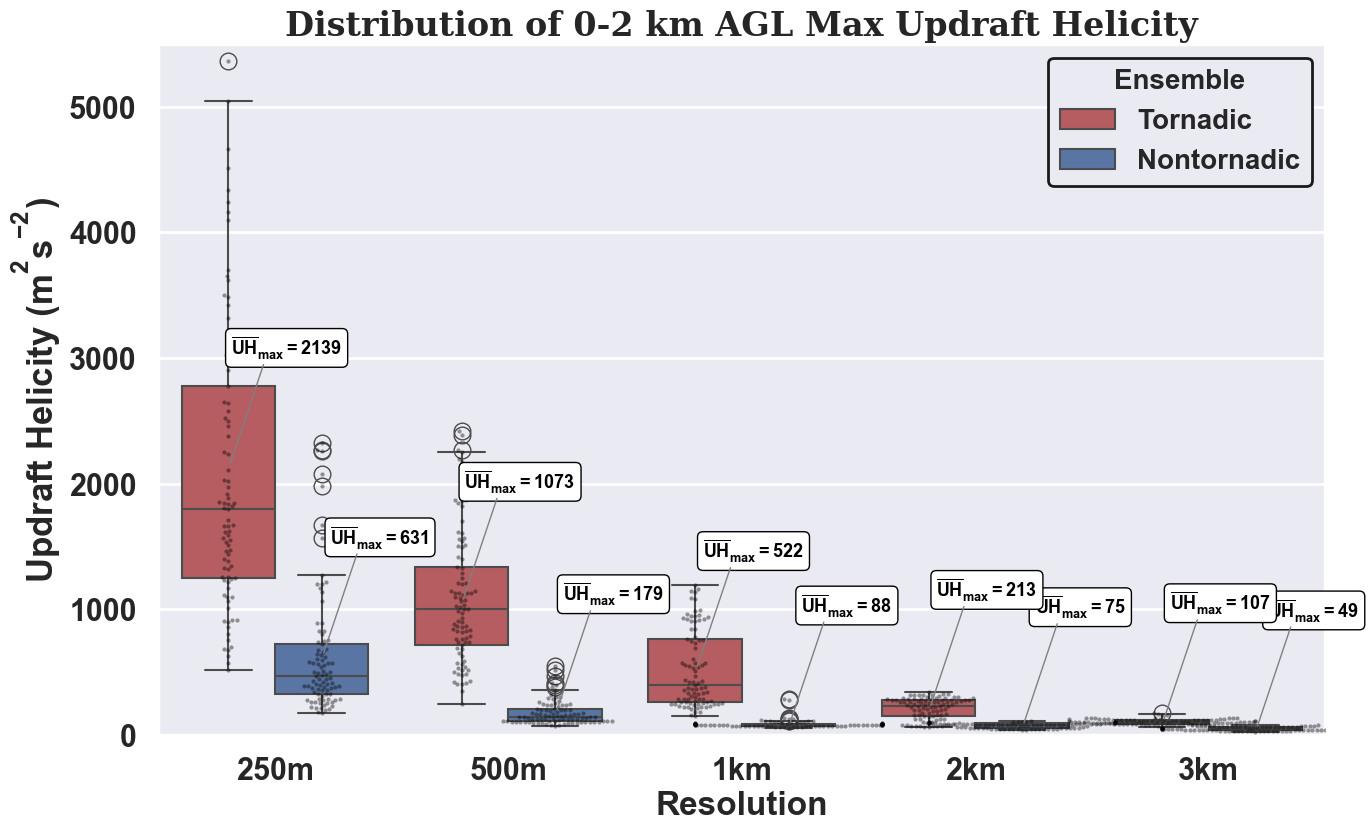

In [44]:
low_uh_box, ax_box = plt.subplots(figsize=(14, 8.5))

sns.set_theme(style='darkgrid', font='sans-serif', font_scale=2)
sns.set_context('poster')
my_pal = {'Tornadic':'r', 'Nontornadic':'b'}
ax_box = sns.boxplot(data=df, x='Resolution', y='Updraft Helicity', hue='Classification', palette=my_pal, linewidth=1.5)
swarm = sns.swarmplot(data=df, x='Resolution', y='Updraft Helicity', hue='Classification', dodge=True, alpha=0.4, size=3)

for collection in swarm.collections:
    collection.set_facecolor('black')
    collection.set_edgecolor('black')

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Ensemble', fontsize=20, title_fontsize=20, framealpha=1, edgecolor='k')

# === STEP: Annotate Mean Values ===
# Prepare group means
means = df.groupby(['Resolution', 'Classification'])['Updraft Helicity'].mean().reset_index()

# Mapping of label to dodge offset (matches Seaborn's logic)
label_offset = {
    'Tornadic': 0.05,
    'Nontornadic': 0.45
}

# Create mapping of resolution to x-position
res_order = df['Resolution'].unique()
x_pos_map = {res: i for i, res in enumerate(res_order)}

y_min, y_max = ax_box.get_ylim()
y_range = y_max - y_min

# Adjust this multiplier as needed (5% of the range)
offset = 0.1225 * y_range


# Add mean value labels
for _, row in means.iterrows():
    x_base = x_pos_map[row['Resolution']]
    x = x_base + label_offset[row['Classification']]
    y = row['Updraft Helicity']
    label_y = y + offset
    label_x = x + 0.15
    horizontal_shift = -0.245  # or +0.05, depending on direction you want

    # Shift both label and mean x positions
    shifted_label_x = label_x + horizontal_shift
    shifted_box_x = x + horizontal_shift
    ax_box.text(
        x, y + offset,  # Adjust vertical position as needed
        '$\mathregular{\overline{UH}_{max}=}$'f'{y:.0f}',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='black',
        bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor='white',
        edgecolor='black',
        linewidth=1)
    )
    ax_box.annotate(
        '',
        xy=(shifted_box_x, y),
        xytext=(shifted_label_x, label_y),
        arrowprops=dict(
            arrowstyle='-',
            color='grey',
            lw=1),
        zorder=3    
        )


plt.ylim(0, 5500)
plt.tight_layout()
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
ax_box.set_ylabel('Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', fontsize=25)

plt.title('Distribution of 0-2 km AGL Max Updraft Helicity', fontsize=20, font='serif')
#low_uh_box.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/UH_max_0_2km_boxplot_with_3km.png', dpi=300, bbox_inches='tight')
plt.show()

## Resolution Degradation Experiments (250m Baseline)

In [86]:
import glob
import os
import numpy as np
import pandas as pd
import xarray as xarray


# ============================================================
# USER SETTINGS
# ============================================================

BASE_DIR = "/Volumes/Expansion/V2_ensembles_data"
TIMES = [5, 6, 7, 8, 9, 10]

NATIVE_RESOLUTIONS = [250, 500, 1000, 2000]
TARGET_COARSENED_RESOLUTIONS = [500, 1000, 2000]

LOWER = 0.0
UPPER = 2000.0

OUTPUT_RAW_CSV = "uh_native_vs_from250_raw.csv"
OUTPUT_TRIMMED_CSV = "uh_native_vs_from250_trimmed.csv"


# ============================================================
# UH FUNCTION
# ============================================================

def calc_uh(w, wz, z, dz, lower, upper):

    # Calculates vertical grid spacing-weighted vertical vorticity
    # between lower and upper

    # Input:
    # w     - 3D numpy array of vertical velocity
    # wz    - 3D numpy array of relative vertical vorticity
    # z     - 3D numpy array of height AGL (m)
    # dz    - 3D numpy array of vertical grid spacing depth (m)
    # lower - lower bound of layer (m)
    # upper - upper bound of layer (m)

    # Returns:
    # uh    - 2D numpy array of layer-integrated updraft helicity

    hel = w * wz

    hel = np.where(z > upper, 0.0, hel)
    hel = np.where(z < lower, 0.0, hel)

    uh = np.trapz(hel, dx=dz[:-1, :, :], axis=0)

    return uh


# ============================================================
# HELPERS
# ============================================================

def get_file_list(base_dir, resolution, storm_type):
    pattern = os.path.join(
        base_dir,
        f"{resolution}m_{storm_type}_ensemble_data",
        "*[!_stats].nc"
    )
    return sorted(glob.glob(pattern))


def build_z_dz_3d(ds):
    """
    Build 3D z and dz arrays exactly as in the original workflow.
    """
    x = ds["xh"].values
    y = ds["yh"].values
    z = ds["zh"].values * 1000.0
    dz = np.pad(np.diff(ds["zh"].values) * 1000.0, (1, 0), mode="constant")

    z_3d, _, _ = np.meshgrid(z, y, x, indexing="ij")
    dz_3d, _, _ = np.meshgrid(dz, y, x, indexing="ij")

    return z_3d, dz_3d


def coarsen_3d_xy_mean(arr, factor):
    """
    Block-average a 3D array (nz, ny, nx) horizontally.
    """
    arr = np.asarray(arr)
    nz, ny, nx = arr.shape

    ny_trim = (ny // factor) * factor
    nx_trim = (nx // factor) * factor

    arr_trim = arr[:, :ny_trim, :nx_trim]

    arr_coarse = arr_trim.reshape(
        nz,
        ny_trim // factor, factor,
        nx_trim // factor, factor
    ).mean(axis=(2, 4))

    return arr_coarse


def target_to_factor(native_resolution, target_resolution):
    if target_resolution % native_resolution != 0:
        raise ValueError(
            f"{target_resolution} is not an integer multiple of {native_resolution}"
        )
    return target_resolution // native_resolution


def trim_group_max(group):
    """
    Match old behavior exactly:
    remove all rows whose uh_max equals the maximum uh_max in that group.
    """
    max_val = group["uh_max"].max()
    return group[group["uh_max"] != max_val]


# ============================================================
# PROCESS NATIVE FILES
# ============================================================

def process_native_files(base_dir, resolutions, storm_types, times, lower, upper):
    records = []

    for storm_type in storm_types:
        for resolution in resolutions:
            files = get_file_list(base_dir, resolution, storm_type)

            print(f"\nProcessing native {storm_type} {resolution} m ({len(files)} files)")

            for file_path in files:
                ds = None
                try:
                    ds = xarray.open_dataset(file_path)
                    z_3d, dz_3d = build_z_dz_3d(ds)

                    for t in times:
                        w = ds["winterp"].isel(time=t).values
                        wz = ds["zvort"].isel(time=t).values

                        uh = calc_uh(w, wz, z_3d, dz_3d, lower, upper)
                        uh_max = float(np.max(uh))

                        records.append({
                            "storm_type": storm_type,
                            "source": "native",
                            "native_resolution_m": resolution,
                            "target_resolution_m": resolution,
                            "time_index": t,
                            "file": os.path.basename(file_path),
                            "uh_max": uh_max
                        })

                except Exception as e:
                    print(f"Skipping file: {file_path}")
                    print(f"Error: {e}")

                finally:
                    if ds is not None:
                        ds.close()

    return records


# ============================================================
# PROCESS 250-M FILES AND COARSEN
# ============================================================

def process_from250_files(base_dir, storm_types, times, target_resolutions, lower, upper):
    records = []
    native_resolution = 250

    for storm_type in storm_types:
        files_250 = get_file_list(base_dir, native_resolution, storm_type)

        print(f"\nProcessing from-250 {storm_type} ({len(files_250)} files)")

        for file_path in files_250:
            ds = None
            try:
                ds = xarray.open_dataset(file_path)
                z_3d_native, dz_3d_native = build_z_dz_3d(ds)

                for t in times:
                    w_native = ds["winterp"].isel(time=t).values
                    wz_native = ds["zvort"].isel(time=t).values

                    # Native 250 m value from the 250 m dataset
                    uh_native = calc_uh(
                        w_native,
                        wz_native,
                        z_3d_native,
                        dz_3d_native,
                        lower,
                        upper
                    )
                    uh_native_max = float(np.max(uh_native))

                    records.append({
                        "storm_type": storm_type,
                        "source": "from_250_native",
                        "native_resolution_m": 250,
                        "target_resolution_m": 250,
                        "time_index": t,
                        "file": os.path.basename(file_path),
                        "uh_max": uh_native_max
                    })

                    # Coarsened-from-250 values
                    for target_res in target_resolutions:
                        factor = target_to_factor(native_resolution, target_res)

                        w_coarse = coarsen_3d_xy_mean(w_native, factor)
                        wz_coarse = coarsen_3d_xy_mean(wz_native, factor)
                        z_3d_coarse = coarsen_3d_xy_mean(z_3d_native, factor)
                        dz_3d_coarse = coarsen_3d_xy_mean(dz_3d_native, factor)

                        uh_coarse = calc_uh(
                            w_coarse,
                            wz_coarse,
                            z_3d_coarse,
                            dz_3d_coarse,
                            lower,
                            upper
                        )
                        uh_coarse_max = float(np.max(uh_coarse))

                        records.append({
                            "storm_type": storm_type,
                            "source": "from_250_coarsened",
                            "native_resolution_m": 250,
                            "target_resolution_m": target_res,
                            "time_index": t,
                            "file": os.path.basename(file_path),
                            "uh_max": uh_coarse_max
                        })

            except Exception as e:
                print(f"Skipping file: {file_path}")
                print(f"Error: {e}")

            finally:
                if ds is not None:
                    ds.close()

    return records


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    storm_types = ["tor", "nt"]

    # --------------------------------------------------------
    # 1. Compute raw UH maxima
    # --------------------------------------------------------
    native_records = process_native_files(
        base_dir=BASE_DIR,
        resolutions=NATIVE_RESOLUTIONS,
        storm_types=storm_types,
        times=TIMES,
        lower=LOWER,
        upper=UPPER
    )

    from250_records = process_from250_files(
        base_dir=BASE_DIR,
        storm_types=storm_types,
        times=TIMES,
        target_resolutions=TARGET_COARSENED_RESOLUTIONS,
        lower=LOWER,
        upper=UPPER
    )

    all_records = native_records + from250_records
    df_raw = pd.DataFrame(all_records)

    df_raw.to_csv(OUTPUT_RAW_CSV, index=False)
    print(f"\nSaved raw results to: {OUTPUT_RAW_CSV}")

    # --------------------------------------------------------
    # 2. Trim max UH within each comparison group
    # --------------------------------------------------------
    #
    # This matches the old logic:
    # arr = arr[arr != np.max(arr)]
    #
    # Groups are separated by:
    #   storm_type
    #   source
    #   target_resolution_m
    #
    # So each ensemble/comparison bucket trims its own extreme max.
    #
    df_trimmed = (
        df_raw
        .groupby(["storm_type", "source", "target_resolution_m"], group_keys=False)
        .apply(trim_group_max)
        .reset_index(drop=True)
    )

    df_trimmed.to_csv(OUTPUT_TRIMMED_CSV, index=False)
    print(f"Saved trimmed results to: {OUTPUT_TRIMMED_CSV}")

    # --------------------------------------------------------
    # 3. Print summary means from trimmed dataset
    # --------------------------------------------------------
    summary = (
        df_trimmed
        .groupby(["storm_type", "source", "target_resolution_m"])["uh_max"]
        .mean()
        .reset_index()
        .sort_values(["source", "storm_type", "target_resolution_m"])
    )

    print("\nTrimmed group means:")
    print(summary.to_string(index=False))



Processing native tor 250 m (15 files)

Processing native tor 500 m (15 files)

Processing native tor 1000 m (15 files)

Processing native tor 2000 m (15 files)

Processing native nt 250 m (15 files)

Processing native nt 500 m (15 files)

Processing native nt 1000 m (15 files)

Processing native nt 2000 m (15 files)

Processing from-250 tor (15 files)

Processing from-250 nt (15 files)

Saved raw results to: uh_native_vs_from250_raw.csv
Saved trimmed results to: uh_native_vs_from250_trimmed.csv

Trimmed group means:
storm_type             source  target_resolution_m      uh_max
        nt from_250_coarsened                  500  469.383029
        nt from_250_coarsened                 1000  281.431871
        nt from_250_coarsened                 2000  127.374323
       tor from_250_coarsened                  500 1684.445066
       tor from_250_coarsened                 1000  998.623796
       tor from_250_coarsened                 2000  445.537175
        nt    from_250_native      

/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_177/3559416978.py:303: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(trim_group_max)


<>:165: SyntaxWarning: invalid escape sequence '\m'
<>:202: SyntaxWarning: invalid escape sequence '\m'
<>:165: SyntaxWarning: invalid escape sequence '\m'
<>:202: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_177/596166935.py:165: SyntaxWarning: invalid escape sequence '\m'
  '$\mathregular{\overline{UH}_{max}=}$' + f'{y:.0f}',
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_177/596166935.py:202: SyntaxWarning: invalid escape sequence '\m'
  ax_box.set_ylabel('Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', fontsize=25)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 7.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


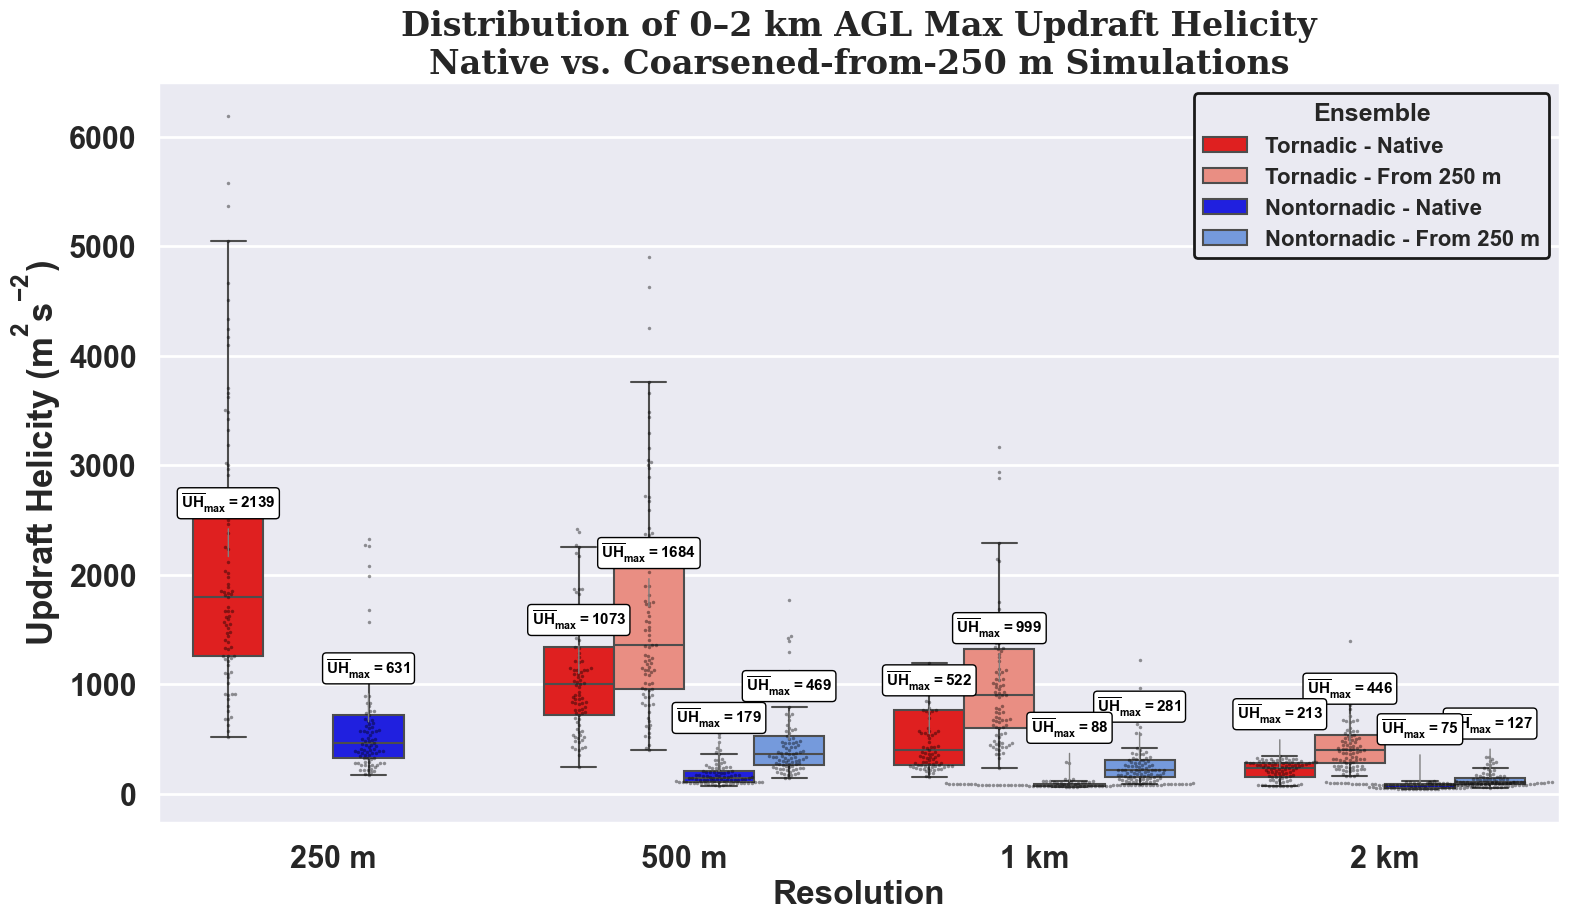

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# READ TRIMMED DATA
# ============================================================

df = pd.read_csv("uh_native_vs_from250_trimmed.csv")


# ============================================================
# PREPARE DATA
# ============================================================

# Pretty labels
df["Classification"] = df["storm_type"].replace({
    "tor": "Tornadic",
    "nt": "Nontornadic"
})

df["Source Label"] = df["source"].replace({
    "native": "Native",
    "from_250_native": "From 250 m",
    "from_250_coarsened": "From 250 m"
})

df["Resolution"] = df["target_resolution_m"].replace({
    250: "250 m",
    500: "500 m",
    1000: "1 km",
    2000: "2 km"
})

df["Updraft Helicity"] = df["uh_max"]

# Drop redundant 250-m "From 250 m" values so 250 m only shows native runs
df = df[
    ~(
        (df["Resolution"] == "250 m") &
        (df["Source Label"] == "From 250 m")
    )
].copy()

# Combined legend label
df["Ensemble"] = df["Classification"] + " - " + df["Source Label"]

resolution_order = ["250 m", "500 m", "1 km", "2 km"]
hue_order = [
    "Tornadic - Native",
    "Tornadic - From 250 m",
    "Nontornadic - Native",
    "Nontornadic - From 250 m"
]

# Keep only the combinations we want plotted
valid_ensembles = set(hue_order)
df = df[df["Ensemble"].isin(valid_ensembles)].copy()


# ============================================================
# PLOT
# ============================================================

low_uh_box, ax_box = plt.subplots(figsize=(16, 9))

sns.set_theme(style='darkgrid', font='sans-serif', font_scale=2)
sns.set_context('poster')

my_pal = {
    "Tornadic - Native": "red",
    "Tornadic - From 250 m": "salmon",
    "Nontornadic - Native": "blue",
    "Nontornadic - From 250 m": "cornflowerblue"
}

ax_box = sns.boxplot(
    data=df,
    x='Resolution',
    y='Updraft Helicity',
    hue='Ensemble',
    order=resolution_order,
    hue_order=hue_order,
    palette=my_pal,
    linewidth=1.5,
    fliersize=0
)

swarm = sns.swarmplot(
    data=df,
    x='Resolution',
    y='Updraft Helicity',
    hue='Ensemble',
    order=resolution_order,
    hue_order=hue_order,
    dodge=True,
    alpha=0.4,
    size=2.5
)

for collection in swarm.collections:
    collection.set_facecolor('black')
    collection.set_edgecolor('black')


# ============================================================
# CLEAN LEGEND
# ============================================================

handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(
    handles[0:4],
    labels[0:4],
    title='Ensemble',
    fontsize=16,
    title_fontsize=18,
    framealpha=1,
    edgecolor='k',
    loc='upper right'
)


# ============================================================
# ANNOTATE MEAN VALUES
# ============================================================

means = df.groupby(['Resolution', 'Ensemble'])['Updraft Helicity'].mean().reset_index()

# Approximate dodge offsets for 4-hue seaborn boxplot
label_offset = {
    "Tornadic - Native": -0.30,
    "Tornadic - From 250 m": -0.10,
    "Nontornadic - Native": 0.10,
    "Nontornadic - From 250 m": 0.30
}

x_pos_map = {res: i for i, res in enumerate(resolution_order)}

y_min, y_max = ax_box.get_ylim()
y_range = y_max - y_min
offset = 0.06 * y_range

for _, row in means.iterrows():
    resolution = row['Resolution']
    ensemble = row['Ensemble']
    y = row['Updraft Helicity']

    # skip nonexistent 250-m "From 250 m" categories
    if resolution == "250 m" and "From 250 m" in ensemble:
        continue

    x_base = x_pos_map[resolution]
    x = x_base + label_offset[ensemble]

    label_y = y + offset
    label_x = x
    line_y_end = label_y - 0.015 * y_range

    ax_box.text(
        label_x,
        label_y,
        '$\mathregular{\overline{UH}_{max}=}$' + f'{y:.0f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black',
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor='white',
            edgecolor='black',
            linewidth=1
        ),
        zorder=5
    )

    ax_box.annotate(
        '',
        xy=(x, y),
        xytext=(label_x, line_y_end),
        arrowprops=dict(
            arrowstyle='-',
            color='grey',
            lw=1
        ),
        zorder=4
    )


# ============================================================
# FINAL FORMATTING
# ============================================================

plt.tight_layout()
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

ax_box.set_ylabel('Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', fontsize=25)
ax_box.set_xlabel('Resolution', fontsize=24)

plt.title(
    'Distribution of 0–2 km AGL Max Updraft Helicity\nNative vs. Coarsened-from-250 m Simulations',
    fontsize=20,
    font='serif'
)

# Optional fixed y-axis
# plt.ylim(0, 5500)

# Optional save
# low_uh_box.savefig('UH_native_vs_from250_trimmed_boxplot.png', dpi=300, bbox_inches='tight')

plt.show()


In [12]:
import glob
import os
import numpy as np
import pandas as pd
import xarray as xarray


# ============================================================
# USER SETTINGS
# ============================================================

BASE_DIR = "/Volumes/Expansion/V2_ensembles_data"
TIMES = [5, 6, 7, 8, 9, 10]

NATIVE_RESOLUTIONS = [250, 500, 1000, 2000]
TARGET_INTERP_RESOLUTIONS = [500, 1000, 2000]

LOWER = 0.0
UPPER = 2000.0

OUTPUT_RAW_CSV = "uh_native_vs_from250_interp_raw.csv"
OUTPUT_TRIMMED_CSV = "uh_native_vs_from250_interp_trimmed.csv"


# ============================================================
# UH FUNCTION
# ============================================================

def calc_uh(w, wz, z, dz, lower, upper):

    hel = w * wz

    hel = np.where(z > upper, 0.0, hel)
    hel = np.where(z < lower, 0.0, hel)

    uh = np.trapz(hel, dx=dz[:-1, :, :], axis=0)

    return uh


# ============================================================
# HELPERS
# ============================================================

def get_file_list(base_dir, resolution, storm_type):
    pattern = os.path.join(
        base_dir,
        f"{resolution}m_{storm_type}_ensemble_data",
        "*[!_stats].nc"
    )
    return sorted(glob.glob(pattern))


def build_z_dz_3d_from_coords(z_1d_m, dz_1d_m, y_1d, x_1d):
    z_3d, _, _ = np.meshgrid(z_1d_m, y_1d, x_1d, indexing="ij")
    dz_3d, _, _ = np.meshgrid(dz_1d_m, y_1d, x_1d, indexing="ij")
    return z_3d, dz_3d


def build_native_vertical_coords(ds):
    x = ds["xh"].values
    y = ds["yh"].values
    z = ds["zh"].values * 1000.0
    dz = np.pad(np.diff(ds["zh"].values) * 1000.0, (1, 0), mode="constant")
    return x, y, z, dz


def target_to_factor(native_resolution, target_resolution):
    if target_resolution % native_resolution != 0:
        raise ValueError(
            f"{target_resolution} is not an integer multiple of {native_resolution}"
        )
    return target_resolution // native_resolution


def get_target_coords(x, y, factor):
    """
    Define the target coarse grid by taking every nth native coordinate.
    """
    x_new = x[::factor]
    y_new = y[::factor]
    return x_new, y_new


def interp_3d_xy_linear(data_array, x_new, y_new):
    """
    Linearly interpolate a 3D xarray DataArray with dims (z, y, x)
    or similar onto new horizontal coordinates.
    """
    dims = data_array.dims

    # Assumes dimensions are ordered (vertical, yh, xh)
    vert_dim = dims[0]
    y_dim = dims[1]
    x_dim = dims[2]

    da_interp = data_array.interp(
        {
            y_dim: y_new,
            x_dim: x_new
        },
        method="linear"
    )

    return da_interp.values


def trim_group_max(group):
    """
    Match your old behavior exactly:
    remove all rows whose uh_max equals the maximum uh_max in that group.
    """
    max_val = group["uh_max"].max()
    return group[group["uh_max"] != max_val]


# ============================================================
# PROCESS NATIVE FILES
# ============================================================

def process_native_files(base_dir, resolutions, storm_types, times, lower, upper):
    records = []

    for storm_type in storm_types:
        for resolution in resolutions:
            files = get_file_list(base_dir, resolution, storm_type)

            print(f"\nProcessing native {storm_type} {resolution} m ({len(files)} files)")

            for file_path in files:
                ds = None
                try:
                    ds = xarray.open_dataset(file_path)

                    x, y, z, dz = build_native_vertical_coords(ds)
                    z_3d, dz_3d = build_z_dz_3d_from_coords(z, dz, y, x)

                    for t in times:
                        w = ds["winterp"].isel(time=t).values
                        wz = ds["zvort"].isel(time=t).values

                        uh = calc_uh(w, wz, z_3d, dz_3d, lower, upper)
                        uh_max = float(np.max(uh))

                        records.append({
                            "storm_type": storm_type,
                            "source": "native",
                            "native_resolution_m": resolution,
                            "target_resolution_m": resolution,
                            "time_index": t,
                            "file": os.path.basename(file_path),
                            "uh_max": uh_max
                        })

                except Exception as e:
                    print(f"Skipping file: {file_path}")
                    print(f"Error: {e}")

                finally:
                    if ds is not None:
                        ds.close()

    return records


# ============================================================
# PROCESS 250-M FILES AND INTERPOLATE
# ============================================================

def process_from250_interp_files(base_dir, storm_types, times, target_resolutions, lower, upper):
    records = []
    native_resolution = 250

    for storm_type in storm_types:
        files_250 = get_file_list(base_dir, native_resolution, storm_type)

        print(f"\nProcessing from-250 interpolation {storm_type} ({len(files_250)} files)")

        for file_path in files_250:
            ds = None
            try:
                ds = xarray.open_dataset(file_path)

                x_native, y_native, z, dz = build_native_vertical_coords(ds)
                z_3d_native, dz_3d_native = build_z_dz_3d_from_coords(z, dz, y_native, x_native)

                for t in times:
                    w_native_da = ds["winterp"].isel(time=t)
                    wz_native_da = ds["zvort"].isel(time=t)

                    w_native = w_native_da.values
                    wz_native = wz_native_da.values

                    # Native 250 m value
                    uh_native = calc_uh(
                        w_native,
                        wz_native,
                        z_3d_native,
                        dz_3d_native,
                        lower,
                        upper
                    )
                    uh_native_max = float(np.max(uh_native))

                    records.append({
                        "storm_type": storm_type,
                        "source": "from_250_native",
                        "native_resolution_m": 250,
                        "target_resolution_m": 250,
                        "time_index": t,
                        "file": os.path.basename(file_path),
                        "uh_max": uh_native_max
                    })

                    # Interpolated-from-250 values
                    for target_res in target_resolutions:
                        factor = target_to_factor(native_resolution, target_res)
                        x_new, y_new = get_target_coords(x_native, y_native, factor)

                        w_interp = interp_3d_xy_linear(w_native_da, x_new, y_new)
                        wz_interp = interp_3d_xy_linear(wz_native_da, x_new, y_new)

                        z_3d_interp, dz_3d_interp = build_z_dz_3d_from_coords(
                            z, dz, y_new, x_new
                        )

                        uh_interp = calc_uh(
                            w_interp,
                            wz_interp,
                            z_3d_interp,
                            dz_3d_interp,
                            lower,
                            upper
                        )
                        uh_interp_max = float(np.max(uh_interp))

                        records.append({
                            "storm_type": storm_type,
                            "source": "from_250_interpolated",
                            "native_resolution_m": 250,
                            "target_resolution_m": target_res,
                            "time_index": t,
                            "file": os.path.basename(file_path),
                            "uh_max": uh_interp_max
                        })

            except Exception as e:
                print(f"Skipping file: {file_path}")
                print(f"Error: {e}")

            finally:
                if ds is not None:
                    ds.close()

    return records


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    storm_types = ["tor", "nt"]

    # --------------------------------------------------------
    # 1. Compute raw UH maxima
    # --------------------------------------------------------
    native_records = process_native_files(
        base_dir=BASE_DIR,
        resolutions=NATIVE_RESOLUTIONS,
        storm_types=storm_types,
        times=TIMES,
        lower=LOWER,
        upper=UPPER
    )

    from250_interp_records = process_from250_interp_files(
        base_dir=BASE_DIR,
        storm_types=storm_types,
        times=TIMES,
        target_resolutions=TARGET_INTERP_RESOLUTIONS,
        lower=LOWER,
        upper=UPPER
    )

    all_records = native_records + from250_interp_records
    df_raw = pd.DataFrame(all_records)

    df_raw.to_csv(OUTPUT_RAW_CSV, index=False)
    print(f"\nSaved raw results to: {OUTPUT_RAW_CSV}")

    # --------------------------------------------------------
    # 2. Trim max UH within each comparison group
    # --------------------------------------------------------
    df_trimmed = (
        df_raw
        .groupby(["storm_type", "source", "target_resolution_m"], group_keys=False)
        .apply(trim_group_max)
        .reset_index(drop=True)
    )

    df_trimmed.to_csv(OUTPUT_TRIMMED_CSV, index=False)
    print(f"Saved trimmed results to: {OUTPUT_TRIMMED_CSV}")

    # --------------------------------------------------------
    # 3. Print summary means
    # --------------------------------------------------------
    summary = (
        df_trimmed
        .groupby(["storm_type", "source", "target_resolution_m"])["uh_max"]
        .mean()
        .reset_index()
        .sort_values(["source", "storm_type", "target_resolution_m"])
    )

    print("\nTrimmed group means:")
    print(summary.to_string(index=False))


Processing native tor 250 m (15 files)

Processing native tor 500 m (15 files)

Processing native tor 1000 m (15 files)

Processing native tor 2000 m (15 files)

Processing native nt 250 m (15 files)

Processing native nt 500 m (15 files)

Processing native nt 1000 m (15 files)

Processing native nt 2000 m (15 files)

Processing from-250 interpolation tor (15 files)

Processing from-250 interpolation nt (15 files)

Saved raw results to: uh_native_vs_from250_interp_raw.csv
Saved trimmed results to: uh_native_vs_from250_interp_trimmed.csv

Trimmed group means:
storm_type                source  target_resolution_m      uh_max
        nt from_250_interpolated                  500  555.728678
        nt from_250_interpolated                 1000  409.596071
        nt from_250_interpolated                 2000  249.549595
       tor from_250_interpolated                  500 1832.879640
       tor from_250_interpolated                 1000 1330.217827
       tor from_250_interpolated      

/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_6397/2963526097.py:298: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(trim_group_max)


<>:157: SyntaxWarning: invalid escape sequence '\m'
<>:194: SyntaxWarning: invalid escape sequence '\m'
<>:157: SyntaxWarning: invalid escape sequence '\m'
<>:194: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_6397/4141833022.py:157: SyntaxWarning: invalid escape sequence '\m'
  '$\mathregular{\overline{UH}_{max}=}$' + f'{y:.0f}',
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_6397/4141833022.py:194: SyntaxWarning: invalid escape sequence '\m'
  ax_box.set_ylabel('Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', fontsize=25)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 7.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


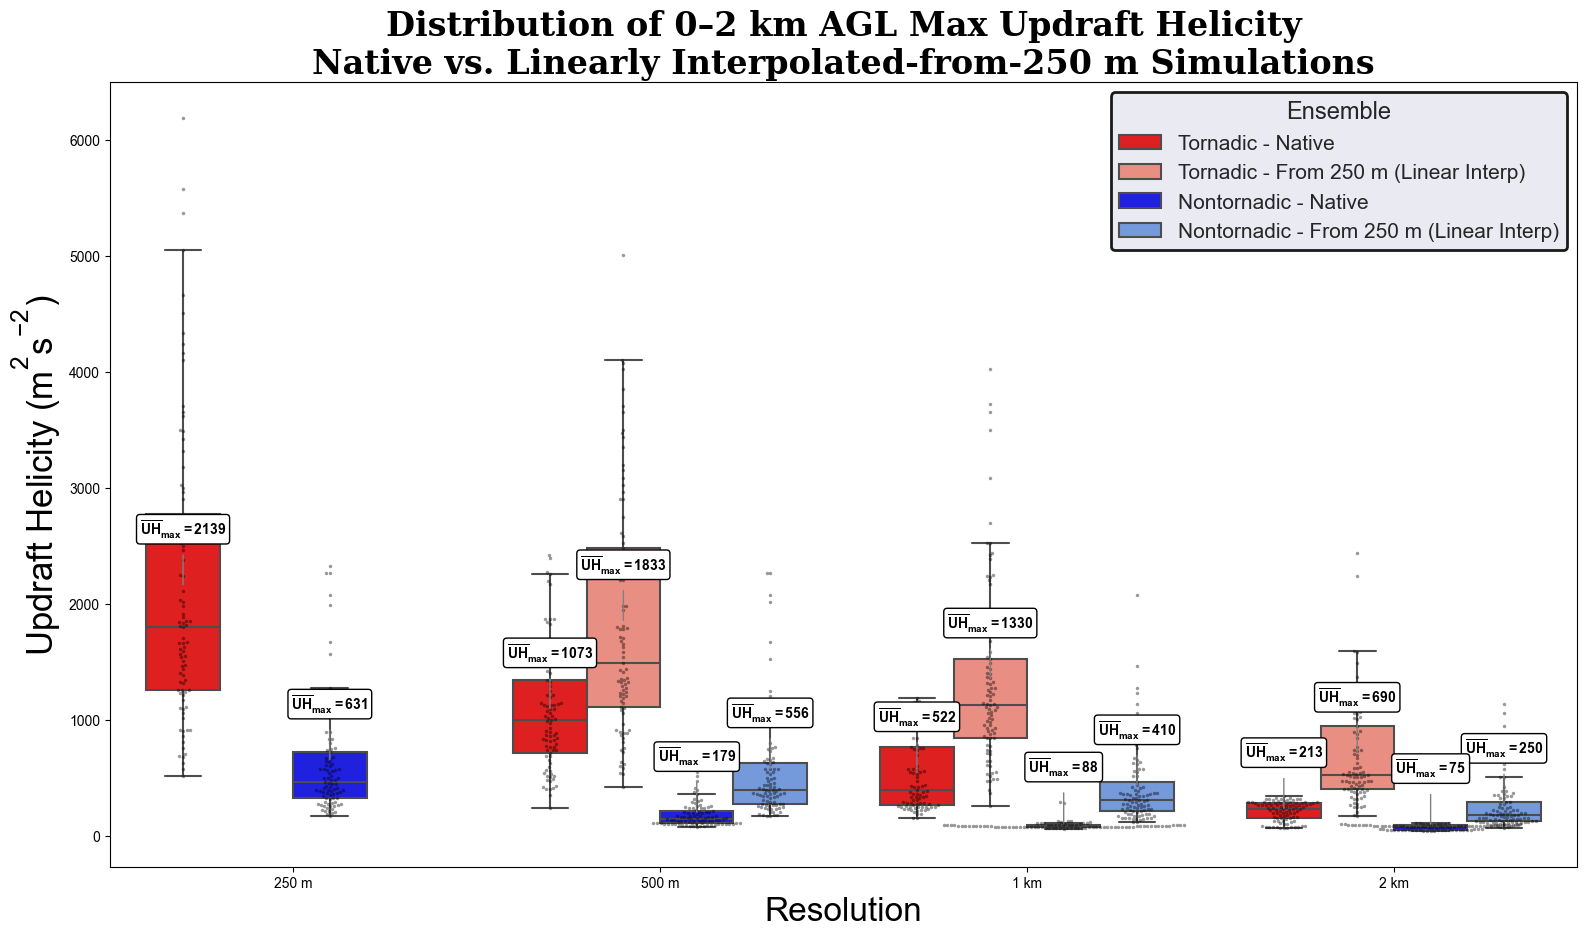

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# READ TRIMMED DATA
# ============================================================

df = pd.read_csv("uh_native_vs_from250_interp_trimmed.csv")


# ============================================================
# PREPARE DATA
# ============================================================

df["Classification"] = df["storm_type"].replace({
    "tor": "Tornadic",
    "nt": "Nontornadic"
})

df["Source Label"] = df["source"].replace({
    "native": "Native",
    "from_250_native": "From 250 m",
    "from_250_interpolated": "From 250 m (Linear Interp)"
})

df["Resolution"] = df["target_resolution_m"].replace({
    250: "250 m",
    500: "500 m",
    1000: "1 km",
    2000: "2 km"
})

df["Updraft Helicity"] = df["uh_max"]

# Drop redundant 250-m "From 250 m" values
df = df[
    ~(
        (df["Resolution"] == "250 m") &
        (df["Source Label"] == "From 250 m")
    )
].copy()

df["Ensemble"] = df["Classification"] + " - " + df["Source Label"]

resolution_order = ["250 m", "500 m", "1 km", "2 km"]
hue_order = [
    "Tornadic - Native",
    "Tornadic - From 250 m (Linear Interp)",
    "Nontornadic - Native",
    "Nontornadic - From 250 m (Linear Interp)"
]

df = df[df["Ensemble"].isin(hue_order)].copy()


# ============================================================
# PLOT
# ============================================================

low_uh_box, ax_box = plt.subplots(figsize=(16, 9))

sns.set_theme(style='darkgrid', font='sans-serif', font_scale=2)
sns.set_context('poster')

my_pal = {
    "Tornadic - Native": "red",
    "Tornadic - From 250 m (Linear Interp)": "salmon",
    "Nontornadic - Native": "blue",
    "Nontornadic - From 250 m (Linear Interp)": "cornflowerblue"
}

ax_box = sns.boxplot(
    data=df,
    x='Resolution',
    y='Updraft Helicity',
    hue='Ensemble',
    order=resolution_order,
    hue_order=hue_order,
    palette=my_pal,
    linewidth=1.5,
    fliersize=0
)

swarm = sns.swarmplot(
    data=df,
    x='Resolution',
    y='Updraft Helicity',
    hue='Ensemble',
    order=resolution_order,
    hue_order=hue_order,
    dodge=True,
    alpha=0.4,
    size=2.5
)

for collection in swarm.collections:
    collection.set_facecolor('black')
    collection.set_edgecolor('black')


# ============================================================
# CLEAN LEGEND
# ============================================================

handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(
    handles[0:4],
    labels[0:4],
    title='Ensemble',
    fontsize=15,
    title_fontsize=17,
    framealpha=1,
    edgecolor='k',
    loc='upper right'
)


# ============================================================
# ANNOTATE MEAN VALUES
# ============================================================

means = df.groupby(['Resolution', 'Ensemble'])['Updraft Helicity'].mean().reset_index()

label_offset = {
    "Tornadic - Native": -0.30,
    "Tornadic - From 250 m (Linear Interp)": -0.10,
    "Nontornadic - Native": 0.10,
    "Nontornadic - From 250 m (Linear Interp)": 0.30
}

x_pos_map = {res: i for i, res in enumerate(resolution_order)}

y_min, y_max = ax_box.get_ylim()
y_range = y_max - y_min
offset = 0.06 * y_range

for _, row in means.iterrows():
    resolution = row['Resolution']
    ensemble = row['Ensemble']
    y = row['Updraft Helicity']

    if resolution == "250 m" and "From 250 m" in ensemble:
        continue

    x_base = x_pos_map[resolution]
    x = x_base + label_offset[ensemble]

    label_y = y + offset
    line_y_end = label_y - 0.015 * y_range

    ax_box.text(
        x,
        label_y,
        '$\mathregular{\overline{UH}_{max}=}$' + f'{y:.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black',
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor='white',
            edgecolor='black',
            linewidth=1
        ),
        zorder=5
    )

    ax_box.annotate(
        '',
        xy=(x, y),
        xytext=(x, line_y_end),
        arrowprops=dict(
            arrowstyle='-',
            color='grey',
            lw=1
        ),
        zorder=4
    )


# ============================================================
# FINAL FORMATTING
# ============================================================

plt.tight_layout()
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

ax_box.set_ylabel('Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', fontsize=25)
ax_box.set_xlabel('Resolution', fontsize=24)

plt.title(
    'Distribution of 0–2 km AGL Max Updraft Helicity\nNative vs. Linearly Interpolated-from-250 m Simulations',
    fontsize=20,
    font='serif'
)

# plt.ylim(0, 5500)
# low_uh_box.savefig('UH_native_vs_from250_linear_interp_trimmed_boxplot.png', dpi=300, bbox_inches='tight')

plt.show()

In [52]:
df_3km = [make_df(uh_low_tor_max_3km, '3km', 'Tornadic'),
           make_df(uh_low_nt_max_3km, '3km', 'Nontornadic')]

df3km = pd.concat(df_3km, ignore_index=True)

print(df3km.tail())

     Updraft Helicity Resolution Classification
173         36.832523        3km    Nontornadic
174         39.384796        3km    Nontornadic
175         48.930908        3km    Nontornadic
176         48.549271        3km    Nontornadic
177         45.483715        3km    Nontornadic


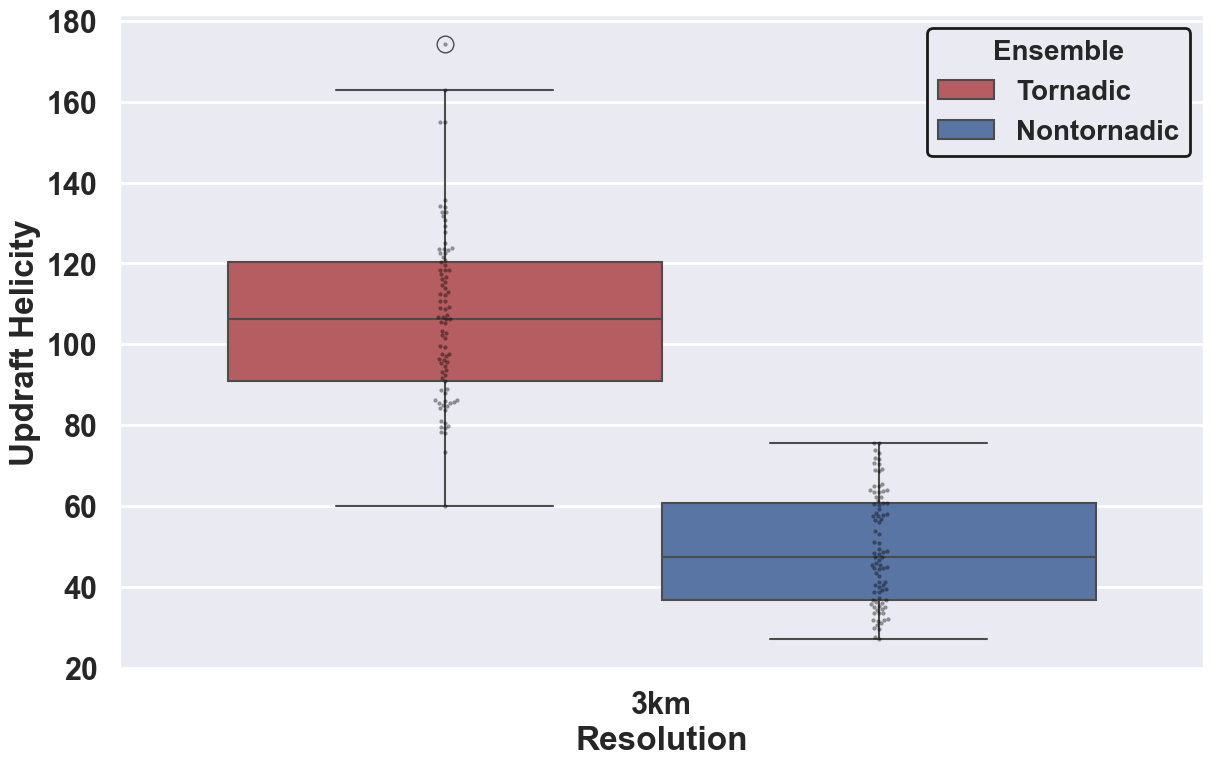

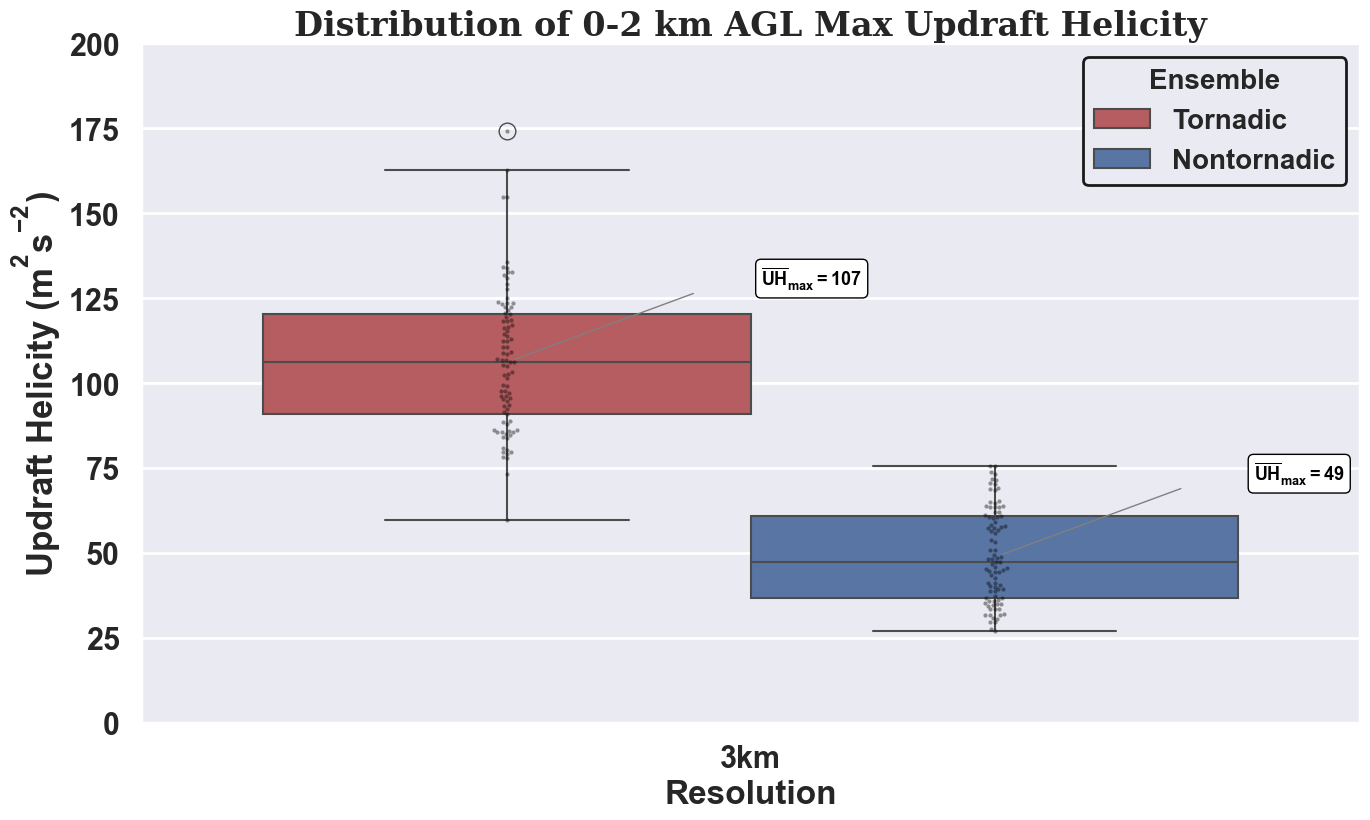

In [56]:
low_uh_box_3km, ax_box_3km = plt.subplots(figsize=(14, 8.5))

sns.set_theme(style='darkgrid', font='sans-serif', font_scale=2)
sns.set_context('poster')
my_pal = {'Tornadic':'r', 'Nontornadic':'b'}
ax_box_3km = sns.boxplot(data=df3km, x='Resolution', y='Updraft Helicity', hue='Classification', palette=my_pal, linewidth=1.5)
swarm = sns.swarmplot(data=df3km, x='Resolution', y='Updraft Helicity', hue='Classification', dodge=True, alpha=0.4, size=3)

for collection in swarm.collections:
    collection.set_facecolor('black')
    collection.set_edgecolor('black')

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Ensemble', fontsize=20, title_fontsize=20, framealpha=1, edgecolor='k')

# === STEP: Annotate Mean Values ===
# Prepare group means
means = df3km.groupby(['Resolution', 'Classification'])['Updraft Helicity'].mean().reset_index()

# Mapping of label to dodge offset (matches Seaborn's logic)
label_offset = {
    'Tornadic': 0.05,
    'Nontornadic': 0.45
}

# Create mapping of resolution to x-position
res_order = df3km['Resolution'].unique()
x_pos_map = {res: i for i, res in enumerate(res_order)}

y_min, y_max = ax_box_3km.get_ylim()
y_range = y_max - y_min

# Adjust this multiplier as needed (5% of the range)
offset = 0.1225 * y_range


# Add mean value labels
for _, row in means.iterrows():
    x_base = x_pos_map[row['Resolution']]
    x = x_base + label_offset[row['Classification']]
    y = row['Updraft Helicity']
    label_y = y + offset
    label_x = x + 0.15
    horizontal_shift = -0.245  # or +0.05, depending on direction you want

    # Shift both label and mean x positions
    shifted_label_x = label_x + horizontal_shift
    shifted_box_x = x + horizontal_shift
    ax_box_3km.text(
        x, y + offset,  # Adjust vertical position as needed
        '$\mathregular{\overline{UH}_{max}=}$'f'{y:.0f}',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='black',
        bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor='white',
        edgecolor='black',
        linewidth=1)
    )
    ax_box_3km.annotate(
        '',
        xy=(shifted_box_x, y),
        xytext=(shifted_label_x, label_y),
        arrowprops=dict(
            arrowstyle='-',
            color='grey',
            lw=1),
        zorder=3    
        )


plt.ylim(0, 200)
plt.tight_layout()
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
ax_box_3km.set_ylabel('Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', fontsize=25)

plt.title('Distribution of 0-2 km AGL Max Updraft Helicity', fontsize=20, font='serif')
low_uh_box_3km.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/UH_max_0_2km_boxplot_3km_only.png', dpi=300, bbox_inches='tight')
plt.show()

### UH Max Arrays (2-5km)

In [72]:
## plucks the domain-wide max 2-5km updraft helicity from each member at each time. the resulting arrays should have a length
## ntimes * nmembers. only does one resolution at a time right now so you will need to change values and names accordingly.

resolution = 3000
data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
times = [5,6,7,8,9,10]
uh_mid_tor_max_3000 = []
uh_mid_nt_max_3000 = []

for time in times:
        for i in data_tor_files:
            datafile = xarray.open_dataset(i)
            w = datafile.variables['winterp'][time,:,:,:]
            zvort = datafile.variables['zvort'][time,:,:,:]
            x = datafile.variables['xh']
            y = datafile.variables['yh']
            z = datafile.variables['zh']*1000
            dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
            z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
            dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
            uh_mid_tor = calc_uh(w, zvort, z_3d, dz_3d, 2000, 5000)
            uh_mid_tor_max_3000.append(np.max(uh_mid_tor))
            datafile.close()
for time in times:
        for i in data_nt_files:
            datafile = xarray.open_dataset(i)
            w = datafile.variables['winterp'][time,:,:,:]
            zvort = datafile.variables['zvort'][time,:,:,:]
            z = datafile.variables['zh']*1000
            dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
            z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
            dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
            uh_mid_nt = calc_uh(w, zvort, z_3d, dz_3d, 2000, 5000)
            uh_mid_nt_max_3000.append(np.max(uh_mid_nt))
            datafile.close()

In [1063]:
uh_mid_tor_max_250 = np.asarray(uh_mid_tor_max_250)
uh_mid_nt_max_250 = np.asarray(uh_mid_nt_max_250)
uh_mid_tor_max_500 = np.asarray(uh_mid_tor_max_500)
uh_mid_nt_max_500 = np.asarray(uh_mid_nt_max_500)
uh_mid_tor_max_1km = np.asarray(uh_mid_tor_max_1000)
uh_mid_nt_max_1km = np.asarray(uh_mid_nt_max_1000)
uh_mid_tor_max_2km = np.asarray(uh_mid_tor_max_2000)
uh_mid_nt_max_2km = np.asarray(uh_mid_nt_max_2000)

uh_mid_tor_max_250 = uh_mid_tor_max_250[uh_mid_tor_max_250 != np.max(uh_mid_tor_max_250)]
uh_mid_nt_max_250 = uh_mid_nt_max_250[uh_mid_nt_max_250 != np.max(uh_mid_nt_max_250)]
uh_mid_tor_max_500 = uh_mid_tor_max_500[uh_mid_tor_max_500 != np.max(uh_mid_tor_max_500)]
uh_mid_nt_max_500 = uh_mid_nt_max_500[uh_mid_nt_max_500 != np.max(uh_mid_nt_max_500)]
uh_mid_tor_max_1km = uh_mid_tor_max_1km[uh_mid_tor_max_1km != np.max(uh_mid_tor_max_1km)]
uh_mid_nt_max_1km = uh_mid_nt_max_1km[uh_mid_nt_max_1km != np.max(uh_mid_nt_max_1km)]
uh_mid_tor_max_2km = uh_mid_tor_max_2km[uh_mid_tor_max_2km != np.max(uh_mid_tor_max_2km)]
uh_mid_nt_max_2km = uh_mid_nt_max_2km[uh_mid_nt_max_2km != np.max(uh_mid_nt_max_2km)]

In [74]:
uh_mid_tor_max_3km = np.asarray(uh_mid_tor_max_3000)
uh_mid_nt_max_3km = np.asarray(uh_mid_nt_max_3000)
uh_mid_tor_max_3km = uh_mid_tor_max_3km[uh_mid_tor_max_3km != np.max(uh_mid_tor_max_3km)]
uh_mid_nt_max_3km = uh_mid_nt_max_3km[uh_mid_nt_max_3km != np.max(uh_mid_nt_max_3km)]

df_3km_mid = [make_df(uh_mid_tor_max_3km, '3km', 'Tornadic'),
           make_df(uh_mid_nt_max_3km, '3km', 'Nontornadic')]

df3km_mid = pd.concat(df_3km_mid, ignore_index=True)

print(df3km_mid.tail())

     Updraft Helicity Resolution Classification
173        377.601776        3km    Nontornadic
174        381.174011        3km    Nontornadic
175        354.474609        3km    Nontornadic
176        351.936737        3km    Nontornadic
177        367.362854        3km    Nontornadic


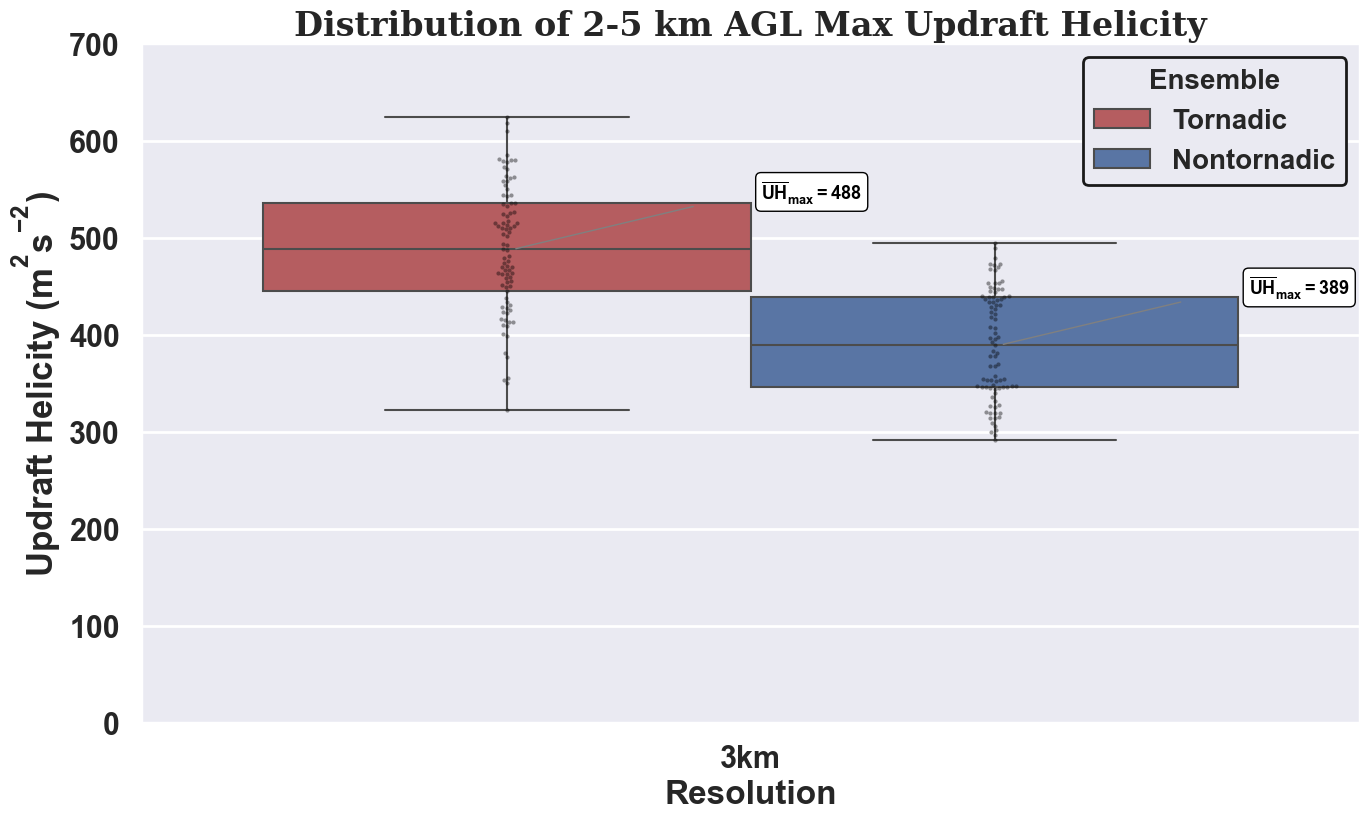

In [152]:
mid_uh_box_3km, ax_box_3km = plt.subplots(figsize=(14, 8.5))

sns.set_theme(style='darkgrid', font='sans-serif', font_scale=2)
sns.set_context('poster')
my_pal = {'Tornadic':'r', 'Nontornadic':'b'}
ax_box_3km = sns.boxplot(data=df3km_mid, x='Resolution', y='Updraft Helicity', hue='Classification', palette=my_pal, linewidth=1.5)
swarm = sns.swarmplot(data=df3km_mid, x='Resolution', y='Updraft Helicity', hue='Classification', dodge=True, alpha=0.4, size=3)

for collection in swarm.collections:
    collection.set_facecolor('black')
    collection.set_edgecolor('black')

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Ensemble', fontsize=20, title_fontsize=20, framealpha=1, edgecolor='k')

# === STEP: Annotate Mean Values ===
# Prepare group means
means = df3km_mid.groupby(['Resolution', 'Classification'])['Updraft Helicity'].mean().reset_index()

# Mapping of label to dodge offset (matches Seaborn's logic)
label_offset = {
    'Tornadic': 0.05,
    'Nontornadic': 0.45
}

# Create mapping of resolution to x-position
res_order = df3km_mid['Resolution'].unique()
x_pos_map = {res: i for i, res in enumerate(res_order)}

y_min, y_max = ax_box_3km.get_ylim()
y_range = y_max - y_min

# Adjust this multiplier as needed (5% of the range)
offset = 0.1225 * y_range


# Add mean value labels
for _, row in means.iterrows():
    x_base = x_pos_map[row['Resolution']]
    x = x_base + label_offset[row['Classification']]
    y = row['Updraft Helicity']
    label_y = y + offset
    label_x = x + 0.15
    horizontal_shift = -0.245  # or +0.05, depending on direction you want

    # Shift both label and mean x positions
    shifted_label_x = label_x + horizontal_shift
    shifted_box_x = x + horizontal_shift
    ax_box_3km.text(
        x, y + offset,  # Adjust vertical position as needed
        '$\mathregular{\overline{UH}_{max}=}$'f'{y:.0f}',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='black',
        bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor='white',
        edgecolor='black',
        linewidth=1)
    )
    ax_box_3km.annotate(
        '',
        xy=(shifted_box_x, y),
        xytext=(shifted_label_x, label_y),
        arrowprops=dict(
            arrowstyle='-',
            color='grey',
            lw=1),
        zorder=3    
        )


plt.ylim(0, 700)
plt.tight_layout()
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
ax_box_3km.set_ylabel('Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', fontsize=25)

plt.title('Distribution of 2-5 km AGL Max Updraft Helicity', fontsize=20, font='serif')
mid_uh_box_3km.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/UH_max_2_5km_boxplot_3km_only.png', dpi=300, bbox_inches='tight')
plt.show()

In [134]:
df3km_mid.loc[df3km_mid["Classification"] == "Tornadic", "Updraft Helicity"].mean()

487.8915

In [136]:
df3km_mid.loc[df3km_mid["Classification"] == "Nontornadic", "Updraft Helicity"].mean()

389.4457

In [1065]:
df_list_2 = [make_df(uh_mid_tor_max_250, '250m', 'Tornadic'), 
           make_df(uh_mid_nt_max_250, '250m', 'Nontornadic'),
           make_df(uh_mid_tor_max_500, '500m', 'Tornadic'),
           make_df(uh_mid_nt_max_500, '500m', 'Nontornadic'),
           make_df(uh_mid_tor_max_1km, '1km', 'Tornadic'),
           make_df(uh_mid_nt_max_1km, '1km', 'Nontornadic'),
           make_df(uh_mid_tor_max_2km, '2km', 'Tornadic'),
           make_df(uh_mid_nt_max_2km, '2km', 'Nontornadic')]

df_2 = pd.concat(df_list_2, ignore_index=True)

print(df_2)

     Updraft Helicity Resolution Classification
0         2352.136230       250m       Tornadic
1         4695.183594       250m       Tornadic
2         4376.251465       250m       Tornadic
3         3749.831787       250m       Tornadic
4         3925.872314       250m       Tornadic
..                ...        ...            ...
707        616.446533        2km    Nontornadic
708        625.215393        2km    Nontornadic
709        667.389771        2km    Nontornadic
710        619.174622        2km    Nontornadic
711        648.420471        2km    Nontornadic

[712 rows x 3 columns]


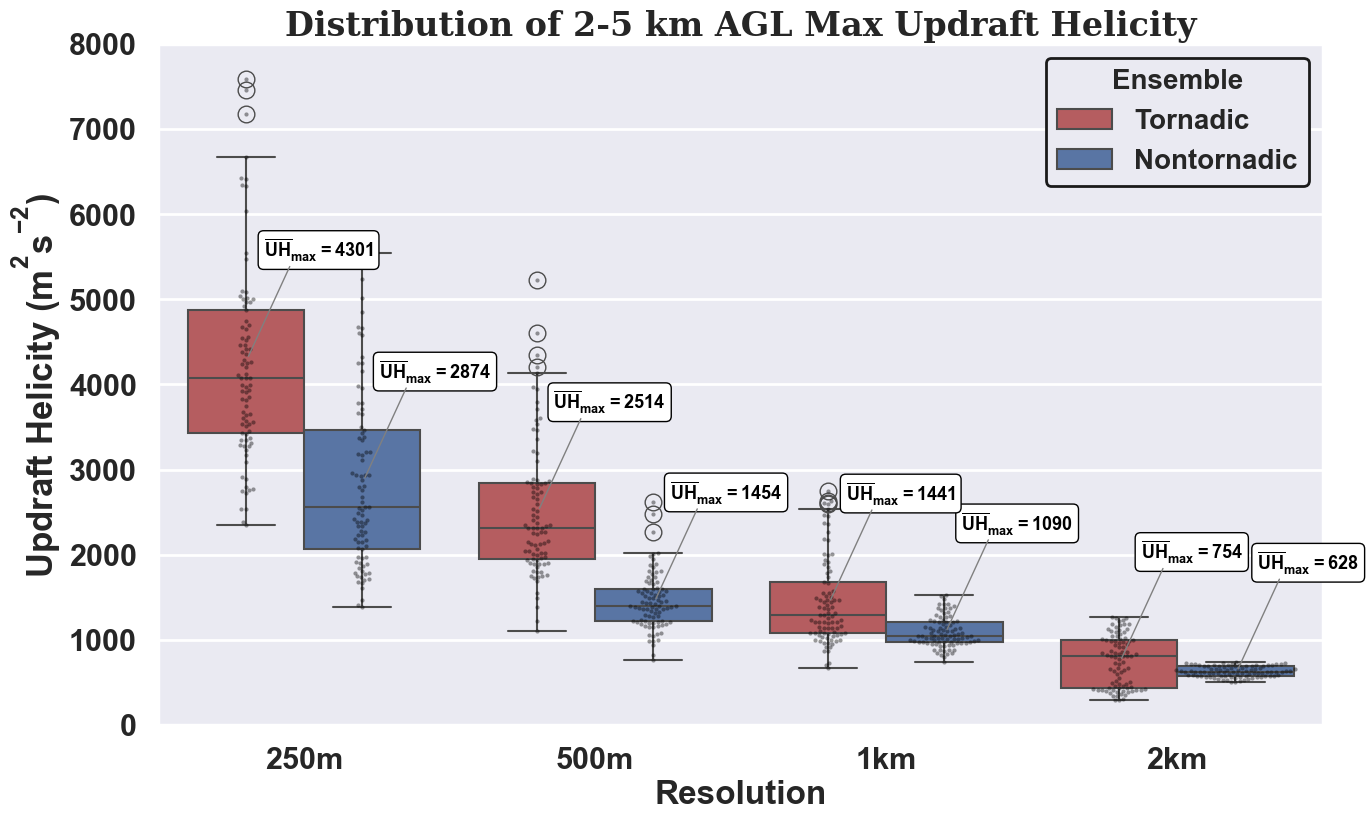

In [1107]:
mid_uh_box, ax_box_2 = plt.subplots(figsize=(14, 8.5))

sns.set_theme(style='darkgrid', font='sans-serif', font_scale=2)
sns.set_context('poster')
my_pal = {'Tornadic':'r', 'Nontornadic':'b'}
ax_box_2 = sns.boxplot(data=df_2, x='Resolution', y='Updraft Helicity', hue='Classification', palette=my_pal, linewidth=1.5)
swarm = sns.swarmplot(data=df_2, x='Resolution', y='Updraft Helicity', hue='Classification', dodge=True, alpha=0.4, size=3)

for collection in swarm.collections:
    collection.set_facecolor('black')
    collection.set_edgecolor('black')

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Ensemble', fontsize=20, title_fontsize=20, framealpha=1, edgecolor='k')

# === STEP: Annotate Mean Values ===
# Prepare group means
means = df_2.groupby(['Resolution', 'Classification'])['Updraft Helicity'].mean().reset_index()

# Mapping of label to dodge offset (matches Seaborn's logic)
label_offset = {
    'Tornadic': 0.05,
    'Nontornadic': 0.45
}

# Create mapping of resolution to x-position
res_order = df_2['Resolution'].unique()
x_pos_map = {res: i for i, res in enumerate(res_order)}

y_min, y_max = ax_box_2.get_ylim()
y_range = y_max - y_min

# Adjust this multiplier as needed (5% of the range)
offset = 0.1225 * y_range


# Add mean value labels
for _, row in means.iterrows():
    x_base = x_pos_map[row['Resolution']]
    x = x_base + label_offset[row['Classification']]
    y = row['Updraft Helicity']
    label_y = y + offset
    label_x = x + 0.15
    horizontal_shift = -0.245  # or +0.05, depending on direction you want

    # Shift both label and mean x positions
    shifted_label_x = label_x + horizontal_shift
    shifted_box_x = x + horizontal_shift
    ax_box_2.text(
        x, y + offset,  # Adjust vertical position as needed
        '$\mathregular{\overline{UH}_{max}=}$'f'{y:.0f}',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='black',
        bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor='white',
        edgecolor='black',
        linewidth=1)
    )
    ax_box_2.annotate(
        '',
        xy=(shifted_box_x, y),
        xytext=(shifted_label_x, label_y),
        arrowprops=dict(
            arrowstyle='-',
            color='grey',
            lw=1),
        zorder=3    
        )


plt.ylim(0, 8000)
plt.tight_layout()
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
ax_box_2.set_ylabel('Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', fontsize=25)

plt.title('Distribution of 2-5 km AGL Max Updraft Helicity', fontsize=20, font='serif')
mid_uh_box.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/UH_max_2_5km_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [1079]:
## plucks the domain-wide 99.995 percentile 0-2km updraft helicity from each member at each time. the resulting arrays should have a length
## ntimes * nmembers. only does one resolution at a time right now so you will need to change values and names accordingly.

resolution = 2000
data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
times = [5,6,7,8,9,10]
uh_99_tor_low_2000 = []
uh_99_nt_low_2000 = []

for time in times:
        for i in data_tor_files:
            datafile = xarray.open_dataset(i)
            w = datafile.variables['winterp'][time,:,:,:]
            zvort = datafile.variables['zvort'][time,:,:,:]
            x = datafile.variables['xh']
            y = datafile.variables['yh']
            z = datafile.variables['zh']*1000
            dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
            z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
            dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
            uh_99_tor = calc_uh(w, zvort, z_3d, dz_3d, 0, 2000)
            uh_99_tor_low_2000.append(np.percentile(uh_99_tor, 99.995))
            datafile.close()
for time in times:
        for i in data_nt_files:
            datafile = xarray.open_dataset(i)
            w = datafile.variables['winterp'][time,:,:,:]
            zvort = datafile.variables['zvort'][time,:,:,:]
            z = datafile.variables['zh']*1000
            dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
            z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
            dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
            uh_99_nt = calc_uh(w, zvort, z_3d, dz_3d, 0, 2000)
            uh_99_nt_low_2000.append(np.percentile(uh_99_nt, 99.995))
            datafile.close()

In [1081]:
uh_99_tor_low_250 = np.asarray(uh_99_tor_low_250)
uh_99_nt_low_250 = np.asarray(uh_99_nt_low_250)
uh_99_tor_low_500 = np.asarray(uh_99_tor_low_500)
uh_99_nt_low_500 = np.asarray(uh_99_nt_low_500)
uh_99_tor_low_1km = np.asarray(uh_99_tor_low_1000)
uh_99_nt_low_1km = np.asarray(uh_99_nt_low_1000)
uh_99_tor_low_2km = np.asarray(uh_99_tor_low_2000)
uh_99_nt_low_2km = np.asarray(uh_99_nt_low_2000)

uh_99_tor_low_250 = uh_99_tor_low_250[uh_99_tor_low_250 != np.percentile(uh_99_tor_low_250, 99.995)]
uh_99_nt_low_250 = uh_99_nt_low_250[uh_99_nt_low_250 != np.percentile(uh_99_nt_low_250, 99.995)]
uh_99_tor_low_500 = uh_99_tor_low_500[uh_99_tor_low_500 != np.percentile(uh_99_tor_low_500, 99.995)]
uh_99_nt_low_500 = uh_99_nt_low_500[uh_99_nt_low_500 != np.percentile(uh_99_nt_low_500, 99.995)]
uh_99_tor_low_1km = uh_99_tor_low_1km[uh_99_tor_low_1km != np.percentile(uh_99_tor_low_1km, 99.995)]
uh_99_nt_low_1km = uh_99_nt_low_1km[uh_99_nt_low_1km != np.percentile(uh_99_nt_low_1km, 99.995)]
uh_99_tor_low_2km = uh_99_tor_low_2km[uh_99_tor_low_2km != np.percentile(uh_99_tor_low_2km, 99.995)]
uh_99_nt_low_2km = uh_99_nt_low_2km[uh_99_nt_low_2km != np.percentile(uh_99_nt_low_2km, 99.995)]

print(uh_99_tor_low_250)

[ 586.3934955  1183.24099127  909.03533124  981.10231492 1020.83394961
  526.30126453 1061.92298994 2176.43049332 1101.79547121  689.93684783
  431.78258215  489.82256355  898.98237841 1069.41907838 1201.89769832
  979.88770898  956.47241832  795.75371381 1707.96157905 1038.51295054
 2130.45669572  649.63893581  600.16334399 1070.6506796   961.33414172
 1284.40901711  396.96302551  742.30125477 1083.75860545  472.02713081
 1012.93031786 1410.23218068 1778.86957316  471.89039241 1403.44332158
  608.2639038  1093.47726703 1633.65704197 1196.37193141 1231.02805541
 2694.84530144 1794.51025168  305.97855938 1750.43149285  547.80237327
 1803.75986155 1688.42861481 1209.20600355 1852.56877326 3770.85098472
 1062.45186249 1364.99671144 1975.71664825 1019.56146999 1180.86262673
 1157.55448939 1857.5906287   538.58346053 1427.03605879  906.7470012
 4541.26654671 1076.48116456  934.44543874 1461.63176974 1592.8011845
  844.83036045 1616.08414175 1852.40706014 1124.17515161 2767.26044891
 1728.51

In [1083]:
df_list_3 = [make_df(uh_99_tor_low_250, '250m', 'Tornadic'), 
           make_df(uh_99_nt_low_250, '250m', 'Nontornadic'),
           make_df(uh_99_tor_low_500, '500m', 'Tornadic'),
           make_df(uh_99_nt_low_500, '500m', 'Nontornadic'),
           make_df(uh_99_tor_low_1km, '1km', 'Tornadic'),
           make_df(uh_99_nt_low_1km, '1km', 'Nontornadic'),
           make_df(uh_99_tor_low_2km, '2km', 'Tornadic'),
           make_df(uh_99_nt_low_2km, '2km', 'Nontornadic')]

df_3 = pd.concat(df_list_3, ignore_index=True)

print(df_3)

     Updraft Helicity Resolution Classification
0          586.393496       250m       Tornadic
1         1183.240991       250m       Tornadic
2          909.035331       250m       Tornadic
3          981.102315       250m       Tornadic
4         1020.833950       250m       Tornadic
..                ...        ...            ...
715         43.606913        2km    Nontornadic
716         58.802964        2km    Nontornadic
717         49.464761        2km    Nontornadic
718         44.181933        2km    Nontornadic
719         50.468037        2km    Nontornadic

[720 rows x 3 columns]


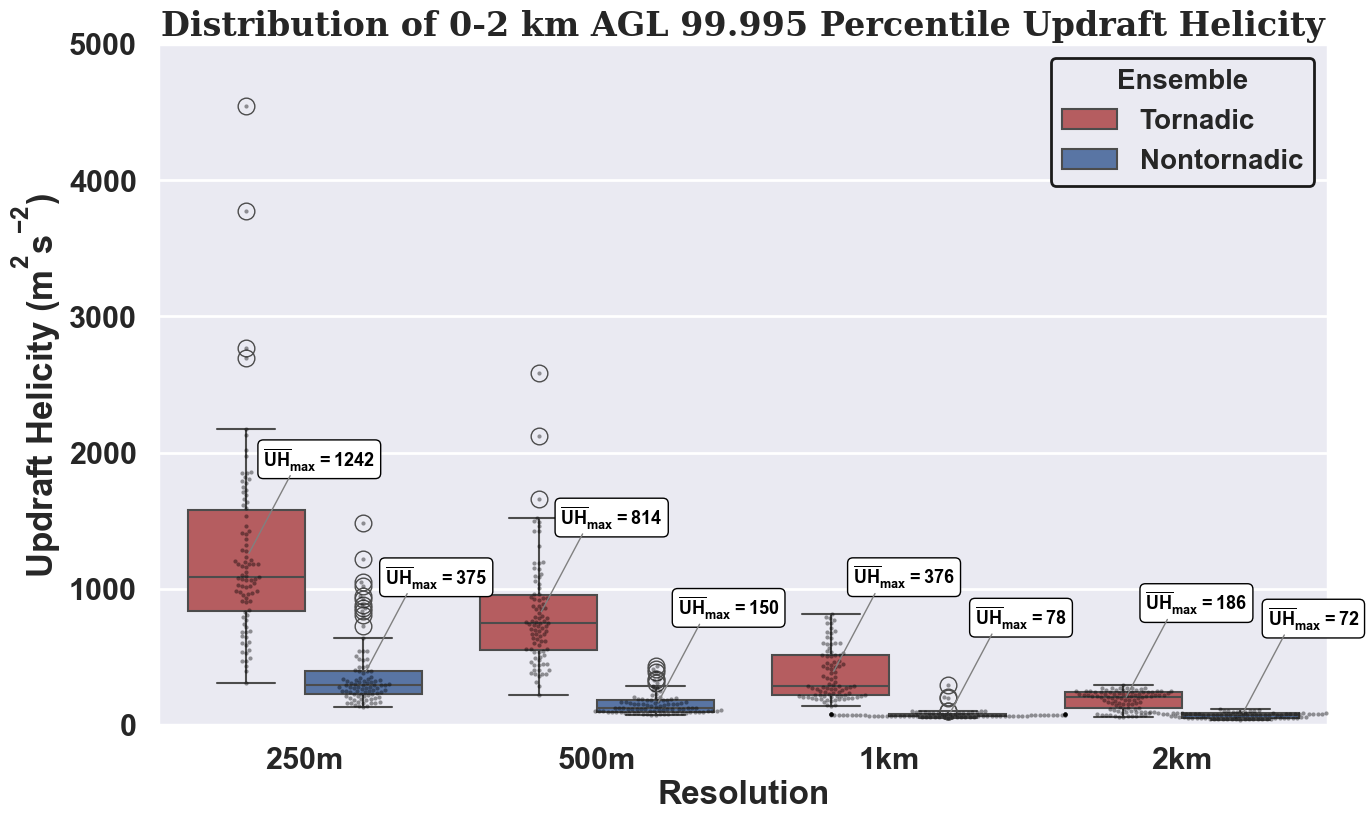

In [1109]:
low_uh99_box, ax_box_3 = plt.subplots(figsize=(14, 8.5))

sns.set_theme(style='darkgrid', font='sans-serif', font_scale=2)
sns.set_context('poster')
my_pal = {'Tornadic':'r', 'Nontornadic':'b'}
ax_box_3 = sns.boxplot(data=df_3, x='Resolution', y='Updraft Helicity', hue='Classification', palette=my_pal, linewidth=1.5)
swarm = sns.swarmplot(data=df_3, x='Resolution', y='Updraft Helicity', hue='Classification', dodge=True, alpha=0.4, size=3)

for collection in swarm.collections:
    collection.set_facecolor('black')
    collection.set_edgecolor('black')

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Ensemble', fontsize=20, title_fontsize=20, framealpha=1, edgecolor='k')

# === STEP: Annotate Mean Values ===
# Prepare group means
means = df_3.groupby(['Resolution', 'Classification'])['Updraft Helicity'].mean().reset_index()

# Mapping of label to dodge offset (matches Seaborn's logic)
label_offset = {
    'Tornadic': 0.05,
    'Nontornadic': 0.45
}

# Create mapping of resolution to x-position
res_order = df_3['Resolution'].unique()
x_pos_map = {res: i for i, res in enumerate(res_order)}

y_min, y_max = ax_box_3.get_ylim()
y_range = y_max - y_min

# Adjust this multiplier as needed (5% of the range)
offset = 0.1225 * y_range


# Add mean value labels
for _, row in means.iterrows():
    x_base = x_pos_map[row['Resolution']]
    x = x_base + label_offset[row['Classification']]
    y = row['Updraft Helicity']
    label_y = y + offset
    label_x = x + 0.15
    horizontal_shift = -0.245  # or +0.05, depending on direction you want

    # Shift both label and mean x positions
    shifted_label_x = label_x + horizontal_shift
    shifted_box_x = x + horizontal_shift
    ax_box_3.text(
        x, y + offset,  # Adjust vertical position as needed
        '$\mathregular{\overline{UH}_{max}=}$'f'{y:.0f}',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='black',
        bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor='white',
        edgecolor='black',
        linewidth=1)
    )
    ax_box_3.annotate(
        '',
        xy=(shifted_box_x, y),
        xytext=(shifted_label_x, label_y),
        arrowprops=dict(
            arrowstyle='-',
            color='grey',
            lw=1),
        zorder=3    
        )


plt.ylim(0, 5000)
plt.tight_layout()
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
ax_box_3.set_ylabel('Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', fontsize=25)

plt.title('Distribution of 0-2 km AGL 99.995 Percentile Updraft Helicity', fontsize=20, font='serif')
low_uh99_box.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/UH_99_0_2km_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
## plucks the domain-wide 99.995 percentile 2-5km updraft helicity from each member at each time. the resulting arrays should have a length
## ntimes * nmembers. only does one resolution at a time right now so you will need to change values and names accordingly.

resolution = 3000
data_tor_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_tor_ensemble_data/*[!_stats].nc'.format(resolution)))
data_nt_files = sorted(glob.glob('/Volumes/Expansion/V2_ensembles_data/{0}m_nt_ensemble_data/*[!_stats].nc'.format(resolution)))
times = [5,6,7,8,9,10]
uh_99_tor_mid_3000 = []
uh_99_nt_mid_3000 = []

for time in times:
        for i in data_tor_files:
            datafile = xarray.open_dataset(i)
            w = datafile.variables['winterp'][time,:,:,:]
            zvort = datafile.variables['zvort'][time,:,:,:]
            x = datafile.variables['xh']
            y = datafile.variables['yh']
            z = datafile.variables['zh']*1000
            dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
            z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
            dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
            uh_99_tor = calc_uh(w, zvort, z_3d, dz_3d, 2000, 5000)
            uh_99_tor_mid_3000.append(np.percentile(uh_99_tor, 99.9))
            datafile.close()
for time in times:
        for i in data_nt_files:
            datafile = xarray.open_dataset(i)
            w = datafile.variables['winterp'][time,:,:,:]
            zvort = datafile.variables['zvort'][time,:,:,:]
            z = datafile.variables['zh']*1000
            dz = np.pad(np.diff(datafile.variables['zh'])*1000, (1,0), 'constant')
            z_3d, y_3d, x_3d = np.meshgrid(z, y, x, indexing='ij')
            dz_3d, y_3d, x_3d = np.meshgrid(dz, y, x, indexing='ij')
            uh_99_nt = calc_uh(w, zvort, z_3d, dz_3d, 2000, 5000)
            uh_99_nt_mid_3000.append(np.percentile(uh_99_nt, 99.9))
            datafile.close()

In [1099]:
uh_99_tor_mid_250 = np.asarray(uh_99_tor_mid_250)
uh_99_nt_mid_250 = np.asarray(uh_99_nt_mid_250)
uh_99_tor_mid_500 = np.asarray(uh_99_tor_mid_500)
uh_99_nt_mid_500 = np.asarray(uh_99_nt_mid_500)
uh_99_tor_mid_1km = np.asarray(uh_99_tor_mid_1000)
uh_99_nt_mid_1km = np.asarray(uh_99_nt_mid_1000)
uh_99_tor_mid_2km = np.asarray(uh_99_tor_mid_2000)
uh_99_nt_mid_2km = np.asarray(uh_99_nt_mid_2000)

uh_99_tor_mid_250 = uh_99_tor_mid_250[uh_99_tor_mid_250 != np.percentile(uh_99_tor_mid_250, 99.995)]
uh_99_nt_mid_250 = uh_99_nt_mid_250[uh_99_nt_mid_250 != np.percentile(uh_99_nt_mid_250, 99.995)]
uh_99_tor_mid_500 = uh_99_tor_mid_500[uh_99_tor_mid_500 != np.percentile(uh_99_tor_mid_500, 99.995)]
uh_99_nt_mid_500 = uh_99_nt_mid_500[uh_99_nt_mid_500 != np.percentile(uh_99_nt_mid_500, 99.995)]
uh_99_tor_mid_1km = uh_99_tor_mid_1km[uh_99_tor_mid_1km != np.percentile(uh_99_tor_mid_1km, 99.995)]
uh_99_nt_mid_1km = uh_99_nt_mid_1km[uh_99_nt_mid_1km != np.percentile(uh_99_nt_mid_1km, 99.995)]
uh_99_tor_mid_2km = uh_99_tor_mid_2km[uh_99_tor_mid_2km != np.percentile(uh_99_tor_mid_2km, 99.995)]
uh_99_nt_mid_2km = uh_99_nt_mid_2km[uh_99_nt_mid_2km != np.percentile(uh_99_nt_mid_2km, 99.995)]

print(uh_99_tor_mid_250)

[2183.62307111 3426.50555056 3247.71386471 2688.83617568 2812.60151201
 2188.38928884 2806.01480875 3234.14488787 2655.1278629  2597.35699697
 1980.38811431 2541.82228948 2579.92201589 2661.60004113 3695.48285532
 2984.78983982 4080.96981333 3144.98617432 2470.89922029 3059.9808321
 5057.64787053 2970.64545792 3033.17409047 4353.25587024 4188.67271213
 3254.24596463 2215.91722808 2757.87432877 2153.54040039 3178.55575746
 3079.79038993 3451.74732505 5919.77072978 3168.98124608 3701.66271728
 2895.20531356 3505.15170251 2969.88298285 2888.25599258 2453.59018217
 3449.62416412 2516.29300061 2294.41509965 3875.0759671  2496.03741924
 6336.86377874 2561.05588723 2568.20095802 3349.35103218 3551.86280292
 3367.66542062 2367.1141287  2268.81015831 1899.33256021 3475.31252656
 2202.65689879 2784.1299111  2269.20047488 3319.3131911  3061.99330391
 3374.59319219 3483.93646869 2761.10102887 5976.01274924 3997.8030037
 3392.51579471 2964.32185216 3312.00668369 3263.12510303 3721.07238773
 2741.51

In [27]:
uh_99_tor_mid_3km = np.asarray(uh_99_tor_mid_3000)
uh_99_nt_mid_3km = np.asarray(uh_99_nt_mid_3000)

uh_99_tor_mid_3km = uh_99_tor_mid_3km[uh_99_tor_mid_3km != np.percentile(uh_99_tor_mid_3km, 99.9)]
uh_99_nt_mid_3km = uh_99_nt_mid_3km[uh_99_nt_mid_3km != np.percentile(uh_99_nt_mid_3km, 99.9)]

In [29]:
df_list_3km = [make_df(uh_99_tor_mid_3km, '3km', 'Tornadic'),
           make_df(uh_99_nt_mid_3km, '3km', 'Nontornadic')]

df_3km = pd.concat(df_list_3km, ignore_index=True)

In [1101]:
df_list_4 = [make_df(uh_99_tor_mid_250, '250m', 'Tornadic'), 
           make_df(uh_99_nt_mid_250, '250m', 'Nontornadic'),
           make_df(uh_99_tor_mid_500, '500m', 'Tornadic'),
           make_df(uh_99_nt_mid_500, '500m', 'Nontornadic'),
           make_df(uh_99_tor_mid_1km, '1km', 'Tornadic'),
           make_df(uh_99_nt_mid_1km, '1km', 'Nontornadic'),
           make_df(uh_99_tor_mid_2km, '2km', 'Tornadic'),
           make_df(uh_99_nt_mid_2km, '2km', 'Nontornadic')]

df_4 = pd.concat(df_list_4, ignore_index=True)

print(df_4)

     Updraft Helicity Resolution Classification
0         2183.623071       250m       Tornadic
1         3426.505551       250m       Tornadic
2         3247.713865       250m       Tornadic
3         2688.836176       250m       Tornadic
4         2812.601512       250m       Tornadic
..                ...        ...            ...
715        590.380581        2km    Nontornadic
716        575.936909        2km    Nontornadic
717        620.788806        2km    Nontornadic
718        607.091323        2km    Nontornadic
719        624.967329        2km    Nontornadic

[720 rows x 3 columns]


<>:51: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:51: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\m'
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_13454/2865284347.py:51: SyntaxWarning: invalid escape sequence '\m'
  '$\mathregular{\overline{UH}_{max}=}$'f'{y:.0f}',
/var/folders/q4/1k37k9711nlcfllp3lr1cc8r0000gn/T/ipykernel_13454/2865284347.py:80: SyntaxWarning: invalid escape sequence '\m'
  ax_box_3km.set_ylabel('Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', fontsize=25)


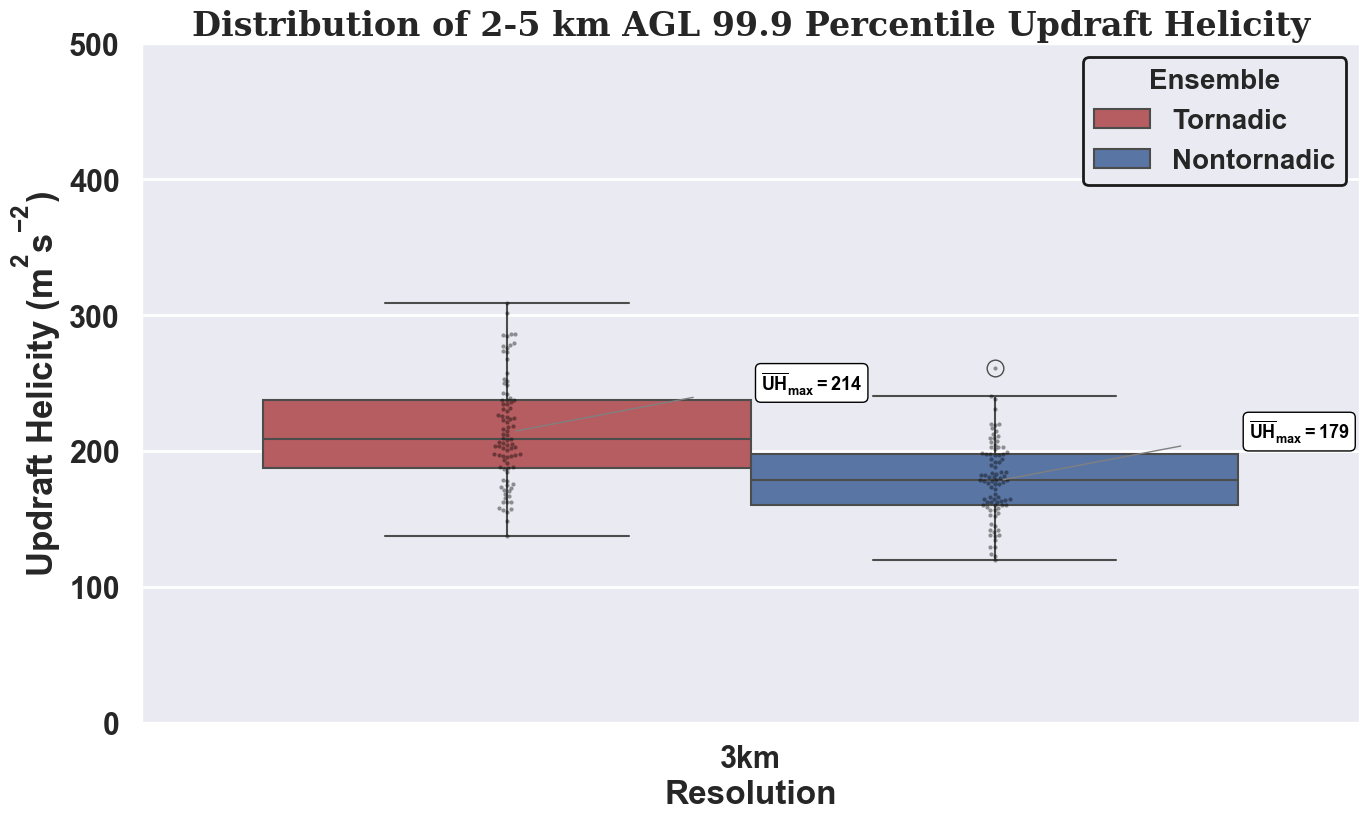

In [33]:
mid_uh99_3km, ax_box_3km = plt.subplots(figsize=(14, 8.5))

sns.set_theme(style='darkgrid', font='sans-serif', font_scale=2)
sns.set_context('poster')
my_pal = {'Tornadic':'r', 'Nontornadic':'b'}
ax_box_3km = sns.boxplot(data=df_3km, x='Resolution', y='Updraft Helicity', hue='Classification', palette=my_pal, linewidth=1.5)
swarm = sns.swarmplot(data=df_3km, x='Resolution', y='Updraft Helicity', hue='Classification', dodge=True, alpha=0.4, size=3)

for collection in swarm.collections:
    collection.set_facecolor('black')
    collection.set_edgecolor('black')

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Ensemble', fontsize=20, title_fontsize=20, framealpha=1, edgecolor='k')

# === STEP: Annotate Mean Values ===
# Prepare group means
means = df_3km.groupby(['Resolution', 'Classification'])['Updraft Helicity'].mean().reset_index()

# Mapping of label to dodge offset (matches Seaborn's logic)
label_offset = {
    'Tornadic': 0.05,
    'Nontornadic': 0.45
}

# Create mapping of resolution to x-position
res_order = df_3km['Resolution'].unique()
x_pos_map = {res: i for i, res in enumerate(res_order)}

y_min, y_max = ax_box_3km.get_ylim()
y_range = y_max - y_min

# Adjust this multiplier as needed (5% of the range)
offset = 0.1225 * y_range


# Add mean value labels
for _, row in means.iterrows():
    x_base = x_pos_map[row['Resolution']]
    x = x_base + label_offset[row['Classification']]
    y = row['Updraft Helicity']
    label_y = y + offset
    label_x = x + 0.15
    horizontal_shift = -0.245  # or +0.05, depending on direction you want

    # Shift both label and mean x positions
    shifted_label_x = label_x + horizontal_shift
    shifted_box_x = x + horizontal_shift
    ax_box_3km.text(
        x, y + offset,  # Adjust vertical position as needed
        '$\mathregular{\overline{UH}_{max}=}$'f'{y:.0f}',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='black',
        bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor='white',
        edgecolor='black',
        linewidth=1)
    )
    ax_box_3km.annotate(
        '',
        xy=(shifted_box_x, y),
        xytext=(shifted_label_x, label_y),
        arrowprops=dict(
            arrowstyle='-',
            color='grey',
            lw=1),
        zorder=3    
        )


plt.ylim(0, 500)
plt.tight_layout()
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
ax_box_3km.set_ylabel('Updraft Helicity ($\mathregular{m{^{2}}s{^{-2}}}$)', fontsize=25)

plt.title('Distribution of 2-5 km AGL 99.9 Percentile Updraft Helicity', fontsize=20, font='serif')
#mid_uh99_box.savefig('/Users/austindixon/Desktop/PhD Research/V2_ensemble_analyses/UH_99_2_5km_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

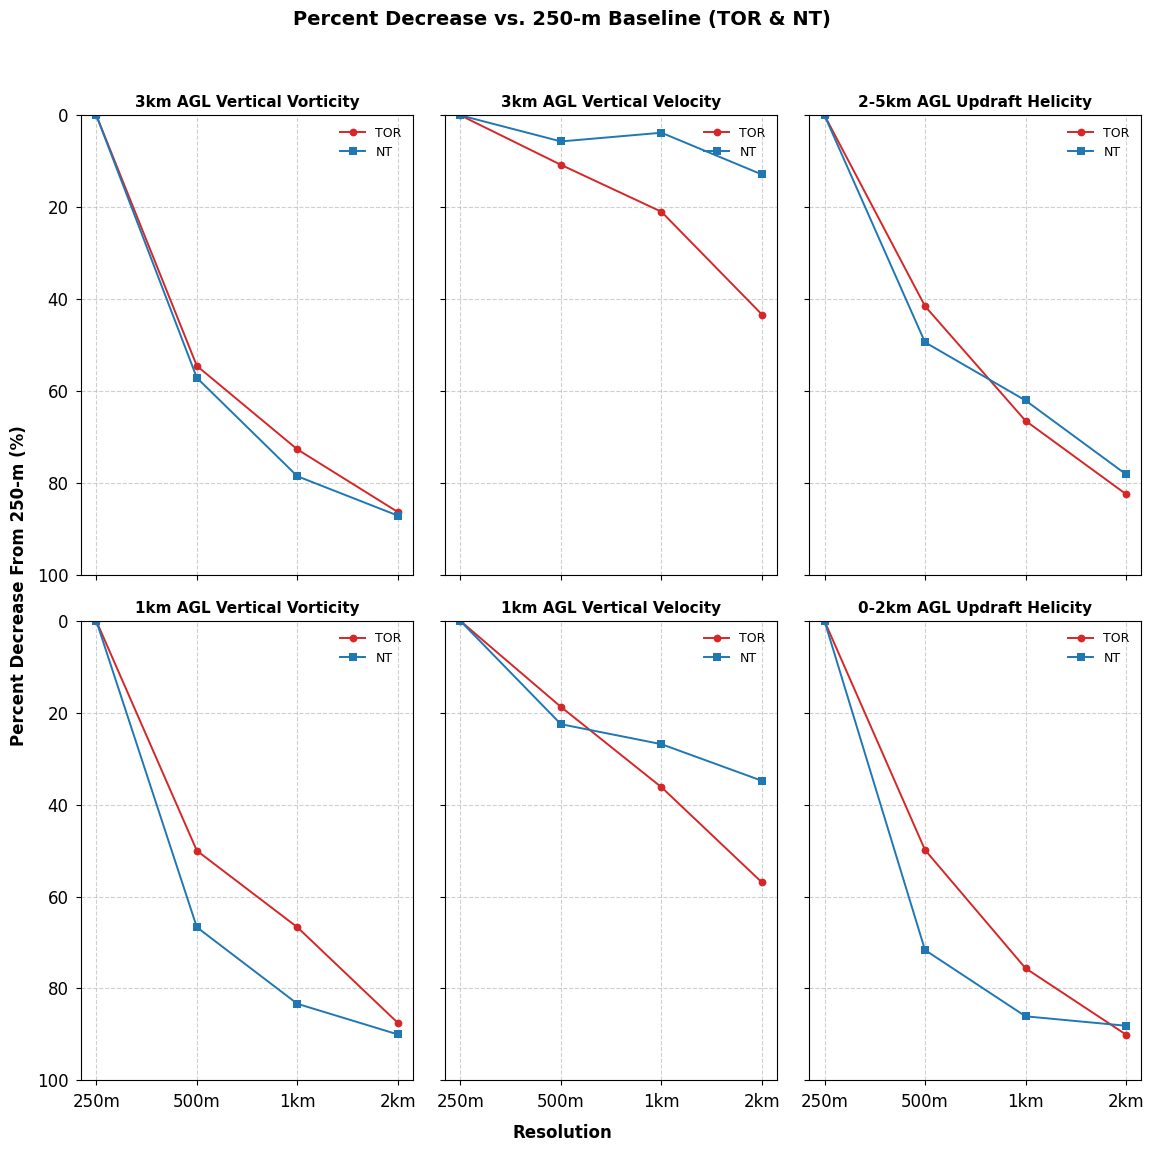

[([0.0, 54.54545454545454, 72.72727272727273, 86.36363636363636], [0.0, 57.14285714285715, 78.57142857142857, 87.14285714285714], '3km AGL Vertical Vorticity'), ([0.0, 10.773480662983442, 20.994475138121548, 43.37016574585636], [0.0, 5.6818181818181825, 3.787878787878788, 12.878787878787874], '3km AGL Vertical Velocity'), ([0.0, 41.548477098349224, 66.49616368286445, 82.46919321088119], [0.0, 49.40848990953375, 62.07376478775226, 78.14892136395268], '2-5km AGL Updraft Helicity'), ([0.0, 50.0, 66.66666666666666, 87.5], [0.0, 66.66666666666666, 83.33333333333333, 90.0], '1km AGL Vertical Vorticity'), ([0.0, 18.699186991869922, 36.178861788617894, 56.91056910569105], [0.0, 22.463768115942038, 26.811594202898558, 34.78260869565218], '1km AGL Vertical Velocity'), ([0.0, 49.83637213651239, 75.5960729312763, 90.04207573632539], [0.0, 71.6323296354992, 86.05388272583201, 88.11410459587957], '0-2km AGL Updraft Helicity')]


In [170]:
resolutions = ["250m", "500m", "1km", "2km"]

tor_set1 = [0.11, 0.05, 0.03, 0.015]
nt_set1 = [0.07, 0.03, 0.015, 0.009]

tor_set2 = [36.2, 32.3, 28.6, 20.5]
nt_set2 = [26.4, 24.9, 25.4, 23.0]

tor_set3 = [0.12, 0.06, 0.04, 0.015]     # placeholder
nt_set3 = [0.06, 0.02, 0.01, 0.006]     # placeholder

tor_set4 = [24.6, 20.0, 15.7, 10.6]  # placeholder
nt_set4 = [13.8, 10.7, 10.1, 9.0]   # placeholder

tor_set5 = [4301, 2514, 1441, 754]     # NEW dataset placeholder
nt_set5 = [2874, 1454, 1090, 628]   # NEW dataset placeholder

tor_set6 = [2139, 1073, 522, 213]  # NEW dataset placeholder
nt_set6 = [631, 179, 88, 75]   # NEW dataset placeholder


datasets = [
    (tor_set1, nt_set1, "3km AGL Vertical Vorticity"),
    (tor_set2, nt_set2, "3km AGL Vertical Velocity"),
    (tor_set5, nt_set5, "2-5km AGL Updraft Helicity"),
    (tor_set3, nt_set3, "1km AGL Vertical Vorticity"),
    (tor_set4, nt_set4, "1km AGL Vertical Velocity"),
    (tor_set6, nt_set6, "0-2km AGL Updraft Helicity"),
]

# function to compute percent decrease relative to highest resolution
def percent_decrease(values):
    base = values[0]
    return [(base-v) / base * 100 for v in values]

# compute decreases
datasets_decrease = []
for tor_vals, nt_vals, title in datasets:
    tor_dec = percent_decrease(tor_vals)
    nt_dec = percent_decrease(nt_vals)
    datasets_decrease.append((tor_dec, nt_dec, title))

plt.style.use("seaborn-v0_8-paper")

fig, axes = plt.subplots(2, 3, figsize=(12, 12), sharex=True, sharey=True)

for ax, (tor_dec, nt_dec, title) in zip(axes.flat, datasets_decrease):
    ax.plot(resolutions, tor_dec, marker="o", color="tab:red", label="TOR")
    ax.plot(resolutions, nt_dec, marker="s", color="tab:blue", label="NT")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim(100, 0)
    ax.legend(frameon=False, loc="upper right", fontsize=9)
    ax.tick_params(axis="both", labelsize=12)
fig.text(0.5, 0.04, "Resolution", ha="center", fontsize=12, fontweight='bold')
fig.text(0.04, 0.5, "Percent Decrease From 250-m (%)", va="center", rotation="vertical", fontsize=12, fontweight='bold')
plt.suptitle("Percent Decrease vs. 250-m Baseline (TOR & NT)", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

print(datasets_decrease)

# Tornadic Control Run Plots

TypeError: object of type 'LinearSegmentedColormap' has no len()

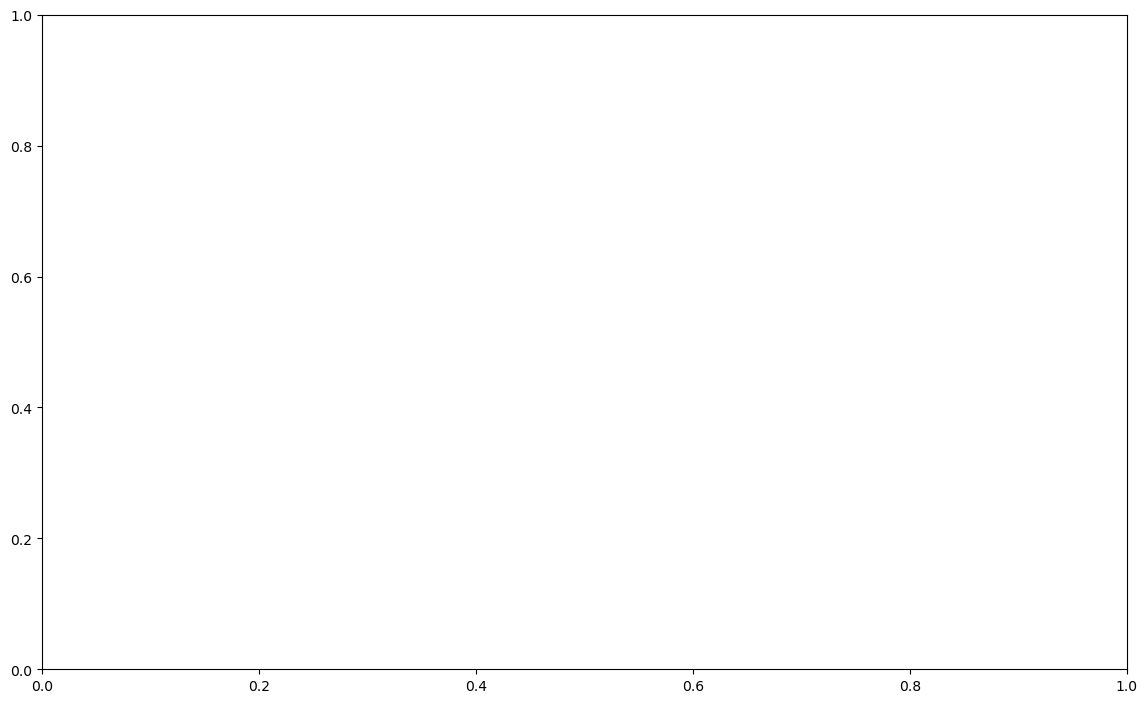

In [23]:
import matplotlib.patheffects as pe
resolution = 2000
slice=1
times = [5,6,7,8,9,10]
#heights = [0,12,20,31]  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
#heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}

cmap = cb_colors.nws_dz_cmap
w_cmap = cb_colors.all_reds_cmap


for time in times:
    ref = []
    w_3d = []
    u = []
    v = []
    w = []

        
    datafile = xarray.open_dataset('D:V2_ensembles_data/{0}m_tor_ensemble_data/2km_tor_ctl.nc'.format(resolution))
    #print(i)
    ref = datafile.variables['dbz'][time,20,:,:]
    w_3d = datafile.variables['winterp'][time,20,:,:]
    u = datafile.variables['uinterp'][time,0,:,:]
    v = datafile.variables['vinterp'][time,0,:,:]
    x = datafile.variables['xh']
    y = datafile.variables['yh']
    z = datafile.variables['zh']
    
    datafile.close()
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    cmap.set_bad(color='w')
    #w_plot=ax.contourf(x,y,w_3d, levels=np.arange(0, 50, 5), cmap=w_cmap)
    vort_plot=ax.contour(x, y, ref, colors=ref_new_cmap)
    #windplot=ax.quiver(x[::slice],y[::slice],u[::slice, ::slice],v[::slice, ::slice], color='black', scale=750)
    ax.set_xlim(-5,45) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_title('Reflectivity, 1km AGL W, & Sfc Winds', fontdict=font, pad=20)
    ax.set_xlabel('X (km)', fontdict=font)
    ax.set_ylabel('Y (km)', fontdict=font)
    ax.text(0.34, 0.95,'['+str(resolution)+'m Control Run]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold', path_effects=[pe.withStroke(linewidth=5, foreground='white')])
    ax.text(0.90, 0.94,'TOR', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold', path_effects=[pe.withStroke(linewidth=5, foreground='white')])
    ax.text(0.78, 0.03,'Model Time Elapsed = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=15, fontweight='bold', path_effects=[pe.withStroke(linewidth=5, foreground='white')])
    #cbar = plt.colorbar(w_plot, ticks=np.arange(0, 50, 5), format='%.2f')
    vort_plot.set_clim(0, 55)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
    #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
    #cbar.set_label(label='Vertical Velocity (m/s)', size=15, weight='bold')
    #spacefig.savefig('/Users/A W Dixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_control_analyses/tornadic/['+str(resolution)+'m_TOR_control]_ref_t'+str(time*15)+'.png', dpi=300, bbox_inches='tight')
    #plt.close()

# Nontornadic Control Run Plots

In [303]:
resolution = 250
slice=10
times = [5,6,7,8,9,10]
#heights = [0,12,20,31]  ## 0==20m, 12==500m, 20==1km, 27==2km, 31==3km
#heightlabels = {0: "LML", 12: "500m", 20: "1km", 31: "3km"}

cmap = cb_colors.nws_dz_cmap
w_cmap = cb_colors.all_reds_cmap

for time in times:
    ref = []
    w_3d = []
    u = []
    v = []
    w = []

        
    datafile = xarray.open_dataset('D:V2_ensembles_data/{0}m_nt_ensemble_data/250m_nt_ctl.nc'.format(resolution))
    #print(i)
    ref = datafile.variables['dbz'][time,20,:,:]
    w_3d = datafile.variables['winterp'][time,20,:,:]
    u = datafile.variables['uinterp'][time,0,:,:]
    v = datafile.variables['vinterp'][time,0,:,:]
    x = datafile.variables['xh']
    y = datafile.variables['yh']
    z = datafile.variables['zh']
    
    datafile.close()
    norm = mcolors.TwoSlopeNorm(vcenter=0)
    spacefig, ax = plt.subplots(figsize=(14,8.5))
    cmap.set_bad(color='w')
    w_plot=ax.contourf(x,y,w_3d, levels=np.arange(0, 50, 5), cmap=w_cmap)
    vort_plot=ax.contour(x, y, ref, levels=[40], colors='k', linewidths=3)
    windplot=ax.quiver(x[::slice],y[::slice],u[::slice, ::slice],v[::slice, ::slice], color='black', scale=750)
    ax.set_xlim(-15,35) ##tornadic
    ax.set_ylim(-5, 40) ##tornadic
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_title('Reflectivity, 1km AGL W, & Sfc Winds', fontdict=font, pad=20)
    ax.set_xlabel('X (km)', fontdict=font)
    ax.set_ylabel('Y (km)', fontdict=font)
    ax.text(0.34, 0.95,'['+str(resolution)+'m Control Run]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold', path_effects=[pe.withStroke(linewidth=5, foreground='white')])
    ax.text(0.90, 0.94,'NT', ha='center', va='center', transform=ax.transAxes, fontsize=50, fontweight='bold', path_effects=[pe.withStroke(linewidth=5, foreground='white')])
    ax.text(0.78, 0.03,'Model Time Elapsed = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=15, fontweight='bold', path_effects=[pe.withStroke(linewidth=5, foreground='white')])
    cbar = plt.colorbar(w_plot, ticks=np.arange(0, 50, 5), format='%.2f')
    vort_plot.set_clim(0, 55)#, ticks=np.arange(0.0, 0.175, 0.0125), format='%.2f')
    #cbar = plt.colorbar(vort_plot, ticks=np.arange(0.01, 0.4, 0.05), format='%.2f')
    cbar.set_label(label='Vertical Velocity (m/s)', size=15, weight='bold')
    spacefig.savefig('/Users/A W Dixon/Desktop/PhD Research/V2_ensemble_analyses/'+str(resolution)+'m_control_analyses/nontornadic/['+str(resolution)+'m_NT_control]_ref_t'+str(time*15)+'.png', dpi=300, bbox_inches='tight')
    plt.close()

## Vertical Velocity/dBZ

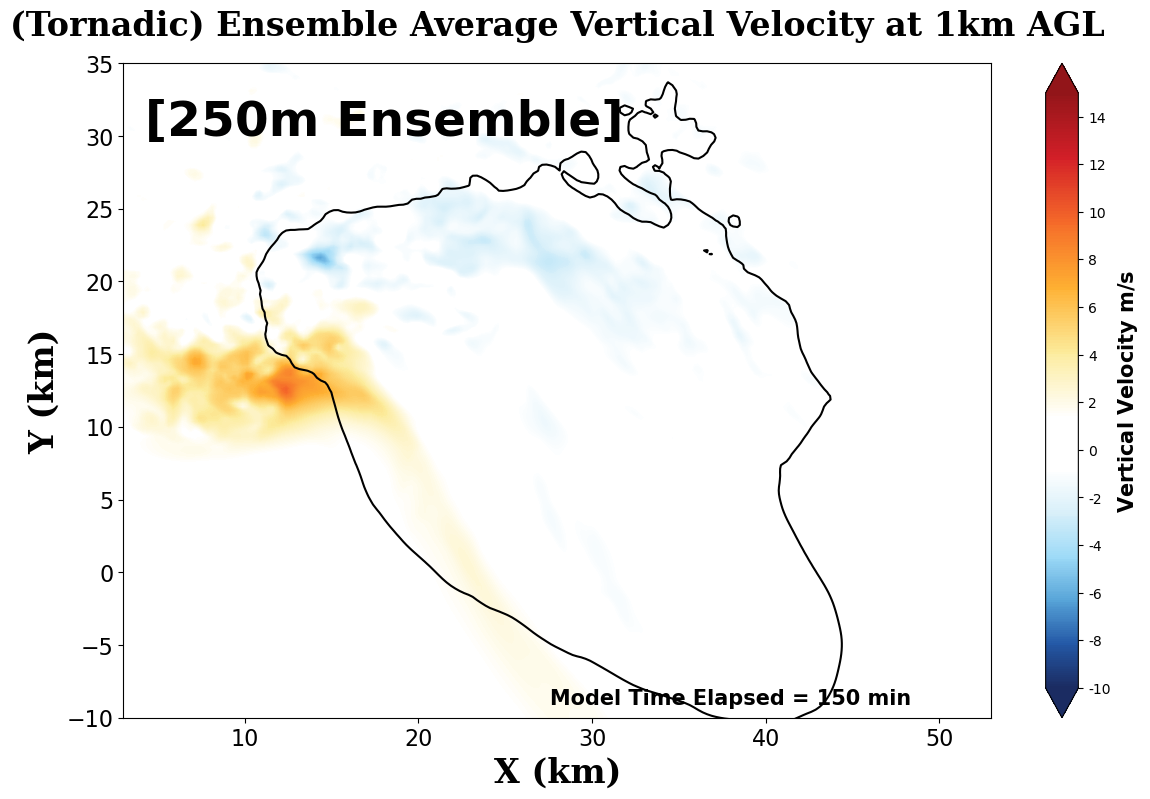

In [399]:
#w3d_avg[w3d_avg<1] = np.nan
#vortsfc_levels = np.arange(0, 1750, 250)
norm = mcolors.TwoSlopeNorm(vcenter=0)
spacefig, ax = plt.subplots(figsize=(14,8.5))
#w_levels = np.linspace(-10, 15, 1000, endpoint=True)
cmap=cmaps.BlueWhiteOrangeRed
#cmap.set_bad(color='w')
#w_plot=ax.contourf(x, y, w3d_avg, levels=np.arange(-10, 15, 0.01), cmap=cmap, norm=norm, extend='both')
refplot=ax.contourf(x, y, ref[, colors=ref_new_cmap)
ax.set_xlim(3,53)
ax.set_ylim(-10, 35)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_title('(Tornadic) Ensemble Average Vertical Velocity at 1km AGL', fontdict=font, pad=20)
ax.set_xlabel('X (km)', fontdict=font)
ax.set_ylabel('Y (km)', fontdict=font)
ax.text(0.3, 0.91,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
ax.text(0.7, 0.03,'Model Time Elapsed = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=15, fontweight='bold')
#vort_plot.set_clim(-10, 30)
#cbar = plt.colorbar(w_plot, ticks=np.arange(-10, 16, 2), format='%.0f')
cbar.set_label(label='Vertical Velocity $\mathregular{m/s}$', size=15, weight='bold')
spacefig.savefig('/Users/A W Dixon/Desktop/PhD Research/V2_ensemble_analyses/[{0}m_TOR_ens]_w1km_t{1}_avg.png'.format(resolution, time*15), dpi=300, bbox_inches='tight')

# Potential Temp Pert, Winds, dBZ

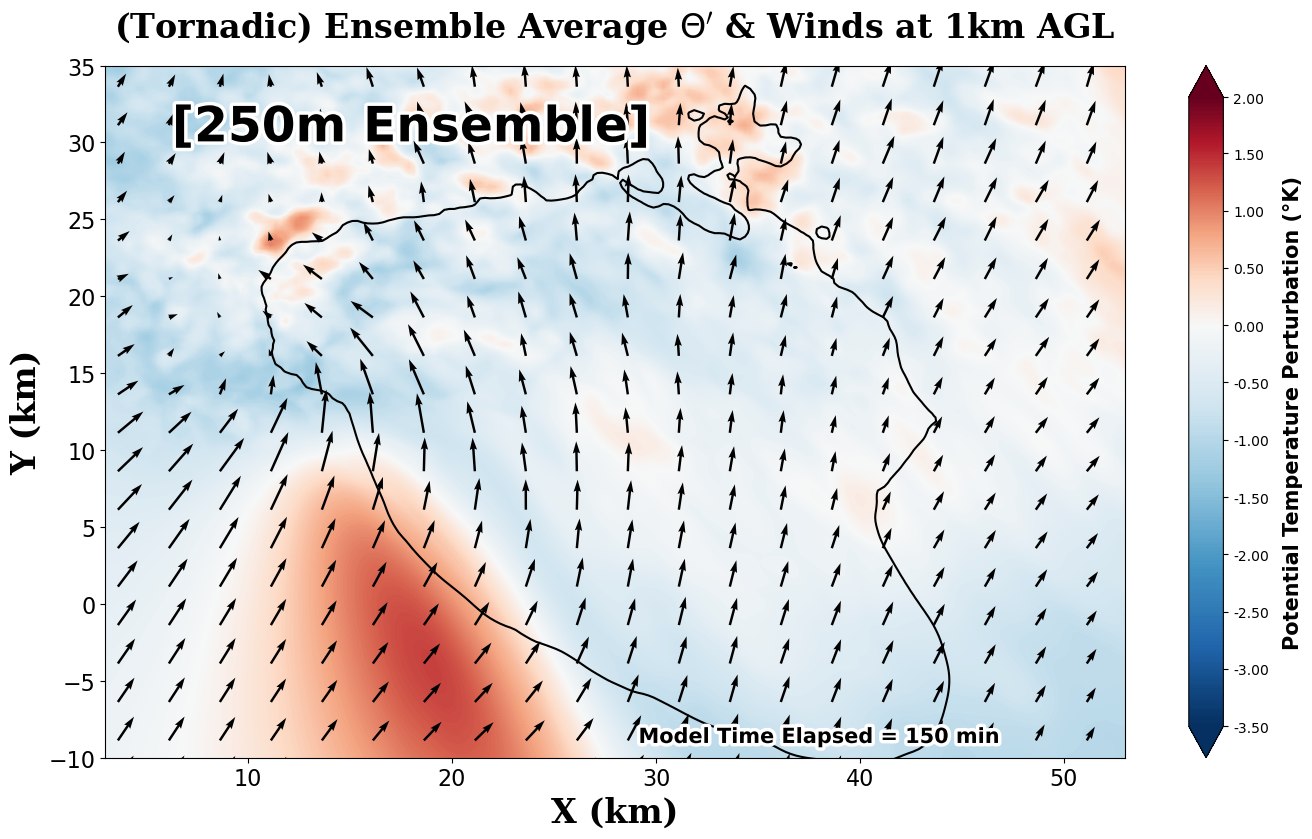

In [400]:
slice = 10
norm = mcolors.TwoSlopeNorm(vcenter=0)
thetafig, ax = plt.subplots(figsize=(14,8.5))
#w_levels = np.linspace(-10, 15, 1000, endpoint=True)
cmap=plt.get_cmap('RdBu_r')
#cmap.set_bad(color='w')
theta_plot=ax.contourf(x, y, thpert_avg, norm=norm, cmap=cmap, levels=np.arange(-3.5, 2.0, 0.01), extend='both')
windplot=ax.quiver(x[::slice],y[::slice],u_avg[::slice, ::slice],v_avg[::slice, ::slice], color='black', scale=500)
refplot=ax.contour(x, y, ref_avg, levels=[35], colors='k')
ax.set_xlim(3,53)
ax.set_ylim(-10, 35)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_title('(Tornadic) Ensemble Average' + ' $\Theta^{\prime}$ & Winds ' + 'at 1km AGL', fontdict=font, pad=20)
ax.set_xlabel('X (km)', fontdict=font)
ax.set_ylabel('Y (km)', fontdict=font)
ensemble_label = ax.text(0.3, 0.91,'['+str(resolution)+'m Ensemble]', ha='center', va='center', transform=ax.transAxes, fontsize=35, fontweight='bold')
model_time_label = ax.text(0.7, 0.03,'Model Time Elapsed = '+str(time*15)+' min', ha='center', va='center', transform=ax.transAxes, fontsize=15, fontweight='bold')
#theta_plot.set_clim(-2.0, 1.0)
ensemble_label.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='w')])
model_time_label.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='w')])
#cbar = plt.colorbar(theta_plot, format='%.2f', ticks=[-1.4,-1.2,-1.0,-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8,1.0,1.2,1.4]) ##1km
cbar = plt.colorbar(theta_plot, format='%.2f', ticks=np.arange(-3.5, 2.5, 0.5))
cbar.set_label(label='Potential Temperature Perturbation (°K)', size=15, weight='bold', labelpad=10)
thetafig.tight_layout()
thetafig.savefig('/Users/A W Dixon/Desktop/PhD Research/V2_ensemble_analyses/[{0}m_TOR_ens]_theta1km_t{1}_avg.png'.format(resolution, time*15), dpi=300, bbox_inches='tight')